# Supplementary Fig. 22 — calling chromosomal rearrangements in simulated samples

Testing the TETRIS-seq chromosomal-rearrangement caller on **in-silico simulated samples**, and how the
inferred vs actual VAF concordance improves as the soft-clip remapping steps are added. Each **column** is
one of the four rearrangement categories (one example fusion each); each **row** is a caller configuration:

| row | caller configuration |
|---|---|
| **a** | no soft-clip remapping |
| **b** | only *discordant*-read soft-clip remapping |
| **c** | *discordant + concordant* soft-clip remapping |

| column | example fusion | category | notebook cells (build → plot) |
|---|---|---|---|
| 1 | **t(9;22) BCR::ABL1**   | non-homologous, no inversion    | build → *plot (embedded)* |
| 2 | **t(3;3) DEK::NUP214**  | homologous, no inversion        | build → *plot (embedded)* |
| 3 | **t(9;11) KMT2A::MLLT3**| non-homologous, with inversion  | build → *plot (embedded)* |
| 4 | **t(16;16) CBFB::MYH11**| homologous, with inversion      | build → *plot (embedded)* |

Within each panel: each actual VAF on the x-axis is one simulated sample (n = 8, actual VAFs 5–40%); the two
colours are the two reciprocal breakpoints (e.g. BCR::ABL1 and ABL1::BCR); the dotted line is inferred = actual.
Samples where one breakpoint partner is not covered by the custom panel are marked `*`. The notebook draws each
fusion's three configurations side-by-side; the manuscript stacks them vertically into the four columns
(an Illustrator arrangement).

## Data availability

| file / tool | used for | location |
|---|---|---|
| `Simulated_samples/<fusion>/<sample>/*.bam` (+ `.bai`) | the 32 simulated samples the caller is run over | Data_files |
| `TWIST_CNV_panel_TE-95031423_h19.bed` | panel design, to flag breakpoints not covered by the panel | Data_files |
| `Homo_sapiens_assembly19.fasta` | hg19 reference for soft-clip remapping | third party (2.9 GB); set `reference_genome` to your own copy |
| `fgbio-1.3.0.jar` | `ClipBam`, hard-clips overlapping reads | third party; expected in the notebook's working directory |
| ANNOVAR with the hg19 `humandb/` | annotates the called breakpoint locations | third party (registration required); expected as `annovar/` in the working directory |


## 1. Imports and colours

In [ ]:
# imported packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import time
from datetime import date
import csv
from Bio.Seq import Seq
from fuzzywuzzy import fuzz
import pysam
try:
except ImportError:
from pyfaidx import Fasta

import os
import shlex
import subprocess

today = date.today()
date_today = today.strftime("%d/%m/%Y")

In [ ]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [ ]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

## 2. The rearrangement caller (helper functions)

In [ ]:
read_length = 146

In [ ]:
def output_file_header(out_directory, sample_name, date_today, output_file, minimum_mapq, version):
    output_file.write('sample name :\t'+ str(sample_name)+ '\n')
    output_file.write('date of analysis :\t'+ str(date_today)+ '\n')
    output_file.write('produced from code:\t' + 'Watson_code_translocation_caller: version '+str(version) + '\n')
    output_file.write('minimum mapping quality set to:\t' + str(minimum_mapq) + '\n\n')
    output_file.write('CSV HEADER DESCRIPTIONS: \n')
    output_file.write('For each translocation found, the types of reads that were used to infer the breakpoints are shown:\n')
    output_file.write('- NONHOM = nonhomologous chromosomes involved')
    output_file.write('- HOM = homologous chromosomes involved')
    output_file.write('- INVLEFT = translocation which involves the segment on the left being inverted')
    output_file.write('- INVRIGHT = translocation which involves the segment on the right being inverted')
    output_file.write('- Discordant reads = pair of reads where one read has its predominant mapping on a different chromosome to the other read in the pair (for NONHOM), or has its predominant mapping on the same chromosome but a long distance away (for HOM)\n')
    output_file.write('- Concordant reads = pair of reads where both reads have their predominant mapping close on the same chromosome\n')
    output_file.write("- D_NO_OVERLAP = discordant reads where neither read spans the translocation breakpoint\n")
    output_file.write("- D_SUPP_NPP = discordant reads with 'supplementary, not mapped in proper pair' SAM flags (2145, 2129, 2209, 2193)\n")
    output_file.write("- D_SUPP_PP = discordant reads with 'supplementary, mapped in proper pair' SAM flags (2147, 2211, 2195, 2131)\n")
    output_file.write("- D_NPP = discordant reads with 'not mapped in proper pair' SAM flags (97, 145, 161, 81)\n")
    output_file.write("- D_NPP_MPP = discordant reads with 'not mapped in proper pair, with other read pair mismapped in same direction (pair has mapq0)' SAM flags (65, 113, 129, 177)\n")
    output_file.write("- C_SUPP_NPP = concordant reads with 'supplementary not mapped in proper pair' SAM flags (2145, 2129, 2209, 2193)\n")
    output_file.write("- C_NPP = concordant reads with 'not mapped in proper pair' SAM flags (97, 145, 161, 81)\n")
    output_file.write("- C_PP = concordant reads with 'mapped in proper pair' SAM flags (99, 163, 147, 83)\n")
    output_file.write("- D_SUPP_PP_INV = discordant reads covering a translocation where one side is inverted, with `supplementary, mapped in proper pair' SAM flags (2115, 2227, 2163, 2179)")
    output_file.write("- D_SUPP_NPP_INV = discordant reads covering a translocation where one side is inverted, with `supplementary, not mapped in proper pair' SAM flags (2113, 2225, 2177, 2161)")
    output_file.write("- D_NPP_LEFT_INV = discordant reads covering a translocation where the left side is inverted, with `not mapped in proper pair' SAM flags (113, 177)")
    output_file.write("- D_NPP_RIGHT_INV = discordant reads covering a translocation where the right side is inverted, with `not mapped in proper pair' SAM flags (65, 129)")
    output_file.write("- C_SUPP_NPP_RIGHT = concordant reads covering a translocation where the right side is inverted, with `not mapped in proper pair' SAM flags (2129, 2193)")
    output_file.write("- C_SUPP_NPP_LEFT = concordant reads covering a translocation where the left side is inverted, with `not mapped in proper pair' SAM flags (2145, 2209)")
    output_file.write("- soft_clip_mapping = breakpoint inferred by mapping soft-clipped region of read (for which one side of the breakpoint already found) to same breakpoint region already found in other reads\n")
    output_file.write("- concordant_1_end_mapping = breakpoint inferred by mapping soft-clipped region of concordant reads whose start coordinate match breakpoint already found\n\n")
    output_file.write('RUN PROCESS: \n')
    return

In [ ]:
def length_mapped_region(cigar_tuple, read_length): #calculate by subtracting soft-clipped regions, in case deletions etc in middle of mapping
    if cigar_tuple[-1][0]==4: #if ends with soft-clipping
        end_soft_clip_length = cigar_tuple[-1][1]
    else:
        end_soft_clip_length = 0

    if cigar_tuple[0][0]==4:
        start_soft_clip_length = cigar_tuple[0][1]
    else:
        start_soft_clip_length = 0

    total_soft_clipped = start_soft_clip_length + end_soft_clip_length
    mapped_length = read_length - total_soft_clipped

    return mapped_length

In [ ]:
def panel_coordinates(bed_file):
    panel_bed = {}
    with open(bed_file) as bed:
        readreader = csv.reader(bed, delimiter = '\t')
        row_count=0
        for row in readreader:
            if row_count>2:
                chromosome = row[0].split('chr')[1]
                start = int(row[1])
                stop = int(row[2])
                if chromosome in panel_bed.keys():
                    panel_bed[chromosome].append((start, stop))
                else:
                    panel_bed[chromosome]=[(start, stop)]
            row_count+=1
    return panel_bed

In [ ]:
def discordant_qnames(bam_file, output_file, sample_name, read_length):
    # 1) Create a list of the qnames of the discordant reads
    print('CREATING A LIST OF QNAMES OF THE DISCORDANT READS...')
    output_file.write('CREATING A LIST OF QNAMES OF THE DISCORDANT READS...\n\n')
    print()
    
    ####################### FLAGS #############################################################
    
    #NONHOM and HOM flags:
    supplementary_npp_flags = [2145, 2129, 2209, 2193] #npp = not proper pair (can be discordant or concordant)
    supplementary_pp_flags = [2147, 2211, 2195, 2131] #pp = proper pair (can be discordant or concordant)
    npp_flags = [97, 145, 161, 81] #can be discordant or concordant
    pp_flags = [99, 163, 147, 83] #can be discordant or concordant

    supp_mismapped_flags = [2161, 2225, 2113, 2179, 2115]
    npp_mismapped_partner_flags = [65, 113, 129, 177] #65 = R1F, 129 = R2F, 113 = R1R, 177 = R2R.  All flags for reads in pair in same direction, but
    # can include these flags if the partner read has a mapq of 0, because being in 'same direction' is likely wrong.
    
    all_non_inv_mismapped_flags = supp_mismapped_flags + npp_mismapped_partner_flags
    all_non_inv_flags = supplementary_npp_flags +  supplementary_pp_flags + npp_flags + pp_flags + supp_mismapped_flags + npp_mismapped_partner_flags
    
    
    #INV flags:
    supplementary_npp_discordant_inv_flags = [2113, 2225, 2177, 2161] #npp = not proper pair
    supplementary_pp_discordant_inv_flags = [2115, 2227, 2163, 2179] #pp = proper pair
    npp_discordant_left_inv_flags = [113, 177] #inverted sefment on left side
    npp_discordant_right_inv_flags = [65, 129] #inverted segment on right side
    discordant_left_and_right_inv_flags = npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
    
    supplementary_npp_concordant_left_inv_flags = [2145, 2209] #not inversion specific
    supplementary_npp_concordant_right_inv_flags = [2129, 2193] #not inversion specific
    
    npp_concordant_flags = [97, 145, 161, 81] #not inversion specific
    pp_concordant_flags = [99, 163, 147, 83] #not inversion specific

    all_discordant_inv_flags = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
 

    ######################### CREATE THE QNAME DICTIONARIES ##################################################################

    #READ IN THE BAM FILE
    in_bam = pysam.Samfile(bam_file, "rb", check_sq=False)
    sim_bam = in_bam.fetch(until_eof=True)
    sim_alignment_bam = pysam.AlignmentFile(bam_file, "rb" )

    #Create a list of the qnames of reads that have discordant reads
    discordant_reads_NONHOM_count = 0
    discordant_reads_HOM_count = 0
    discordant_reads_INVRIGHT_count = 0
    discordant_reads_INVLEFT_count = 0
    
    discordant_reads_NONHOM_qnames = {} #make a dictionary rather than a list, because quicker to look up things in dictionary than lists for later part of code if the number of items is very large
    discordant_reads_HOM_qnames = {} #make a dictionary rather than a list, because quicker to look up things in dictionary than lists for later part of code if the number of items is very large
    discordant_reads_INVRIGHT_qnames = {} #make a dictionary rather than a list, because quicker to look up things in dictionary than lists for later part of code if the number of items is very large
    discordant_reads_INVLEFT_qnames = {} #make a dictionary rather than a list, because quicker to look up things in dictionary than lists for later part of code if the number of items is very large
    
    discordant_NONHOM_sam_flags = {}
    discordant_HOM_sam_flags = {}
    discordant_INVRIGHT_sam_flags = {}
    discordant_INVLEFT_sam_flags = {}
    
    n = 0
    start_time0 = time.time()
    start_time = time.time()
    for line in sim_bam:
        qname = line.qname
        chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
        partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
        coordinate = line.pos
        partner_coordinate = line.next_reference_start
        
        template_length = line.template_length
        flag = line.flag
        
        #partner mapping quality
        mapq = line.mapping_quality
        tags = line.get_tags() #will include, e.g. XT tags, which show positions of adapters in the read
        try:
            partner_mapq = line.get_tag('MQ')
        except KeyError:
            partner_mapq = '' #supplemental reads do not have a MQ tag
        
        #soft clipping information
        cigar_tuple = line.cigartuples
        cigar_string = line.cigarstring
        try:
            XT_tag = line.get_tag('XT') #soft-clipping due to adapters
        except:
            XT_tag = ''
            
        n=0
        mapped_positions_in_cigar = [] #make a list of the positions of mapping in the cigar
        soft_clipped_positions_in_cigar = [] #make a list of the positions of soft-clipping in the cigar
        for mapping in cigar_tuple:
            if mapping[0]==0:
                mapped_sequence = n #position of mapped sequence in the cigar tuple, e.g. [(0, 50), (4, 20)] = 50 matched (1st in tuple), so mapped_sequence = 0
                mapped_positions_in_cigar.append(n) #e.g. [0]
            if mapping[0]==4:
                soft_clipped_sequence = n #e.g. in example above, soft_clipped_sequence = 1
                soft_clipped_positions_in_cigar.append(n) #e.g. [1]
            n+=1
            
        #read direction
        if line.is_reverse is True:
            direction = 'reverse'
        if line.is_reverse is False:
            direction = 'forward'
        
        #Non-homologous translocations with no inversion (NONHOM)
        if chromosome != partner_chromosome:
            if flag not in all_discordant_inv_flags: #make sure not also capturing translocations with inverted segment
                discordant_reads_NONHOM_qnames[qname]=1
                discordant_reads_NONHOM_count+=1
                if flag in discordant_NONHOM_sam_flags.keys():
                    discordant_NONHOM_sam_flags[flag]+=1
                else:
                    discordant_NONHOM_sam_flags[flag]=1
            if (flag in all_non_inv_mismapped_flags) and (partner_mapq == 0):
                discordant_reads_NONHOM_qnames[qname]=1
                discordant_reads_NONHOM_count+=1
                if flag in discordant_NONHOM_sam_flags.keys():
                    discordant_NONHOM_sam_flags[flag]+=1
                else:
                    discordant_NONHOM_sam_flags[flag]=1
                
        #Homologous translocations with no inversion (HOM)
        if (chromosome == partner_chromosome) and (abs(coordinate-partner_coordinate) >= 1e4): #possible HOM translocation
            if flag not in all_discordant_inv_flags: #make sure not also capturing translocations with inverted segment
                discordant_reads_HOM_qnames[qname]=1
                discordant_reads_HOM_count+=1
                if flag in discordant_HOM_sam_flags.keys():
                    discordant_HOM_sam_flags[flag]+=1
                else:
                    discordant_HOM_sam_flags[flag]=1
            if (flag in all_non_inv_mismapped_flags) and (partner_mapq == 0):
                discordant_reads_HOM_qnames[qname]=1
                discordant_reads_HOM_count+=1
                if flag in discordant_HOM_sam_flags.keys():
                    discordant_HOM_sam_flags[flag]+=1
                else:
                    discordant_HOM_sam_flags[flag]=1
                
        #Translocations with inversion (INVRIGHT = inverted segment on right, INVLEFT = inverted segment on left)
        if (flag in all_discordant_inv_flags) and (abs(coordinate-partner_coordinate) >= 1e4):
            if flag in npp_discordant_left_inv_flags: #definitely an inverted segment on left 
                discordant_reads_INVLEFT_qnames[qname]=1
                discordant_reads_INVLEFT_count+=1
                if flag in discordant_INVLEFT_sam_flags.keys():
                    discordant_INVLEFT_sam_flags[flag]+=1
                else:
                    discordant_INVLEFT_sam_flags[flag]=1
                    
            if flag in npp_discordant_right_inv_flags: #definitely an inverted segment on right
                discordant_reads_INVRIGHT_qnames[qname]=1
                discordant_reads_INVRIGHT_count+=1
                if flag in discordant_INVRIGHT_sam_flags.keys():
                    discordant_INVRIGHT_sam_flags[flag]+=1
                else:
                    discordant_INVRIGHT_sam_flags[flag]=1
                    
            if flag not in discordant_left_and_right_inv_flags: #unclear if inverted segment on right or left (need to look at soft-clipping)
                if direction == 'forward':
                    if len(soft_clipped_positions_in_cigar)>0: #i.e. if there is soft-clipping
                        if soft_clipped_positions_in_cigar[0]< mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence:
                            discordant_reads_INVLEFT_qnames[qname]=1
                            discordant_reads_INVLEFT_count+=1
                            if flag in discordant_INVLEFT_sam_flags.keys():
                                discordant_INVLEFT_sam_flags[flag]+=1
                            else:
                                discordant_INVLEFT_sam_flags[flag]=1
                                
                        if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence:
                            if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                                adapter_length = read_length-(XT_tag-1)
                                soft_clipped_length = cigar_tuple[-1][1] #take the soft-clipped region as the last part of the cigar_tuple
                                if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                    discordant_reads_INVRIGHT_qnames[qname]=1
                                    discordant_reads_INVRIGHT_count+=1
                                    if flag in discordant_INVRIGHT_sam_flags.keys():
                                        discordant_INVRIGHT_sam_flags[flag]+=1
                                    else:
                                        discordant_INVRIGHT_sam_flags[flag]=1
                                    
                            if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                                soft_clipped_length = cigar_tuple[0][1]
                                if soft_clipped_length >6: #not due to adapter (otherwise would have been adapter marked)
                                    discordant_reads_INVRIGHT_qnames[qname]=1
                                    discordant_reads_INVRIGHT_count+=1
                                    if flag in discordant_INVRIGHT_sam_flags.keys():
                                        discordant_INVRIGHT_sam_flags[flag]+=1
                                    else:
                                        discordant_INVRIGHT_sam_flags[flag]=1
                                        
                if direction == 'reverse':
                    if len(soft_clipped_positions_in_cigar)>0: #i.e. if there is soft-clipping
                        if cigar_tuple[-1][0]==4: #i.e. if there is soft-clipping at the end
                            discordant_reads_INVRIGHT_qnames[qname]=1
                            discordant_reads_INVRIGHT_count+=1
                            if flag in discordant_INVRIGHT_sam_flags.keys():
                                discordant_INVRIGHT_sam_flags[flag]+=1
                            else:
                                discordant_INVRIGHT_sam_flags[flag]=1
                                
                        if soft_clipped_positions_in_cigar[0]< mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence:
                            if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                                adapter_length = read_length-(XT_tag-1)
                                soft_clipped_length = cigar_tuple[0][1] #take the soft-clipped region as the first part of the cigar_tuple
                                if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                    discordant_reads_INVLEFT_qnames[qname]=1
                                    discordant_reads_INVLEFT_count+=1
                                    if flag in discordant_INVLEFT_sam_flags.keys():
                                        discordant_INVLEFT_sam_flags[flag]+=1
                                    else:
                                        discordant_INVLEFT_sam_flags[flag]=1
                                    
                            if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                                soft_clipped_length = cigar_tuple[0][1]
                                if soft_clipped_length >6: #not due to adapter (otherwise would have been adapter marked)
                                    discordant_reads_INVLEFT_qnames[qname]=1
                                    discordant_reads_INVLEFT_count+=1
                                    if flag in discordant_INVLEFT_sam_flags.keys():
                                        discordant_INVLEFT_sam_flags[flag]+=1
                                    else:
                                        discordant_INVLEFT_sam_flags[flag]=1                

        n+=1

        if n%1000000==0:
            print('total '+str(n)+' reads processed to create a list of discordant qnames for '+sample_name+' in '+str(int(time.time() - start_time0)/60)+' minutes')
            print('NONHOM discordant reads found so far: ', str(discordant_reads_NONHOM_count))
            print('HOM discordant reads found so far: ', str(discordant_reads_HOM_count))
            print('INVLEFT discordant reads found so far: ', str(discordant_reads_INVLEFT_count))
            print('INVRIGHT discordant reads found so far: ', str(discordant_reads_INVRIGHT_count))
            print('time for last 1,000,000 reads to be processed = %s seconds' % int(time.time() - start_time))
            start_time = time.time() #reset the timer so it can calculate the time for the next 100,000 reads

    print()
    print('discordant NONHOM sam flags = ', discordant_NONHOM_sam_flags)
    output_file.write('discordant NONHOM sam flags (non-homologous translocation with no inverted segment) = '+str(discordant_NONHOM_sam_flags)+'\n')
    print()
    print('discordant HOM sam flags = ', discordant_HOM_sam_flags)
    output_file.write('discordant HOM sam flags (homologous translocation with no inverted segment) = '+str(discordant_HOM_sam_flags)+'\n\n')
    print()
    print('discordant RIGHTINV sam flags = ', discordant_INVRIGHT_sam_flags)
    output_file.write('discordant RIGHTINV sam flags (non-homologous or homologous translocation with an inverted segment on right side of fusion gene) = '+str(discordant_INVRIGHT_sam_flags)+'\n')
    print()
    print('discordant LEFTINV sam flags = ', discordant_INVLEFT_sam_flags)
    output_file.write('discordant LEFTINV sam flags (non-homologous or homologous translocation with an inverted segment on left side of fusion gene) = '+str(discordant_INVLEFT_sam_flags)+'\n\n')
    print()
    print('total discordant NONHOM reads found = ', discordant_reads_NONHOM_count)
    print('total discordant HOM reads found = ', discordant_reads_HOM_count)
    print('total discordant INVLEFT reads found = ', discordant_reads_INVLEFT_count)
    print('total discordant INVRIGHT reads found = ', discordant_reads_INVRIGHT_count)

    return discordant_reads_NONHOM_qnames, discordant_reads_HOM_qnames, discordant_reads_INVLEFT_qnames, discordant_reads_INVRIGHT_qnames

In [ ]:
def create_discordant_dictionary(bam_file, sample_name, discordant_NONHOM_qnames, discordant_HOM_qnames, discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames, output_file, minimum_mapq):
    # 2) Create a dictionary containing discordant reads
    
    ####################### FLAGS #############################################################
    
    #NONHOM and HOM flags:
    supplementary_npp_flags = [2145, 2129, 2209, 2193] #npp = not proper pair (can be discordant or concordant)
    supplementary_pp_flags = [2147, 2211, 2195, 2131] #pp = proper pair (can be discordant or concordant)
    npp_flags = [97, 145, 161, 81] #can be discordant or concordant
    pp_flags = [99, 163, 147, 83] #can be discordant or concordant

    supp_mismapped_flags = [2161, 2225, 2113, 2179, 2115]
    npp_mismapped_partner_flags = [65, 113, 129, 177] #65 = R1F, 129 = R2F, 113 = R1R, 177 = R2R.  All flags for reads in pair in same direction, but
    # can include these flags if the partner read has a mapq of 0, because being in 'same direction' is likely wrong.
    
    all_non_inv_mismapped_flags = supp_mismapped_flags + npp_mismapped_partner_flags
    all_non_inv_flags = supplementary_npp_flags +  supplementary_pp_flags + npp_flags + pp_flags + supp_mismapped_flags + npp_mismapped_partner_flags
    
    
    #INV flags:
    supplementary_npp_discordant_inv_flags = [2113, 2225, 2177, 2161] #npp = not proper pair
    supplementary_pp_discordant_inv_flags = [2115, 2227, 2163, 2179] #pp = proper pair
    npp_discordant_left_inv_flags = [113, 177] #inverted sefment on left side
    npp_discordant_right_inv_flags = [65, 129] #inverted segment on right side
    discordant_left_and_right_inv_flags = npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
    
    supplementary_npp_concordant_left_inv_flags = [2145, 2209] #not inversion specific
    supplementary_npp_concordant_right_inv_flags = [2129, 2193] #not inversion specific
    
    npp_concordant_flags = [97, 145, 161, 81] #not inversion specific
    pp_concordant_flags = [99, 163, 147, 83] #not inversion specific

    all_discordant_inv_flags = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
    
    all_inv_flags_left = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_left_inv_flags + supplementary_npp_concordant_left_inv_flags + npp_concordant_flags + pp_concordant_flags
    all_inv_flags_right = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_right_inv_flags + supplementary_npp_concordant_right_inv_flags + npp_concordant_flags + pp_concordant_flags
    
    ####################### CREATE DISCORDANT DICTIONARY #############################################################
    
    in_bam = pysam.Samfile(bam_file, "rb", check_sq=False)
    sim_bam = in_bam.fetch(until_eof=True)
    sim_alignment_bam = pysam.AlignmentFile(bam_file, "rb" )
    
    
    discordant_NONHOM_count = 0
    discordant_HOM_count = 0
    discordant_INVLEFT_count = 0
    discordant_INVRIGHT_count = 0
    
    concordant_NONHOM_count = 0
    concordant_HOM_count = 0
    concordant_INVLEFT_count = 0
    concordant_INVRIGHT_count = 0
    
    discordant_NONHOM_reads = {}
    discordant_HOM_reads = {}
    discordant_INVLEFT_reads = {}
    discordant_INVRIGHT_reads = {}
#     discordant_NONHOM_reads = shelve.open('./TEMP/'+sample_name+'_discordant_NONHOM_reads_dict', flag = 'n')
#     discordant_HOM_reads = shelve.open('./TEMP/'+sample_name+'_discordant_HOM_reads_dict', flag = 'n')
#     discordant_INVLEFT_reads = shelve.open('./TEMP/'+sample_name+'_discordant_INVLEFT_reads_dict', flag = 'n')
#     discordant_INVRIGHT_reads = shelve.open('./TEMP/'+sample_name+'_discordant_INVRIGHT_reads_dict', flag = 'n')

    discordant_NONHOM_pairs = {}
    discordant_HOM_pairs = {}
    discordant_INVLEFT_pairs = {}
    discordant_INVRIGHT_pairs = {}
#     discordant_NONHOM_pairs = shelve.open('./TEMP/'+sample_name+'_discordant_NONHOM_pairs_dict', flag = 'n')
#     discordant_HOM_pairs = shelve.open('./TEMP/'+sample_name+'_discordant_HOM_pairs_dict', flag = 'n')
#     discordant_INVLEFT_pairs = shelve.open('./TEMP/'+sample_name+'_discordant_INVLEFT_pairs_dict', flag = 'n')
#     discordant_INVRIGHT_pairs = shelve.open('./TEMP/'+sample_name+'_discordant_INVRIGHT_pairs_dict', flag = 'n')
    
    concordant_NONHOM_pairs = {}
    concordant_HOM_pairs = {}
    concordant_INVLEFT_pairs = {}
    concordant_INVRIGHT_pairs = {}
#     concordant_NONHOM_pairs = shelve.open('./TEMP/'+sample_name+'_concordant_NONHOM_pairs_dict', flag = 'n')
#     concordant_HOM_pairs = shelve.open('./TEMP/'+sample_name+'_concordant_HOM_pairs_dict', flag = 'n')
#     concordant_INVLEFT_pairs = shelve.open('./TEMP/'+sample_name+'_concordant_INVLEFT_pairs_dict', flag = 'n')
#     concordant_INVRIGHT_pairs = shelve.open('./TEMP/'+sample_name+'_concordant_INVRIGHT_pairs_dict', flag = 'n')


    def retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_count, concordant_count, 
                       discordant_reads, discordant_pairs, concordant_pairs, read_type, minimum_mapq):
        
        XT=0
        sequence = line.seq
        cigar = line.cigartuples
        cigar_string = line.cigarstring
        template_length = line.template_length

        quality = line.query_qualities
        mapq = line.mapping_quality
        tags = line.get_tags() #will include, e.g. XT tags, which show positions of adapters in the read
        try:
            partner_mapq = line.get_tag('MQ')
        except KeyError:
            partner_mapq = '' #supplemental reads do not have a MQ tag
        try:
            XT_tag = line.get_tag('XT')
            XT+=1
        except KeyError:
            XT_tag = ''

        #read strand/ direction
        if line.is_read1 is True:
            read_pair = 'read1'
        if line.is_read2 is True:
            read_pair = 'read2'
        if line.is_reverse is True:
            direction = 'reverse'
        if line.is_reverse is False:
            direction = 'forward'

        if mapq >= minimum_mapq:
            if qname in discordant_reads.keys():
                existing_read_info = discordant_reads[qname]
                existing_read_info.append((read_type, qname, sequence, flag, cigar, template_length, chromosome,
                                                coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, partner_mapq, XT_tag))
                discordant_reads[qname] = existing_read_info
            else:
                discordant_reads[qname]=[(read_type, qname, sequence, flag, cigar, template_length, chromosome,
                                          coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, partner_mapq, XT_tag)]

        if read_type == 'discordant':
            discordant_count+=1
            if qname in discordant_pairs.keys():
                existing_read_info = discordant_pairs[qname]
                existing_read_info.append((qname, sequence, flag, cigar, cigar_string, template_length, chromosome, coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, XT_tag))
                discordant_pairs[qname]=existing_read_info
            else:
                discordant_pairs[qname]=[(qname, sequence, flag, cigar, cigar_string, template_length, chromosome, coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, XT_tag)]
        if read_type == 'concordant':
            concordant_count+=1
            if qname in concordant_pairs.keys():
                existing_read_info = concordant_pairs[qname]
                existing_read_info.append((qname, sequence, flag, cigar, cigar_string, template_length, chromosome, coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, XT_tag))
                concordant_pairs[qname]=existing_read_info
            else:
                concordant_pairs[qname]=[(qname, sequence, flag, cigar, cigar_string, template_length, chromosome, coordinate, partner_chromosome, partner_coordinate,
                                               mapq, read_pair, direction, XT_tag)]    
        
        return discordant_reads, discordant_count, discordant_pairs, concordant_count, concordant_pairs, XT
    
    XT=0
    n=0
    
    start_time = time.time()
    start_time0 = time.time()
    for line in sim_bam:
        qname = line.qname
        
        if qname in discordant_NONHOM_qnames.keys():
            flag = line.flag
            try:
                partner_mapq = line.get_tag('MQ')
            except KeyError:
                partner_mapq = '' #supplemental reads do not have a MQ tag
            
            if flag in all_non_inv_flags:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start                
                if chromosome != partner_chromosome:
                    read_type = 'discordant'
                else:
                    read_type = 'concordant'
                    
                discordant_NONHOM_reads, discordant_NONHOM_count, discordant_NONHOM_pairs, concordant_NONHOM_count, concordant_NONHOM_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_NONHOM_count, concordant_NONHOM_count, discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs, read_type, minimum_mapq)
                XT+=XT_count
                
            if (flag in all_non_inv_mismapped_flags) and partner_mapq == 0:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start                
                if chromosome != partner_chromosome:
                    read_type = 'discordant'
                else:
                    read_type = 'concordant'
                    
                discordant_NONHOM_reads, discordant_NONHOM_count, discordant_NONHOM_pairs, concordant_NONHOM_count, concordant_NONHOM_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_NONHOM_count, concordant_NONHOM_count, discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs, read_type, minimum_mapq)               
                XT+=XT_count
                
        if qname in discordant_HOM_qnames.keys():
            flag = line.flag
            try:
                partner_mapq = line.get_tag('MQ')
            except KeyError:
                partner_mapq = '' #supplemental reads do not have a MQ tag
            
            if flag in all_non_inv_flags:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start 
                if chromosome == partner_chromosome: 
                    if abs(coordinate-partner_coordinate) >= 1e4:
                        read_type = 'discordant'
                    else:
                        read_type = 'concordant'
                
                    discordant_HOM_reads, discordant_HOM_count, discordant_HOM_pairs, concordant_HOM_count, concordant_HOM_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_HOM_count, concordant_HOM_count, discordant_HOM_reads, discordant_HOM_pairs, concordant_HOM_pairs, read_type, minimum_mapq)                
                    XT+=XT_count
                
            if (flag in all_non_inv_mismapped_flags) and partner_mapq == 0:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start 
                if chromosome == partner_chromosome: 
                    if abs(coordinate-partner_coordinate) >= 1e4:
                        read_type = 'discordant'
                    else:
                        read_type = 'concordant'
                
                    discordant_HOM_reads, discordant_HOM_count, discordant_HOM_pairs, concordant_HOM_count, concordant_HOM_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_HOM_count, concordant_HOM_count, discordant_HOM_reads, discordant_HOM_pairs, concordant_HOM_pairs, read_type, minimum_mapq)                
                    XT+=XT_count
                
        if qname in discordant_INVLEFT_qnames.keys():
            flag = line.flag
            if flag in all_inv_flags_left:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start 
                if abs(coordinate-partner_coordinate) >= 1e4:
                    read_type = 'discordant'
                else:
                    read_type = 'concordant'

                discordant_INVLEFT_reads, discordant_INVLEFT_count, discordant_INVLEFT_pairs, concordant_INVLEFT_count, concordant_INVLEFT_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_INVLEFT_count, concordant_INVLEFT_count, discordant_INVLEFT_reads, discordant_INVLEFT_pairs, concordant_INVLEFT_pairs, read_type, minimum_mapq)
                XT+=XT_count
                
        if qname in discordant_INVRIGHT_qnames.keys():
            flag = line.flag
            if flag in all_inv_flags_right:
                chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
                coordinate = line.pos
                partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
                partner_coordinate = line.next_reference_start 
                if abs(coordinate-partner_coordinate) >= 1e4:
                    read_type = 'discordant'
                else:
                    read_type = 'concordant'

                discordant_INVRIGHT_reads, discordant_INVRIGHT_count, discordant_INVRIGHT_pairs, concordant_INVRIGHT_count, concordant_INVRIGHT_pairs, XT_count = retrieve_reads(line, qname, flag, chromosome, coordinate, partner_chromosome, partner_coordinate, discordant_INVRIGHT_count, concordant_INVRIGHT_count, discordant_INVRIGHT_reads, discordant_INVRIGHT_pairs, concordant_INVRIGHT_pairs, read_type, minimum_mapq)
                XT+=XT_count
                
        n+=1

        if n%1000000==0:
            print('total '+str(n)+' reads processed to create a discordant dictionary for '+sample_name+' in '+str(int(time.time() - start_time0)/60)+' minutes')
            print('time for last 1,000,000 reads to be processed = %s seconds' % int(time.time() - start_time))
            start_time = time.time() #reset the timer so it can calculate the time for the next 100,000 reads
            print()

    output_file.write('discordant NONHOM count = '+str(discordant_NONHOM_count)+'\n')
    output_file.write('discordant HOM count = '+str(discordant_HOM_count)+'\n')
    output_file.write('discordant INVLEFT count = '+str(discordant_INVLEFT_count)+'\n')
    output_file.write('discordant INVRIGHT count = '+str(discordant_INVRIGHT_count)+'\n')
    
    output_file.write('concordant NONHOM count = '+str(concordant_NONHOM_count)+'\n')
    output_file.write('concordant HOM count = '+str(concordant_HOM_count)+'\n')
    output_file.write('concordant INVLEFT count = '+str(concordant_INVLEFT_count)+'\n')
    output_file.write('concordant INVRIGHT count = '+str(concordant_INVRIGHT_count)+'\n')
    
    output_file.write('number of XT tags = '+str(XT)+'\n\n')

    print('discordant NONHOM count = ', discordant_NONHOM_count)
    print('concordant NONHOM count = ', concordant_NONHOM_count)
    print('discordant HOM count = ', discordant_HOM_count)
    print('concordant HOM count = ', concordant_HOM_count)
    print('discordant INVLEFT count = ', discordant_INVLEFT_count)
    print('concordant INVLEFT count = ', concordant_INVLEFT_count)
    print('discordant INVRIGHT count = ', discordant_INVRIGHT_count)
    print('concordant INVRIGHT count = ', concordant_INVRIGHT_count)
    print()
    print('number of XT tags = ', XT)
    
    NONHOM_output = (discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs)
    HOM_output = (discordant_HOM_reads, discordant_HOM_pairs, concordant_HOM_pairs)
    INVLEFT_output = (discordant_INVLEFT_reads, discordant_INVLEFT_pairs, concordant_INVLEFT_pairs)
    INVRIGHT_output = (discordant_INVRIGHT_reads, discordant_INVRIGHT_pairs, concordant_INVRIGHT_pairs)

    return NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output

In [ ]:
def breakpoint_inference(read_length, read_direction, XT_tag, chromosome, coordinate, soft_clipped_before_or_after, cigar_tuple, mapped_sequence, flag, read_type, breakpoints_dictionary, breakpoints_list):
    #try and infer the breakpoint for the read
    breakpoint = ''
    if soft_clipped_before_or_after == 'after': #could be due to translocation alone or translocation followed by adapter - don't want to include if all adapter
        if read_direction == 'forward':
            if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                adapter_length = read_length-(XT_tag-1)
                soft_clipped_length = cigar_tuple[-1][1] #take the soft-clipped region as the last part of the cigar_tuple
                if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                    mapped_length = length_mapped_region(cigar_tuple, read_length)
                    breakpoint_coordinate = coordinate+mapped_length
                    chromosome_break = chromosome
                    breakpoint = 'LEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #left side of the translocation if looking on forward strand

            if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                soft_clipped_length = cigar_tuple[0][1]
                if soft_clipped_length >6: #not due to adapter (otherwise would have been adapter marked)
                    mapped_length = length_mapped_region(cigar_tuple, read_length)
                    breakpoint_coordinate = coordinate+mapped_length
                    chromosome_break = chromosome
                    breakpoint = 'LEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #left side of the translocation if looking on forward strand

        if read_direction == 'reverse': #soft-clipping after the mapping will not be due to adapters on the reverse
            mapped_length = length_mapped_region(cigar_tuple, read_length)
            breakpoint_coordinate = coordinate+mapped_length
            chromosome_break = chromosome
            breakpoint = 'LEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #left side of the translocation if looking on forward strand


        #N.B. if there is are discordant reads in which neither spans the breakpoint, there will not be adapters without soft-clipping, because if long enough
        #to read in to the adapters it would have spanned the breakpoint

    if soft_clipped_before_or_after == 'before':
        if read_direction == 'forward': #if forward, soft-clipping at the beginning is not going to be due to adapter (adpater will be at end)
            breakpoint_coordinate = coordinate
            chromosome_break = chromosome
            breakpoint = 'RIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)

        if read_direction == 'reverse':
            if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                adapter_length = read_length-(XT_tag-1)
                soft_clipped_length = cigar_tuple[0][1]
                if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                    breakpoint_coordinate = coordinate
                    chromosome_break = chromosome
                    breakpoint = 'RIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)
                if soft_clipped_length <= adapter_length: #if the soft-clipped length is the same as the adpater length, look to see if there is also soft-clipping AFTER the mapped read
                    if cigar_tuple[-1][0]==4: #the final part of the cigar tuple is soft-clipped
                        mapped_length = length_mapped_region(cigar_tuple, read_length)
                        breakpoint_coordinate = coordinate+mapped_length
                        chromosome_break = chromosome
                        breakpoint = 'LEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #left side of the translocation if looking on forward strand

            if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                soft_clipped_length = cigar_tuple[0][1]
                if soft_clipped_length <=6: #could be adapter that hasn't been adapter marked if <6 in length
                    if cigar_tuple[-1][0]==4: #check to see if there is also soft-clipping at the other end
                        mapped_length = length_mapped_region(cigar_tuple, read_length)
                        breakpoint_coordinate = coordinate+mapped_length
                        chromosome_break = chromosome
                        breakpoint = 'LEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #left side of the translocation if looking on forward strand
                    else: #if no soft-clipping at the other end
                        breakpoint_coordinate = coordinate
                        chromosome_break = chromosome
                        breakpoint = 'RIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)
                else: #soft-clipping is not due to adapter (would have been marked if >6 in length)
                    breakpoint_coordinate = coordinate
                    chromosome_break = chromosome
                    breakpoint = 'RIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)

                #IF THE ADAPTER SEQUENCE IS <6 BASES LONG, IT WON'T HAVE BEEN MARKED, BUT WILL HAVE BEEN SOFT-CLIPPED

    #record what type of reads have contributed to the inference of this breakpoint
    supplementary_npp_flags = [2145, 2129, 2209, 2193] #npp = not proper pair
    supplementary_pp_flags = [2147, 2211, 2195, 2131] #pp = proper pair
    npp_flags = [97, 145, 161, 81]
    pp_flags = [99, 163, 147, 83]

    npp_mismapped_partner_flags = [65, 113, 129, 177] #65 = R1F, 129 = R2F, 113 = R1R, 177 = R2R.  All flags for reads in pair in same direction, but
    # can include these flags if the partner read has a mapq of 0, because being in 'same direction' is likely wrong.

    evidence = ''

    if read_type == 'discordant':
        if flag in supplementary_npp_flags:
            evidence = 'D_SUPP_NPP'
        if flag in supplementary_pp_flags:
            evidence = 'D_SUPP_PP'
        if flag in npp_flags:
            evidence = 'D_NPP'
        if flag in npp_mismapped_partner_flags:
            evidence = 'D_NPP_MPP'

    if read_type == 'concordant':
        if flag in supplementary_npp_flags:
            evidence = 'C_SUPP_NPP'
        if flag in npp_flags:
            evidence = 'C_NPP'
        if flag in pp_flags:
            evidence = 'C_PP'

    #update the dictionary with the breakpoint found and it's evidence
    if (breakpoint != '') and (evidence != ''):
        if breakpoint in breakpoints_dictionary.keys(): #breakpoint format = e.g. 'RIGHT 9 123456
            if evidence in breakpoints_dictionary[breakpoint].keys():
                breakpoints_dictionary[breakpoint][evidence]+=1
            else:
                breakpoints_dictionary[breakpoint][evidence]=1
        else:
            breakpoints_dictionary[breakpoint] = {}
            breakpoints_dictionary[breakpoint][evidence]=1

    #update the breakpoints list with the breakpoint found
    if breakpoint != '':
        if breakpoint in breakpoints_list.keys():
            breakpoints_list[breakpoint]+=1
        else:
            breakpoints_list[breakpoint]=1

    return breakpoints_dictionary, breakpoints_list

In [ ]:
def estimate_breakpoint_first_pass(NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output, read_length, minimum_mapq, output_file, sample_name):
    
    discordant_NONHOM_reads = NONHOM_output[0]
    discordant_HOM_reads = HOM_output[0]
    discordant_INVLEFT_reads = INVLEFT_output[0]
    discordant_INVRIGHT_reads = INVRIGHT_output[0]

    print('ATTEMPTING TO INFER BREAKPOINTS FROM DISCORDANT READS AND THEIR ALTERNATE MAPPINGS...')
    output_file.write('ATTEMPTING TO INFER BREAKPOINTS FROM DISCORDANT READS AND THEIR ALTERNATE MAPPINGS...\n\n')

    breakpoint_evidence_NONHOM = {}
    breakpoint_counting_NONHOM = {} #dictionary of number of reads contributing to each breakpoint found
    one_breakpoint_found_NONHOM = {}
    breakpoints_list_NONHOM = {} #list of breakpoints to later use to fetch sequences around breakpoints
    
    breakpoint_evidence_HOM = {}
    breakpoint_counting_HOM = {} #dictionary of number of reads contributing to each breakpoint found
    one_breakpoint_found_HOM = {}
    breakpoints_list_HOM = {} #list of breakpoints to later use to fetch sequences around breakpoints
    
    breakpoint_evidence_INVLEFT = {}
    breakpoint_counting_INVLEFT = {} #dictionary of number of reads contributing to each breakpoint found
    one_breakpoint_found_INVLEFT = {}
    breakpoints_list_INVLEFT = {} #list of breakpoints to later use to fetch sequences around breakpoints
    
    breakpoint_evidence_INVRIGHT = {}
    breakpoint_counting_INVRIGHT = {} #dictionary of number of reads contributing to each breakpoint found
    one_breakpoint_found_INVRIGHT = {}
    breakpoints_list_INVRIGHT = {} #list of breakpoints to later use to fetch sequences around breakpoints
    
    ################################### FLAGS #######################################
    
    #NONHOM and HOM flags:
    supplementary_npp_flags = [2145, 2129, 2209, 2193] #npp = not proper pair (can be discordant or concordant)
    supplementary_pp_flags = [2147, 2211, 2195, 2131] #pp = proper pair (can be discordant or concordant)
    npp_flags = [97, 145, 161, 81] #can be discordant or concordant
    pp_flags = [99, 163, 147, 83] #can be discordant or concordant

    supp_mismapped_flags = [2161, 2225, 2113, 2179, 2115]
    npp_mismapped_partner_flags = [65, 113, 129, 177] #65 = R1F, 129 = R2F, 113 = R1R, 177 = R2R.  All flags for reads in pair in same direction, but
    # can include these flags if the partner read has a mapq of 0, because being in 'same direction' is likely wrong.
    
    all_non_inv_mismapped_flags = supp_mismapped_flags + npp_mismapped_partner_flags
    all_non_inv_flags = supplementary_npp_flags +  supplementary_pp_flags + npp_flags + pp_flags + supp_mismapped_flags + npp_mismapped_partner_flags
    
    #INV flags:
    supplementary_npp_discordant_inv_flags = [2113, 2225, 2177, 2161] #npp = not proper pair
    supplementary_pp_discordant_inv_flags = [2115, 2227, 2163, 2179] #pp = proper pair
    npp_discordant_left_inv_flags = [113, 177] #inverted sefment on left side
    npp_discordant_right_inv_flags = [65, 129] #inverted segment on right side
    discordant_left_and_right_inv_flags = npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
    
    supplementary_npp_concordant_left_inv_flags = [2145, 2209] #not inversion specific
    supplementary_npp_concordant_right_inv_flags = [2129, 2193] #not inversion specific
    
    npp_concordant_flags = [97, 145, 161, 81] #not inversion specific
    pp_concordant_flags = [99, 163, 147, 83] #not inversion specific

    all_discordant_inv_flags = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_left_inv_flags + npp_discordant_right_inv_flags
    
    all_inv_flags_left = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_left_inv_flags + supplementary_npp_concordant_left_inv_flags + npp_concordant_flags + pp_concordant_flags
    all_inv_flags_right = supplementary_npp_discordant_inv_flags + supplementary_pp_discordant_inv_flags + npp_discordant_right_inv_flags + supplementary_npp_concordant_right_inv_flags + npp_concordant_flags + pp_concordant_flags
    
    
    inv_flags = {2113: 'SUPP_NPP_INV', 2225: 'SUPP_NPP_INV', 2177: 'SUPP_NPP_INV', 2161: 'SUPP_NPP_INV',
            2115: 'SUPP_PP_INV', 2227: 'SUPP_PP_INV', 2163: 'SUPP_PP_INV', 2179: 'SUPP_PP_INV',
            113: 'NPP_LEFT_INV', 177: 'NPP_LEFT_INV', 
            65: 'NPP_RIGHT_INV', 129: 'NPP_RIGHT_INV',
            2145: 'SUPP_NPP_LEFT', 2209: 'SUPP_NPP_LEFT',
            2129: 'SUPP_NPP_RIGHT', 2193: 'SUPP_NPP_RIGHT',
            97: 'NPP', 145: 'NPP', 161: 'NPP', 82: 'NPP', 
            99: 'PP', 163: 'PP', 147: 'PP', 83: 'PP'}

    ################################### LOOK AT THE DISCORDANT READS #######################################

    n=0
    start_time = time.time()
    start_time0 = time.time()
    
    def inferring_breakpoints_from_reads_no_inversions(translocation_type, discordant_reads):
    
        breakpoint_evidence = {}
        breakpoint_counting = {} #dictionary of number of reads contributing to each breakpoint found
        one_breakpoint_found = {}
        breakpoints_list = {} #list of breakpoints to later use to fetch sequences around breakpoints

        m = 0
        for k, v in discordant_reads.items():
            qname = k
            read_info = v

            breakpoints_dictionary = {} #dictionary where key is e.g. 'RIGHT 9 123456' and value is a dictionary of the evidence behind that breakpoint (e.g. 'C_SUPP_NPP: 1')
            breakpoint_bounds = [] #for disordant reads in which neither read spans the breakpoint (can only estimate bounds)

            discordant_non_overlapping = 0
            concordant_non_overlapping = 0

            for read in v:
                read_type = read[0] #concordant or discordant
                sequence = read[2]
                flag = read[3]
                cigar_tuple = read[4]
                template_length = read[5]
                chromosome = read[6]
                coordinate = read[7]
                partner_chromosome = read[8]
                partner_coordinate = read[9]
                mapq = read[10]
                read_pair = read[11]
                direction = read[12]
                partner_mapq = read[13]
                XT_tag = read[14]

                n=0
                mapped_positions_in_cigar = [] #make a list of the positions of mapping in the cigar
                soft_clipped_positions_in_cigar = [] #make a list of the positions of soft-clipping in the cigar
                for mapping in cigar_tuple:
                    if mapping[0]==0:
                        mapped_sequence = n #position of mapped sequence in the cigar tuple, e.g. [(0, 50), (4, 20)] = 50 matched (1st in tuple), so mapped_sequence = 0
                        mapped_positions_in_cigar.append(n) #e.g. [0]
                    if mapping[0]==4:
                        soft_clipped_sequence = n #e.g. in example above, soft_clipped_sequence = 1
                        soft_clipped_positions_in_cigar.append(n) #e.g. [1]
                    n+=1

                if mapq >= minimum_mapq:
                    if read_type == 'discordant':
                        if len(soft_clipped_positions_in_cigar)>0: #i.e. if there is soft-clipping
                            if flag in npp_flags:
                                if direction == 'forward':
                                    if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence:
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate, 'after', cigar_tuple, mapped_sequence,
                                                                                                        flag, 'discordant', breakpoints_dictionary, breakpoints_list)
                                if direction == 'reverse':
                                    if soft_clipped_positions_in_cigar[0]<mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence:
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'before', cigar_tuple, mapped_sequence,
                                                                            flag, 'discordant', breakpoints_dictionary, breakpoints_list)

                            if (flag in supplementary_npp_flags) or (flag in supplementary_pp_flags): #read direction does not matter for these
                                if soft_clipped_positions_in_cigar[0]>mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence
                                    breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'after', cigar_tuple, mapped_sequence,
                                                flag, 'discordant', breakpoints_dictionary, breakpoints_list)

                                if soft_clipped_positions_in_cigar[0]<mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence
                                    breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'before', cigar_tuple, mapped_sequence,
                                                                        flag, 'discordant', breakpoints_dictionary, breakpoints_list)

                            if flag in npp_mismapped_partner_flags:
                                if partner_mapq == 0: #only look at the reads in the same direction as mate if the mate has a mapq of 0
                                    if direction == 'forward':
                                        if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence:
                                            breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'after', cigar_tuple, mapped_sequence,
                                                flag, 'discordant', breakpoints_dictionary, breakpoints_list)

                                        else: #if there is no soft-clipping after the mapped sequence
                                            discordant_non_overlapping+=1
                                            mapped_length = length_mapped_region(cigar_tuple, read_length)
                                            breakpoint = 'LEFT'+' '+'>'+str(chromosome)+' '+str(coordinate+mapped_length)
                                            breakpoint_bounds.append(breakpoint)

                                    if direction == 'reverse':
                                        if soft_clipped_positions_in_cigar[0]<mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence:
                                            breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'before', cigar_tuple, mapped_sequence,
                                                                                flag, 'discordant', breakpoints_dictionary, breakpoints_list)

                                        else: #if there is no soft-clipping before the mapped sequence
                                            discordant_non_overlapping+=1
                                            breakpoint = 'RIGHT'+' '+'<'+str(chromosome)+' '+str(coordinate)
                                            breakpoint_bounds.append(breakpoint)

                        else: #if there is no soft-clipping at all, but the reads are discordant: #i.e. neither read spans the breakpoint
                            if flag in npp_flags:
                                discordant_non_overlapping+=1
                                mapped_length = length_mapped_region(cigar_tuple, read_length)
                                if direction == 'forward':
                                    breakpoint = 'LEFT'+' '+'>'+str(chromosome)+' '+str(coordinate+mapped_length)
                                    breakpoint_bounds.append(breakpoint)
                                if direction == 'reverse':
                                    breakpoint = 'RIGHT'+' '+'<'+str(chromosome)+' '+str(coordinate)
                                    breakpoint_bounds.append(breakpoint)

                    if read_type == 'concordant':
                        if len(soft_clipped_positions_in_cigar)>0: #if soft-clipping
                            if flag in supplementary_npp_flags:
                                if direction == 'forward':
                                    if soft_clipped_positions_in_cigar[0]<mapped_sequence: #i.e. if there is a soft-clipped sequence BEFORE the mapped sequence:
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'before', cigar_tuple, mapped_sequence,
                                                                            flag, 'concordant', breakpoints_dictionary, breakpoints_list)

                                if direction == 'reverse':
                                    if soft_clipped_sequence > mapped_sequence: #i.e. if there is a soft-clipped sequence AFTER the mapped sequence
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'after', cigar_tuple, mapped_sequence,
                                                                            flag, 'concordant', breakpoints_dictionary, breakpoints_list)

                            if (flag in npp_flags) or (flag in pp_flags): #read direction does not matter for these
                                if len(soft_clipped_positions_in_cigar)>0:
                                    if soft_clipped_positions_in_cigar[0]>mapped_sequence: #i.e. if there is a soft-clipped sequence AFTER the mapped sequence
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'after', cigar_tuple, mapped_sequence,
                                                                            flag, 'concordant', breakpoints_dictionary, breakpoints_list)

                                    if soft_clipped_positions_in_cigar[0]<mapped_sequence: #i.e. if there is a soft-clipped sequence BEFORE the mapped sequence
                                        breakpoints_dictionary, breakpoints_list = breakpoint_inference(read_length, direction, XT_tag, chromosome, coordinate,'before', cigar_tuple, mapped_sequence,
                                                                            flag, 'concordant', breakpoints_dictionary, breakpoints_list)

                                        
            #if there are non-bounded breakpoints, remove the bounded one (e.g. 16 >127630) (and save e.g. 16 127680 as just 'one breakpoint found')
            non_bound_count = 0
            for k, v in breakpoints_dictionary.items():
                if k.split(' ')[2][0]!='>':
                    non_bound_count+=1
                    
            breakpoints_dictionary_without_bounds = {}
            if non_bound_count>0:
                for k, v in breakpoints_dictionary.items():
                    if k.split(' ')[2][0]!='>':
                        breakpoints_dictionary_without_bounds[k]=v
            else:
                breakpoints_dictionary_without_bounds = breakpoints_dictionary                                        
                                        
            #keep track of which reads only have one side of the breakpoint inferred
            if len(breakpoints_dictionary_without_bounds)==1: #only one side of the breakpoint able to be inferred from this read
                one_breakpoint_found[qname]=(read_info, list(breakpoints_dictionary_without_bounds.keys()), list(breakpoints_dictionary_without_bounds.values())) #record the qname of the read, its details, what breakpoint was found and evidence

            #create a tuple of the 1 or 2 breakpoints found
            translocation_pair = []
            for k, v in breakpoints_dictionary_without_bounds.items(): #e.g. {'LEFT 9 12345': {'D_SUPP_PP': 1, C_PP: 1}} (k = 'LEFT 9 12345', v = {'D_SUPP_PP': 1, C_PP: 1})
                translocation_pair.append(k)
            translocation = tuple(sorted(translocation_pair)) #e.g. ('LEFT 9 12345', 'RIGHT 22 36859')

            #create a tuple of the evidence behind the translocation for this pair of reads (e.g. (D_SUPP_PP, C_PP))
            breakpoint_evi = []
            for k, v in breakpoints_dictionary_without_bounds.items(): #e.g. {'LEFT 9 12345': {'D_SUPP_PP': 1, C_PP: 1}} (k = 'LEFT 9 12345', v = {'D_SUPP_PP': 1, C_PP: 1})
                for a, b in v.items(): #v = a dictionary of the evidence for the breakpoint, e.g. {'D_SUPP_PP': 1, C_PP: 1}
                    if b!=0:
                        if a not in breakpoint_evi:
                            breakpoint_evi.append(a) #make a list of the breakpoint evidence, e.g. [D_SUPP_PP, C_PP]
            breakpoint_evi = tuple(sorted(breakpoint_evi, reverse = True)) #sort the breakpoint evidence list (so will always be in same order for reads with same evidence)

            #check if the reads are discordant but none overlap the breakpoint
            if discordant_non_overlapping == 2:
                breakpoint_evi = ('D_NO_OVERLAP')
                translocation = tuple(sorted(breakpoint_bounds, reverse = True)) #e.g. ('LEFT 9 >12345', 'RIGHT 22 <36859')

            #CREATE OVERALL DICTIONARIES
            if len(translocation) >1: #prevents empty key items in the dictionary (e.g. reads that have very bad flags)
                #don't add the one_breakpoint reads yet (will be added later when partner found)
                #create a dictionary of breakpoint read counts
                if translocation in breakpoint_counting.keys():
                    breakpoint_counting[translocation]+=1
                else:
                    breakpoint_counting[translocation]=1

                #create a dictionary of the breakpoint evidence
                if translocation in breakpoint_evidence.keys():
                    if breakpoint_evi in breakpoint_evidence[translocation].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                        breakpoint_evidence[translocation][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                    else:
                        breakpoint_evidence[translocation][breakpoint_evi]=1
                else:
                    breakpoint_evidence[translocation]={breakpoint_evi: 1}

            m+=1
            if m%1000000==0:
                print('total '+str(m)+' '+str(translocation_type)+' discordant reads processed for '+sample_name+' in '+str(int(time.time() - start_time0)/60)+' minutes')
                print('time for last 1,000,000 reads to be processed = %s seconds' % int(time.time() - start_time))
                start_time = time.time() #reset the timer so it can calculate the time for the next 100,000 reads
                
            
    
        return breakpoint_evidence, breakpoint_counting, one_breakpoint_found, breakpoints_list
    

    def inferring_breakpoints_from_reads_with_inversions(translocation_type, discordant_reads, right_or_left_inverted):
    
        breakpoint_evidence = {}
        breakpoint_counting = {} #dictionary of number of reads contributing to each breakpoint found
        one_breakpoint_found = {}
        breakpoints_list = {} #list of breakpoints to later use to fetch sequences around breakpoints
    
        m = 0
        for k, v in discordant_reads.items():
            qname = k
            read_info = v

            breakpoints_dictionary = {} #dictionary where key is e.g. 'RIGHT 9 123456' and value is a dictionary of the evidence behind that breakpoint (e.g. 'C_SUPP_NPP: 1')
            breakpoint_bounds = [] #for disordant reads in which neither read spans the breakpoint (can only estimate bounds)

            discordant_non_overlapping = 0
            concordant_non_overlapping = 0

            for read in v:
                read_type = read[0] #concordant or discordant
                sequence = read[2]
                flag = read[3]
                cigar_tuple = read[4]
                template_length = read[5]
                chromosome = read[6]
                coordinate = read[7]
                partner_chromosome = read[8]
                partner_coordinate = read[9]
                mapq = read[10]
                read_pair = read[11]
                direction = read[12]
                partner_mapq = read[13]
                XT_tag = read[14]

                n=0
                mapped_positions_in_cigar = [] #make a list of the positions of mapping in the cigar
                soft_clipped_positions_in_cigar = [] #make a list of the positions of soft-clipping in the cigar
                for mapping in cigar_tuple:
                    if mapping[0]==0:
                        mapped_sequence = n #position of mapped sequence in the cigar tuple, e.g. [(0, 50), (4, 20)] = 50 matched (1st in tuple), so mapped_sequence = 0
                        mapped_positions_in_cigar.append(n) #e.g. [0]
                    if mapping[0]==4:
                        soft_clipped_sequence = n #e.g. in example above, soft_clipped_sequence = 1
                        soft_clipped_positions_in_cigar.append(n) #e.g. [1]
                    n+=1
                    
                mapped_length = length_mapped_region(cigar_tuple, read_length)

                if mapq >= minimum_mapq:
                    if right_or_left_inverted == 'LEFT': #Breakpoint coordinate for both forward and reverse reads = start coordinate
                        if len(soft_clipped_positions_in_cigar)>0: #i.e. if there is soft-clipping (and not all due to adapters), breakpoint coordinate = start coordinate                           
                            if direction == 'forward':
                                if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence = all adapters and read does not span breakpoint
                                    breakpoint = 'INVLEFT'+' '+str(chromosome)+' >'+str(coordinate)
                                    breakpoint_bounds.append(breakpoint)
                                    if read_type == 'discordant':
                                        discordant_non_overlapping+=1
                                    if read_type == 'concordant':
                                        concordant_non_overlapping+=1
                                        
                                if soft_clipped_positions_in_cigar[0]< mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence = due to translocation
                                    breakpoint_coordinate = coordinate
                                    chromosome_break = chromosome
                                    breakpoint = 'INVLEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate) #right side of the translocation if looking on forward strand

                            if direction == 'reverse':
                                if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence = neither adapters nor breakpoint (read does not span breakpoint)
                                    breakpoint = 'INVLEFT'+' '+str(chromosome)+' >'+str(coordinate)
                                    breakpoint_bounds.append(breakpoint)
                                    if read_type == 'discordant':
                                        discordant_non_overlapping+=1
                                    if read_type == 'concordant':
                                        concordant_non_overlapping+=1

                                if soft_clipped_positions_in_cigar[0]< mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence = due to translocation or adapter
                                    if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                                        adapter_length = read_length-(XT_tag-1)
                                        soft_clipped_length = cigar_tuple[0][1]
                                        if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                            breakpoint_coordinate = coordinate
                                            chromosome_break = chromosome
                                            breakpoint = 'INVLEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)
                                        if soft_clipped_length <= adapter_length: #if the soft-clipped length is the same as the adpater length, look to see if there is also soft-clipping AFTER the mapped read
                                            if cigar_tuple[-1][0]==4: #the final part of the cigar tuple is soft-clipped
                                                breakpoint = 'INVLEFT'+' '+str(chromosome)+' >'+str(coordinate)
                                                breakpoint_bounds.append(breakpoint)  
                                                if read_type == 'discordant':
                                                    discordant_non_overlapping+=1
                                                if read_type == 'concordant':
                                                    concordant_non_overlapping+=1

                                    if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                                        soft_clipped_length = cigar_tuple[0][1]
                                        if soft_clipped_length >6: #soft-clipping is not due to adapter (would have been marked if >6 in length)
                                            breakpoint_coordinate = coordinate
                                            chromosome_break = chromosome
                                            breakpoint = 'INVLEFT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)

                        else: #if there is no soft clipping, breakpoint coordinate = > start coordinate
                            mapped_length = length_mapped_region(cigar_tuple, read_length)
                            breakpoint = 'INVLEFT'+' '+str(chromosome)+' >'+str(coordinate)
                            breakpoint_bounds.append(breakpoint)

                    if right_or_left_inverted == 'RIGHT': #Breakpoint coordinate for both forward and reverse reads = start coordinate + mapped length of read
#                         print(qname)
                        if len(soft_clipped_positions_in_cigar)>0: #i.e. if there is soft-clipping (and not all due to adapters), breakpoint coordinate = start coordinate

                            if direction == 'forward':
                                if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence = all adapters and read does not span breakpoint

                                    if XT_tag != '': #soft-clipping could be due to translocation + adapter or just adapter
                                        adapter_length = read_length-(XT_tag-1)
                                        soft_clipped_length = cigar_tuple[-1][1]
                                        if soft_clipped_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                            breakpoint_coordinate = coordinate+mapped_length
                                            chromosome_break = chromosome
                                            breakpoint = 'INVRIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)
            
                                    if XT_tag == '': #i.e. the soft-clipping is due to just translocation and NOT adapter (or very short adapter)
                                        soft_clipped_length = cigar_tuple[-1][1]
                                        if soft_clipped_length >6: #soft-clipping is not due to adapter (would have been marked if >6 in length)
                                            breakpoint_coordinate = coordinate+mapped_length
                                            chromosome_break = chromosome
                                            breakpoint = 'INVRIGHT'+' '+str(chromosome_break)+' '+str(breakpoint_coordinate)

                                #soft-clipping at the beginning wouldn't be due to adatper or translocation

                            if direction == 'reverse':
                                if soft_clipped_positions_in_cigar[0]> mapped_sequence: #i.e. if the 1st soft-clipped sequence is AFTER the mapped sequence = breakpoint only
                                    breakpoint = 'INVRIGHT'+' '+str(chromosome)+' '+str(coordinate+mapped_length)
                                    breakpoint_bounds.append(breakpoint)

                                if soft_clipped_positions_in_cigar[0]< mapped_sequence: #i.e. if the 1st soft-clipped sequence is BEFORE the mapped sequence = due to adapters, but check not also at end
                                    if cigar_tuple[-1][0]==4: #check whether there is also soft-clipping at the other end
                                        breakpoint = 'INVRIGHT'+' '+str(chromosome)+' '+str(coordinate+mapped_length)
                                        breakpoint_bounds.append(breakpoint)
                                    else: #if only soft-clipping at the beginning (= due to adapter) - the read does not span the breakpoint
                                        breakpoint = 'INVRIGHT'+' '+str(chromosome)+' >'+str(coordinate+mapped_length)
                                        breakpoint_bounds.append(breakpoint)
                                        if read_type == 'discordant':
                                            discordant_non_overlapping+=1
                                        if read_type == 'concordant':
                                            concordant_non_overlapping+=1


                        else: #if there is no soft clipping, breakpoint coordinate = > start coordinate + mapped length
                            mapped_length = length_mapped_region(cigar_tuple, read_length)
                            breakpoint = 'INVRIGHT'+' '+str(chromosome)+' >'+str(coordinate+mapped_length)
                            breakpoint_bounds.append(breakpoint)
                            if read_type == 'discordant':
                                discordant_non_overlapping+=1
                            if read_type == 'concordant':
                                concordant_non_overlapping+=1

                    evidence = ''

                    if read_type == 'discordant':
                        if flag in inv_flags.keys():
                            evidence = 'D_'+str(inv_flags[flag])
                            
                    if read_type == 'concordant':
                        if flag in inv_flags.keys():
                            evidence = 'C_'+str(inv_flags[flag])

                    #update the dictionary with the breakpoint found and it's evidence
                    if (breakpoint != '') and (evidence != ''):
                        if breakpoint in breakpoints_dictionary.keys(): #breakpoint format = e.g. 'RIGHT 9 123456
                            if evidence in breakpoints_dictionary[breakpoint].keys():
                                breakpoints_dictionary[breakpoint][evidence]+=1
                            else:
                                breakpoints_dictionary[breakpoint][evidence]=1
                        else:
                            breakpoints_dictionary[breakpoint] = {}
                            breakpoints_dictionary[breakpoint][evidence]=1

                    #update the breakpoints list with the breakpoint found
                    if breakpoint != '':
                        if breakpoint.split(' ')[2][0]!='>':
                            if breakpoint in breakpoints_list.keys():
                                breakpoints_list[breakpoint]+=1
                            else:
                                breakpoints_list[breakpoint]=1

                                
            #if there are non-bounded breakpoints, remove the bounded one (e.g. 16 >127630) (and save e.g. 16 127680 as just 'one breakpoint found')
            non_bound_count = 0
            for k, v in breakpoints_dictionary.items():
                if k.split(' ')[2][0]!='>':
                    non_bound_count+=1
                    
            breakpoints_dictionary_without_bounds = {}
            if non_bound_count>0:
                for k, v in breakpoints_dictionary.items():
                    if k.split(' ')[2][0]!='>':
                        breakpoints_dictionary_without_bounds[k]=v
            else:
                breakpoints_dictionary_without_bounds = breakpoints_dictionary

            #keep track of which reads only have one side of the breakpoint inferred
            if len(breakpoints_dictionary_without_bounds)==1: #only one side of the breakpoint able to be inferred from this read
                one_breakpoint_found[qname]=(read_info, list(breakpoints_dictionary_without_bounds.keys()), list(breakpoints_dictionary_without_bounds.values())) #record the qname of the read, its details, what breakpoint was found and evidence

#             if right_or_left_inverted == 'RIGHT':
#                 print(breakpoints_dictionary_without_bounds)
#                 print(len(breakpoints_dictionary_without_bounds))
#                 print(one_breakpoint_found)
#                 print()
                
            #create a tuple of the 1 or 2 breakpoints found
            translocation_pair = []
            for k, v in breakpoints_dictionary_without_bounds.items(): #e.g. {'LEFT 9 12345': {'D_SUPP_PP': 1, C_PP: 1}} (k = 'LEFT 9 12345', v = {'D_SUPP_PP': 1, C_PP: 1})
                translocation_pair.append(k)
                
            trans_pair = [] 
            number_bounds = 0
            for i in translocation_pair:
                if i.split(' ')[2][0]=='>':
                    number_bounds+=1
            if len(translocation_pair)-number_bounds>=2:
                for i in translocation_pair:
                    if i.split(' ')[2][0]=='>':
                        trans_pair.append(i)
                
            translocation = tuple(sorted(translocation_pair)) #e.g. ('LEFT 9 12345', 'RIGHT 22 36859')
            
            if len(trans_pair)>0:
                translocation = tuple(sorted(trans_pair))

            #create a tuple of the evidence behind the translocation for this pair of reads (e.g. (D_SUPP_PP, C_PP))
            breakpoint_evi = []
            for k, v in breakpoints_dictionary_without_bounds.items(): #e.g. {'LEFT 9 12345': {'D_SUPP_PP': 1, C_PP: 1}} (k = 'LEFT 9 12345', v = {'D_SUPP_PP': 1, C_PP: 1})
                for a, b in v.items(): #v = a dictionary of the evidence for the breakpoint, e.g. {'D_SUPP_PP': 1, C_PP: 1}
                    if b!=0:
                        if a not in breakpoint_evi:
                            breakpoint_evi.append(a) #make a list of the breakpoint evidence, e.g. [D_SUPP_PP, C_PP]
            breakpoint_evi = tuple(sorted(breakpoint_evi, reverse = True)) #sort the breakpoint evidence list (so will always be in same order for reads with same evidence)

            #check if the reads are discordant but none overlap the breakpoint
            if discordant_non_overlapping == 2:
                breakpoint_evi = ('D_NO_OVERLAP_INV')
                translocation = tuple(sorted(breakpoint_bounds, reverse = True)) #e.g. ('LEFT 9 >12345', 'RIGHT 22 <36859')

            #CREATE OVERALL DICTIONARIES
            if len(translocation)>1: #prevents empty key items in the dictionary (e.g. reads that have very bad flags)
                #don't add the one_breakpoint reads yet (will be added later when partner found)
                #create a dictionary of breakpoint read counts
                if translocation in breakpoint_counting.keys():
                    breakpoint_counting[translocation]+=1
                else:
                    breakpoint_counting[translocation]=1

                #create a dictionary of the breakpoint evidence
                if translocation in breakpoint_evidence.keys():
                    if breakpoint_evi in breakpoint_evidence[translocation].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                        breakpoint_evidence[translocation][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                    else:
                        breakpoint_evidence[translocation][breakpoint_evi]=1
                else:
                    breakpoint_evidence[translocation]={breakpoint_evi: 1}

            m+=1
            if m%1000000==0:
                print('total '+str(m)+' '+str(translocation_type)+' discordant reads processed for '+sample_name+' in '+str(int(time.time() - start_time0)/60)+' minutes')
                print('time for last 1,000,000 reads to be processed = %s seconds' % int(time.time() - start_time))
                start_time = time.time() #reset the timer so it can calculate the time for the next 100,000 reads
                
    
        return breakpoint_evidence, breakpoint_counting, one_breakpoint_found, breakpoints_list
    
    
    breakpoint_evidence_NONHOM, breakpoint_counting_NONHOM, one_breakpoint_found_NONHOM, breakpoints_list_NONHOM = inferring_breakpoints_from_reads_no_inversions('NONHOM', discordant_NONHOM_reads)
    breakpoint_evidence_HOM, breakpoint_counting_HOM, one_breakpoint_found_HOM, breakpoints_list_HOM = inferring_breakpoints_from_reads_no_inversions('HOM', discordant_HOM_reads)
    
    breakpoint_evidence_INVLEFT, breakpoint_counting_INVLEFT, one_breakpoint_found_INVLEFT, breakpoints_list_INVLEFT = inferring_breakpoints_from_reads_with_inversions('INVLEFT', discordant_INVLEFT_reads, 'LEFT')
    breakpoint_evidence_INVRIGHT, breakpoint_counting_INVRIGHT, one_breakpoint_found_INVRIGHT, breakpoints_list_INVRIGHT = inferring_breakpoints_from_reads_with_inversions('INVRIGHT', discordant_INVRIGHT_reads, 'RIGHT')
    
    NONHOM_output = (breakpoint_evidence_NONHOM, breakpoint_counting_NONHOM, one_breakpoint_found_NONHOM, breakpoints_list_NONHOM)
    HOM_output = (breakpoint_evidence_HOM, breakpoint_counting_HOM, one_breakpoint_found_HOM, breakpoints_list_HOM)
    INVLEFT_output = (breakpoint_evidence_INVLEFT, breakpoint_counting_INVLEFT, one_breakpoint_found_INVLEFT, breakpoints_list_INVLEFT)
    INVRIGHT_output = (breakpoint_evidence_INVRIGHT, breakpoint_counting_INVRIGHT, one_breakpoint_found_INVRIGHT, breakpoints_list_INVRIGHT)
    
    print()
    print('NON-HOMOLOGOUS TRANSLOCATIONS WITH NO INVERSIONS:')
    print('breakpoints pairs found so far: ', breakpoint_counting_NONHOM)
    print()
    print('evidence of breakpoint pairs found so far: ', breakpoint_evidence_NONHOM)
    print()
    print('number of reads for which only one side of breakpoint inferred:  ', len(one_breakpoint_found_NONHOM))
    print()
    output_file.write('breakpoint pairs found so far: '+str(breakpoint_counting_NONHOM)+'\n\n')
    output_file.write('evidence of breakpoint pairs found so far: '+str(breakpoint_evidence_NONHOM)+'\n\n')
    output_file.write('number of reads for which only one side of breakpoint inferred: '+str(len(one_breakpoint_found_NONHOM))+'\n\n')
    print('breakpoints_list = ', breakpoints_list_NONHOM)
    output_file.write('breakpoints list = '+str(breakpoints_list_NONHOM)+'\n\n')
    print()
    print()
    print('HOMOLOGOUS TRANSLOCATIONS WITH NO INVERSIONS:')
    print('intrachromasomal breakpoints pairs found so far: ', breakpoint_counting_HOM)
    print()
    print('evidence of intrachromasomal breakpoint pairs found so far: ', breakpoint_evidence_HOM)
    print()
    print('number of reads for which only one side of breakpoint inferred (intrachromasomal):  ', len(one_breakpoint_found_HOM))
    print()
    output_file.write('homologous translocation breakpoint pairs found so far: '+str(breakpoint_counting_HOM)+'\n\n')
    output_file.write('evidence of homologous translocation breakpoint pairs found so far: '+str(breakpoint_evidence_HOM)+'\n\n')
    output_file.write('number of reads for which only one side of breakpoint inferred (homologous translocation): '+str(len(one_breakpoint_found_HOM))+'\n\n')
    print('breakpoints_list (homologous translocation) = ', breakpoints_list_HOM)
    output_file.write('breakpoints list (homologous translocation) = '+str(breakpoints_list_HOM)+'\n\n')
    print()
    print()
    print('HOMOLOGOUS OR NON-HOMOLOGOUS TRANSLOCATIONS WITH INVERSION ON LEFT SIDE OF FUSION GENE:')
    print('translocation with left inversion breakpoints pairs found so far: ', breakpoint_counting_INVLEFT)
    print()
    print('evidence of translocation with left inversion breakpoint pairs found so far: ', breakpoint_evidence_INVLEFT)
    print()
    print('number of reads for which only one side of breakpoint inferred (translocation with left inversion):  ', len(one_breakpoint_found_INVLEFT))
    print()
    output_file.write('translocation with left inversion breakpoint pairs found so far: '+str(breakpoint_counting_INVLEFT)+'\n\n')
    output_file.write('evidence of translocation with left inversion breakpoint pairs found so far: '+str(breakpoint_evidence_INVLEFT)+'\n\n')
    output_file.write('number of reads for which only one side of breakpoint inferred (translocation with left inversion): '+str(len(one_breakpoint_found_INVLEFT))+'\n\n')
    print('breakpoints_list (translocation with left inversion) = ', breakpoints_list_INVLEFT)
    output_file.write('breakpoints list (translocation with left inversion) = '+str(breakpoints_list_INVLEFT)+'\n\n')
    print()
    print()
    print('HOMOLOGOUS OR NON-HOMOLOGOUS TRANSLOCATIONS WITH INVERSION ON RIGHT SIDE OF FUSION GENE:')
    print('translocation with right inversion breakpoints pairs found so far: ', breakpoint_counting_INVRIGHT)
    print()
    print('evidence of translocation with right inversion breakpoint pairs found so far: ', breakpoint_evidence_INVRIGHT)
    print()
    print('number of reads for which only one side of breakpoint inferred (translocation with right inversion):  ', len(one_breakpoint_found_INVRIGHT))
    print()
    output_file.write('translocation with right inversion breakpoint pairs found so far: '+str(breakpoint_counting_INVRIGHT)+'\n\n')
    output_file.write('evidence of translocation with right inversion breakpoint pairs found so far: '+str(breakpoint_evidence_INVRIGHT)+'\n\n')
    output_file.write('number of reads for which only one side of breakpoint inferred (translocation with right inversion): '+str(len(one_breakpoint_found_INVRIGHT))+'\n\n')
    print('breakpoints_list (translocation with right inversion) = ', breakpoints_list_INVRIGHT)
    output_file.write('breakpoints list (translocation with right inversion) = '+str(breakpoints_list_INVRIGHT)+'\n\n')
    print()

    return NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output

In [ ]:
def first_matching_lefts_and_rights_coordinates_limited(breakpoint_output, reference_genome, read_length, output_file, minimum_reads, translocation_type):
    
    breakpoint_counting = breakpoint_output[1]
    
    print('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...')
    output_file.write('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...\n\n')
    
    ref = Fasta(reference_genome)
    
    lefts = {}
    rights = {}
    
    for k, v in breakpoint_counting.items(): #e.g. {('LEFT 9 133726396', 'RIGHT 22 23634265'): 64, ('LEFT 22 23634266', 'RIGHT 9 133726395'): 2}
        if v >= minimum_reads/2: #only look at them if seen in a minimum number of possible breakpoints already
            if len(k)>1: #only look at breakpoints for which both sides has been found
                left_chromosome = ''
                right_chromosome = ''
                for i in k:
                    coord_list = i.split(' ')
                    chromosome = coord_list[1]
                    position = coord_list[2]
                    if coord_list[0]=='LEFT':
                        left_chromosome = chromosome
                        left_coordinate = position
                        left_breakpoint = i
                    if coord_list[0]=='RIGHT':       
                        right_chromosome = chromosome
                        right_coordinate = position
                        right_breakpoint = i
        
                if (left_chromosome != '') and (right_chromosome != ''): #i.e. it is a pair with both a left and a right
                    if (left_chromosome[0] not in ['>', '<']) and (right_chromosome[0] not in ['>', '<']):       
                        left_side_sequence = ref[str(left_chromosome)][int(left_coordinate)-1-read_length:int(left_coordinate)-1].seq
                        right_side_sequence = ref[str(right_chromosome)][int(right_coordinate)+1:int(right_coordinate)+read_length].seq
                        lefts[(left_chromosome, int(left_coordinate))]=(right_breakpoint, right_side_sequence)
                        rights[(right_chromosome, int(right_coordinate))]=(left_breakpoint, left_side_sequence)
                      
    print(translocation_type+':')
    print('lefts', lefts)
    print()
    print('rights', rights)
    print()
                    
    return lefts, rights

In [ ]:
def first_matching_coordinates_inversions_limited(breakpoint_output, reference_genome, read_length, output_file, minimum_reads, translocation_type, left_or_right):
    
    breakpoint_counting = breakpoint_output[1]
    print(breakpoint_counting)
    
    print('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...')
    output_file.write('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...\n\n')
    
    ref = Fasta(reference_genome)
    
    inv_coordinates = {}

    for k, v in breakpoint_counting.items(): #e.g. {('INVLEFT 9 133726396', 'INVLEFT 22 23634265'): 64, ('INVLEFT 22 23634266', 'INVLEFT 9 133726395'): 2}
        if v >= minimum_reads/2: #only look at them if seen in a minimum number of possible breakpoints already
            if len(k)>1: #only look at breakpoints for which both sides has been found

                breakpoint1 = k[0]
                coord_list1 = k[0].split(' ')
                chromosome1 = coord_list1[1]
                coordinate1 = coord_list1[2]
                
                breakpoint2 = k[1]
                coord_list2 = k[1].split(' ')
                chromosome2 = coord_list2[1]
                coordinate2 = coord_list2[2]
        
                if (chromosome1 != '') and (chromosome2 != ''): #i.e. it is a pair with both a left and a right
                    if (chromosome1[0] not in ['>', '<']) and (chromosome2[0] not in ['>', '<']):  
                        if left_or_right == 'RIGHT':
                            sequence1 = ref[str(chromosome1)][int(coordinate1)-1-read_length:int(coordinate1)-1].seq
                            sequence2 = ref[str(chromosome2)][int(coordinate2)-1-read_length:int(coordinate2)-1].seq
                            
                        if left_or_right == 'LEFT':
                            sequence1 = ref[str(chromosome1)][int(coordinate1)+1:int(coordinate1)+read_length].seq
                            sequence2 = ref[str(chromosome2)][int(coordinate2)+1:int(coordinate2)+read_length].seq
                            
                        inv_coordinates[(chromosome1, int(coordinate1))]=(breakpoint2, sequence1)
                        inv_coordinates[(chromosome2, int(coordinate2))]=(breakpoint1, sequence2)
                      
    print(translocation_type+':')
    print('inv_coordinates', inv_coordinates)
    print()
                    
    return inv_coordinates

In [ ]:
def look_for_other_breakpoint_v4(lefts, rights, breakpoint_output, read_length, output_file, minimum_softclip_length, translocation_type):

    breakpoint_evidence = breakpoint_output[0]
    breakpoint_counting = breakpoint_output[1]
    one_breakpoint_found = breakpoint_output[2]
    breakpoints_list = breakpoint_output[3]    
    
    print(('LOOKING TO SEE IF THE READS FOR WHICH ONLY ONE '+translocation_type+' BREAKPOINT SIDE WAS INFERRED MAP TO THE OTHER RECORDED BREAKPOINT SEQUENCES...'))
    output_file.write('LOOKING TO SEE IF THE READS FOR WHICH ONLY ONE '+translocation_type+' BREAKPOINT SIDE WAS INFERRED MAP TO THE OTHER RECORDED BREAKPOINT SEQUENCES...\n\n')
    
    breakpoint_pairs_from_one_breakpoint = {}

    for k, v in one_breakpoint_found.items():
        breakpoint_already_found = v[1] #e.g. ['RIGHT 9 133726395']
        breakpoint_side_found = v[1][0].split(' ')[0] #e.g. RIGHT or LEFT
        breakpoint_chromosome_found = v[1][0].split(' ')[1]
        breakpoint_coordinate_found = v[1][0].split(' ')[2]
        existing_breakpoint_evidence = list(v[2][0].keys())[0] #e.g. 'C_PP'

        reads_breakpoints = []
        other_breakpoint = ''
        soft_clip_sequence = ''

        for read in v[0]:
            read_type = read[0] #concordant or discordant
            sequence = read[2]
            flag = read[3]
            cigar = read[4]
            template_length = read[5]
            chromosome = read[6]
            coordinate = read[7]
            partner_chromosome = read[8]
            partner_coordinate = read[9]
            mapq = read[10]
            read_pair = read[11]
            direction = read[12]
            partner_mapq = read[13]
            XT_tag = read[14]

            n=0
            cigar_starts = []
            for mapping in cigar: #e.g. ((0, 120), (4, 30))
                cigar_starts.append(mapping[0]) #e.g. [0, 4]

                n+=1

            if 4 in cigar_starts: #i.e. if there is soft-clipping
                soft_clip_position = cigar_starts.index(4) #position in the cigar tuple of the soft-clipping (if 2 lots of soft-clipping, will only give 1st)
                mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1

                if XT_tag == '': #i.e. the soft-clipping is not due to adapters (or could be due to very short adapters (<6 in length))
                    soft_clip_length = cigar[soft_clip_position][1]
                    
                    if breakpoint_side_found == 'RIGHT':
                        if soft_clip_length >=6: #there would be an XT tag if the soft-clipping was due to adapter
                            if soft_clip_position < mapping_position: #i.e. soft-clipping is BEFORE the mapping (i.e. mapped sequence is RIGHT side of breakpoint)
                                soft_clip_sequence = sequence[:soft_clip_length] #i.e. the first part of the read (of length = length of soft-clipped region)

                        if soft_clip_length <6:  #could be due to adapter that hasn't been marked
                            if soft_clip_position < mapping_position: #i.e. soft-clipping is BEFORE the mapping (i.e. mapped sequence is RIGHT side of breakpoint)
                                if direction == 'forward':
                                    soft_clip_sequence = sequence[:soft_clip_length] #won't be due to adapter (adapter would be at other end on forward read)
                                if direction == 'reverse':
                                    if cigar[-1][0]==4: #soft-clipping at the other end of read (which which won't be due to adapter, so must be translocation)
                                        soft_clip_length = cigar[-1][1]
                                        soft_clip_sequence = sequence[(read_length-soft_clip_length):]
                                    else: #if no soft-clipping at the other end
                                        soft_clip_sequence = sequence[:soft_clip_length]
                                        
                    if breakpoint_side_found == 'LEFT':
                        if soft_clip_length >=6: #there would be an XT tag if the soft-clipping was due to adapter
                            if soft_clip_position > mapping_position: #i.e. soft-clipping is AFTER the mapping (i.e. mapped sequence is LEFT side of breakpoint)
                                soft_clip_sequence = sequence[(read_length-soft_clip_length):] #i.e. the final part of the read (of length = length of soft-clipped region)
                                
                        if soft_clip_length <6:  #could be due to adapter that hasn't been marked
                            if soft_clip_position > mapping_position: #i.e. soft-clipping is AFTER the mapping (i.e. mapped sequence is LEFT side of breakpoint)
                                if direction == 'reverse': #won't be due to adapter (adapter would be at other end on reverse read)
                                    soft_clip_sequence = sequence[(read_length-soft_clip_length):]


                if XT_tag != '': #i.e. if there is soft-clipping and an adapter
                    if breakpoint_side_found == 'RIGHT':
                        if soft_clip_position < mapping_position: #i.e. soft-clipping is BEFORE the mapping (i.e. mapped sequence is RIGHT side of breakpoint)
                            soft_clip_length = cigar[soft_clip_position][1]
                            if direction == 'forward':
                                soft_clip_sequence = sequence[:soft_clip_length] #i.e. the first part of the read (of length = length of soft-clipped region)
                            if direction == 'reverse': #soft-clipping could be due to translocation + adapter or just adapter
                                adapter_length = read_length-(XT_tag-1)
                                if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                    soft_clip_sequence_with_adapter = sequence[:soft_clip_length]
                                    soft_clip_sequence = soft_clip_sequence_with_adapter[adapter_length:]
                                if soft_clip_length <= adapter_length: #if the soft-clipped length is the same as the adpater length, look to see if there is also soft-clipping AFTER the mapped read
                                    if cigar[-1][0]==4: #the final part of the cigar tuple is soft-clipped
                                        soft_clip_length = cigar[-1][1]
                                        soft_clip_sequence = sequence[(read_length-soft_clip_length):]
                                        
                    if breakpoint_side_found == 'LEFT':
                        if soft_clip_position > mapping_position: #i.e. soft-clipping is AFTER the mapping (i.e. mapped sequence is LEFT side of breakpoint)
                            if direction == 'forward': #soft-clipping could be due to translocation + adapter or just adapter
                                soft_clip_length = cigar[-1][1]
                                adapter_length = read_length-(XT_tag-1)
                                if soft_clip_length > adapter_length: #suggests there is soft-clipping preceding the adatper
                                    soft_clip_sequence_with_adapter = sequence[:(read_length-soft_clip_length)]
                                    soft_clip_sequence = soft_clip_sequence_with_adapter[:len(soft_clip_sequence_with_adapter)-adapter_length]

                              #would always be soft-clipping at beginnig of reverse read if XT tag !=''

                soft_clip_sequence_length = len(soft_clip_sequence)
                if soft_clip_sequence_length >= minimum_softclip_length:
                    if breakpoint_side_found == 'RIGHT':
                        if (breakpoint_chromosome_found, int(breakpoint_coordinate_found)) in rights.keys():
                            possible_soft_clip_sequence = rights[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][1]
                            sequence_to_check = possible_soft_clip_sequence[:soft_clip_sequence_length]
                            fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                            if fuzz_ratio > 0.95: #requires 95% match between soft-clip sequence and the sequence at translocation breakpoint
                                other_breakpoint = rights[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][0]
                                reads_breakpoints.append(other_breakpoint)
                                if other_breakpoint in breakpoints_list.keys():
                                    breakpoints_list[other_breakpoint]+=1
                                else:
                                    breakpoints_list[other_breakpoint]=1
                                
                            
                    if breakpoint_side_found == 'LEFT':
                        if (breakpoint_chromosome_found, int(breakpoint_coordinate_found)) in lefts.keys():
                            possible_soft_clip_sequence = lefts[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][1]
                            sequence_to_check = possible_soft_clip_sequence[len(possible_soft_clip_sequence)-soft_clip_sequence_length:]
                            fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                            if fuzz_ratio > 0.95: #requires 95% match between soft-clip sequence and the sequence at translocation breakpoint
                                other_breakpoint = lefts[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][0]
                                reads_breakpoints.append(other_breakpoint)
                                if other_breakpoint in breakpoints_list.keys():
                                    breakpoints_list[other_breakpoint]+=1
                                else:
                                    breakpoints_list[other_breakpoint]=1

        breakpoints_now_found = sorted([breakpoint_already_found[0], other_breakpoint])
        breakpoint_tuple = tuple(breakpoints_now_found)
        breakpoint_evidence_tuple = tuple([existing_breakpoint_evidence, 'softclip_mapping'])

        #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
        #add to dictionary of breakpoint read counts
        if breakpoint_tuple in breakpoint_counting.keys():
            breakpoint_counting[breakpoint_tuple]+=1
        else:
            breakpoint_counting[breakpoint_tuple]=1

        #add to dictionary of the breakpoint evidence
        if breakpoint_tuple in breakpoint_evidence.keys():
            if breakpoint_evidence_tuple in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                breakpoint_evidence[breakpoint_tuple][breakpoint_evidence_tuple]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
            else:
                breakpoint_evidence[breakpoint_tuple][breakpoint_evidence_tuple]=1
        else:
            breakpoint_evidence[breakpoint_tuple]={breakpoint_evidence_tuple: 1}

    print(translocation_type+':')
    print('updated breakpoints found:', breakpoint_counting)
    output_file.write('updated '+translocation_type.lower()+' breakpoints found: '+str(breakpoint_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_evidence)
    output_file.write('updated '+translocation_type.lower()+' breakpoint evidence: '+str(breakpoint_evidence)+'\n\n')
    print()

    return breakpoint_counting, breakpoint_evidence, breakpoints_list

In [ ]:
def look_for_other_breakpoint_inversions(inversion_sequences, breakpoint_output, read_length, output_file, minimum_softclip_length, translocation_type, right_or_left):

    breakpoint_evidence = breakpoint_output[0]
    breakpoint_counting = breakpoint_output[1]
    one_breakpoint_found = breakpoint_output[2]
    breakpoints_list = breakpoint_output[3]    
    
    print(('LOOKING TO SEE IF THE READS FOR WHICH ONLY ONE '+translocation_type+' BREAKPOINT SIDE WAS INFERRED MAP TO THE OTHER RECORDED BREAKPOINT SEQUENCES...'))
    output_file.write('LOOKING TO SEE IF THE READS FOR WHICH ONLY ONE '+translocation_type+' BREAKPOINT SIDE WAS INFERRED MAP TO THE OTHER RECORDED BREAKPOINT SEQUENCES...\n\n')
    
    breakpoint_pairs_from_one_breakpoint = {}

    for k, v in one_breakpoint_found.items():
            breakpoint_already_found = v[1] #e.g. ['INVRIGHT 9 133726395']
            breakpoint_chromosome_found = v[1][0].split(' ')[1] #e.g. 9
            breakpoint_coordinate_found = v[1][0].split(' ')[2] #e.g. 15815245
            existing_breakpoint_evidence = list(v[2][0].keys())[0] #e.g. 'C_PP'

            reads_breakpoints = []
            other_breakpoint = ''
            soft_clip_sequence = ''

            for read in v[0]:
                read_type = read[0] #concordant or discordant
                sequence = read[2]
                flag = read[3]
                cigar = read[4]
                template_length = read[5]
                chromosome = read[6]
                coordinate = read[7]
                partner_chromosome = read[8]
                partner_coordinate = read[9]
                mapq = read[10]
                read_pair = read[11]
                direction = read[12]
                partner_mapq = read[13]
                XT_tag = read[14]

                n=0
                cigar_starts = []
                for mapping in cigar: #e.g. ((0, 120), (4, 30))
                    cigar_starts.append(mapping[0]) #e.g. [0, 4]

                    n+=1

                if 4 in cigar_starts: #i.e. if there is soft-clipping
                    soft_clip_position = cigar_starts.index(4) #position in the cigar tuple of the soft-clipping (if 2 lots of soft-clipping, will only give 1st)
                    mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1

                    if XT_tag == '': #i.e. the soft-clipping is not due to adapters (or could be due to very short adapters (<6 in length))
                        soft_clip_length = cigar[soft_clip_position][1]

                        if right_or_left == 'RIGHT':
                            if direction == 'forward':
                                if soft_clip_position > mapping_position:
                                    soft_clip_length = cigar[-1][1]
                                    soft_clip_sequence = sequence[(read_length-soft_clip_length):] #i.e. the last part of the read (of length = length of soft-clipped region)
                                    #could be due to adapter if length is <6 (as would not be marked), but if adapter then will not match the sequences to check against
                                if soft_clip_position < mapping_position:
                                    if cigar[-1][0]==4: #check if the final part of the cigar tuple is soft-clipped:
                                        soft_clip_length = cigar[-1][1]
                                        soft_clip_sequence = sequence[(read_length-soft_clip_length):] #i.e. the last part of the read (of length = length of soft-clipped region)
                                        #could be due to adapter if length is <6 (as would not be marked), but if adapter then will not match the sequences to check against
                            if direction == 'reverse':
                                if soft_clip_position > mapping_position: #can only be due to breakpoint (adapters would be at beginning)
                                    soft_clip_length = cigar[-1][1]
                                    soft_clip_sequence = sequence[(read_length-soft_clip_length):]
                                if soft_clip_position < mapping_position:
                                    if cigar[-1][0]==4: #check if the final part of the cigar tuple is soft-clipped:
                                        soft_clip_length = cigar[-1][1]
                                        soft_clip_sequence = sequence[(read_length-soft_clip_length):] #i.e. the last part of the read (of length = length of soft-clipped region)
                                        #could be due to adapter if length is <6 (as would not be marked), but if adapter then will not match the sequences to check against


                        if right_or_left == 'LEFT':
                            if direction == 'forward':
                                if soft_clip_position < mapping_position: #due to breakpoint sequence, not adapter
                                    soft_clip_length = cigar[0][1]
                                    soft_clip_sequence = sequence[:(read_length-soft_clip_length)]
                            if direction == 'reverse':
                                if soft_clip_position < mapping_position: #due to breakpoint sequence or adapter < 6 length
                                    soft_clip_length = cigar[0][1]
                                    soft_clip_sequence = sequence[:(read_length-soft_clip_length)]
                                    #could be due to adapter if length is <6 (as would not be marked), but if adapter then will not match the sequences to check against


                    if XT_tag != '': #i.e. if there is soft-clipping and an adapter
                        if right_or_left == 'RIGHT':
                            if direction == 'forward':
                                if soft_clip_position > mapping_position: #could be due to adapter or breakpoint, or both
                                    soft_clip_length = cigar[-1][1]
                                    adapter_length = read_length-(XT_tag-1)
                                    if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                        soft_clip_sequence_with_adapter = sequence[(read_length-soft_clip_length):]
                                        soft_clip_sequence = soft_clip_sequence_with_adapter[:(soft_clip_length-adapter_length)]
                                if soft_clip_position < mapping_position:
                                    if cigar[-1][0]==4: #check if the final part of the cigar tuple is soft-clipped:
                                        soft_clip_length = cigar[-1][1]
                                        adapter_length = read_length-(XT_tag-1)
                                        if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                            soft_clip_sequence_with_adapter = sequence[(read_length-soft_clip_length):]
                                            soft_clip_sequence = soft_clip_sequence_with_adapter[:(soft_clip_length-adapter_length)]

                            if direction == 'reverse': #breakpoint at end of read, adapter at the beinning
                                if soft_clip_position > mapping_position: #only due to breakpoint
                                    soft_clip_length = cigar[-1][1]
                                    soft_clip_sequence = sequence[(read_length-soft_clip_length):]

                                if soft_clip_position < mapping_position:
                                    if cigar[-1][0]==4: #check if the final part of the cigar tuple is soft-clipped:
                                        soft_clip_length = cigar[-1][1]
                                        soft_clip_sequence = sequence[(read_length-soft_clip_length):]

                        if right_or_left == 'LEFT':
                            if direction == 'forward': #breakpoint at the beginning, adapter at the end
                                if soft_clip_position < mapping_position:
                                    soft_clip_length = cigar[0][-1]
                                    soft_clip_sequence = sequence[:(read_length-soft_clip_length)]
                            if direction == 'reverse': #both breakpoint and adapters at beginning
                                if soft_clip_position < mapping_position:
                                    soft_clip_length = cigar[0][-1]
                                    adapter_length = read_length-(XT_tag-1)
                                    if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                        soft_clip_sequence_with_adapter = sequence[:(read_length-soft_clip_length)]
                                        soft_clip_sequence = soft_clip_sequence_with_adapter[adapter_length:]


                    soft_clip_sequence_length = len(soft_clip_sequence)
                    if soft_clip_sequence_length >= minimum_softclip_length:

                        if right_or_left == 'RIGHT':
                            if breakpoint_coordinate_found[0] not in ['>', '<']:
                                if (breakpoint_chromosome_found, int(breakpoint_coordinate_found)) in inversion_sequences.keys():
                                    possible_soft_clip_sequence = inversion_sequences[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][1]
                                    sequence_to_check1 = possible_soft_clip_sequence[(read_length-soft_clip_length):]
                                    sequence_to_check2 = str(Seq(sequence_to_check1).complement())

                                    for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                        fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                        if fuzz_ratio > 0.95: #requires 95% match between soft-clip sequence and the sequence at translocation breakpoint
                                            other_breakpoint = inversion_sequences[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][0] #e.g. 'INVRIGHT 16 67121426'
                                            reads_breakpoints.append(other_breakpoint)
                                            if other_breakpoint in breakpoints_list.keys():
                                                breakpoints_list[other_breakpoint]+=1
                                            else:
                                                breakpoints_list[other_breakpoint]=1

                        if right_or_left == 'LEFT':
                            if breakpoint_coordinate_found[0] not in ['>', '<']:
                                if (breakpoint_chromosome_found, int(breakpoint_coordinate_found)) in inversion_sequences.keys():
                                    possible_soft_clip_sequence = inversion_sequences[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][1]
                                    sequence_to_check1 = possible_soft_clip_sequence[:soft_clip_sequence_length]
                                    sequence_to_check2 = str(Seq(sequence_to_check1).complement())

                                    for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                        fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                        if fuzz_ratio > 0.95: #requires 95% match between soft-clip sequence and the sequence at translocation breakpoint
                                            other_breakpoint = inversion_sequences[(breakpoint_chromosome_found, int(breakpoint_coordinate_found))][0]
                                            reads_breakpoints.append(other_breakpoint)
                                            if other_breakpoint in breakpoints_list.keys():
                                                breakpoints_list[other_breakpoint]+=1
                                            else:
                                                breakpoints_list[other_breakpoint]=1

            breakpoints_now_found = sorted([breakpoint_already_found[0], other_breakpoint])
            breakpoint_tuple = tuple(breakpoints_now_found)
            breakpoint_evidence_tuple = tuple([existing_breakpoint_evidence, 'inv_softclip_mapping'])

            #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
            #add to dictionary of breakpoint read counts
            if breakpoint_tuple in breakpoint_counting.keys():
                breakpoint_counting[breakpoint_tuple]+=1
            else:
                breakpoint_counting[breakpoint_tuple]=1

            #add to dictionary of the breakpoint evidence
            if breakpoint_tuple in breakpoint_evidence.keys():
                if breakpoint_evidence_tuple in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                    breakpoint_evidence[breakpoint_tuple][breakpoint_evidence_tuple]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                else:
                    breakpoint_evidence[breakpoint_tuple][breakpoint_evidence_tuple]=1
            else:
                breakpoint_evidence[breakpoint_tuple]={breakpoint_evidence_tuple: 1}

    print(translocation_type+':')
    print('updated breakpoints found:', breakpoint_counting)
    output_file.write('updated '+translocation_type.lower()+' breakpoints found: '+str(breakpoint_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_evidence)
    output_file.write('updated '+translocation_type.lower()+' breakpoint evidence: '+str(breakpoint_evidence)+'\n\n')
    print()

    return breakpoint_counting, breakpoint_evidence, breakpoints_list

In [ ]:
def second_matching_lefts_and_rights_coordinates_limited(breakpoint_counting, reference_genome, read_length, output_file, minimum_reads, translocation_type):
    
    print('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...')
    output_file.write('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...\n\n')
    
    ref = Fasta(reference_genome)
    
    lefts = {}
    rights = {}
    
    for k, v in breakpoint_counting.items(): #e.g. {('LEFT 9 133726396', 'RIGHT 22 23634265'): 64, ('LEFT 22 23634266', 'RIGHT 9 133726395'): 2}
        if v >= minimum_reads: #only look at them if seen in a minimum number of possible breakpoints already
            if len(k)>1: #only look at breakpoints for which both sides has been found
                left_chromosome = ''
                right_chromosome = ''
                left_position = ''
                right_position = ''
                
                for i in k:
                    coord_list = i.split(' ')
                    try:
                        chromosome = coord_list[1]
                    except IndexError:
                        chromosome = ''
                    try:
                        position = coord_list[2]
                    except IndexError:
                        position = ''

                    if coord_list[0]=='LEFT':
                        left_chromosome = chromosome
                        left_coordinate = position
                        left_breakpoint = i
                    if coord_list[0]=='RIGHT':       
                        right_chromosome = chromosome
                        right_coordinate = position
                        right_breakpoint = i
        
                if (left_chromosome != '') and (right_chromosome != ''): #i.e. it is a pair with both a left and a right
                    if (left_chromosome[0] not in ['>', '<']) and (right_chromosome[0] not in ['>', '<']):       
                        left_side_sequence = ref[str(left_chromosome)][int(left_coordinate)-1-read_length:int(left_coordinate)-1].seq
                        right_side_sequence = ref[str(right_chromosome)][int(right_coordinate)+1:int(right_coordinate)+read_length].seq
                        lefts[(left_chromosome, int(left_coordinate))]=(right_breakpoint, right_side_sequence)
                        rights[(right_chromosome, int(right_coordinate))]=(left_breakpoint, left_side_sequence)
                      
    print(translocation_type+':')
    print('lefts', lefts)
    print()
    print('rights', rights)
    print()
                    
    return lefts, rights

In [ ]:
def second_matching_coordinates_inversions_limited(breakpoint_counting, reference_genome, read_length, output_file, minimum_reads, translocation_type, left_or_right):
    
    print('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...')
    output_file.write('CREATING A DICTIONARY OF POSSIBLE '+translocation_type+' BREAKPOINTS AND THEIR PARTNER SEQUENCES...\n\n')
    
    ref = Fasta(reference_genome)
    
    inv_coordinates = {}

    for k, v in breakpoint_counting.items(): #e.g. {('INVLEFT 9 133726396', 'INVLEFT 22 23634265'): 64, ('INVLEFT 22 23634266', 'INVLEFT 9 133726395'): 2}
        if v >= minimum_reads/2: #only look at them if seen in a minimum number of possible breakpoints already
            if len(k)>1: #only look at breakpoints for which both sides has been found

                breakpoint1 = k[0]
                coord_list1 = k[0].split(' ')
                try:
                    chromosome1 = coord_list1[1]
                except IndexError:
                    chromosome1 = ''
                try:
                    coordinate1 = coord_list1[2]
                except IndexError:
                    coordinate1 = ''
                
                breakpoint2 = k[1]
                coord_list2 = k[1].split(' ')
                try:
                    chromosome2 = coord_list2[1]
                except IndexError:
                    chromosome2 = ''
                try:
                    coordinate2 = coord_list2[2]
                except IndexError:
                    chromosome2 = ''
        
                if (chromosome1 != '') and (chromosome2 != ''): #i.e. it is a pair with both a left and a right
                    if (chromosome1[0] not in ['>', '<']) and (chromosome2[0] not in ['>', '<']):  
                        if left_or_right == 'RIGHT':
                            sequence1 = ref[str(chromosome1)][int(coordinate1)-1-read_length:int(coordinate1)-1].seq
                            sequence2 = ref[str(chromosome2)][int(coordinate2)-1-read_length:int(coordinate2)-1].seq
                            
                        if left_or_right == 'LEFT':
                            sequence1 = ref[str(chromosome1)][int(coordinate1)+1:int(coordinate1)+read_length].seq
                            sequence2 = ref[str(chromosome2)][int(coordinate2)+1:int(coordinate2)+read_length].seq
                            
                        inv_coordinates[(chromosome1, int(coordinate1))]=(breakpoint2, sequence1)
                        inv_coordinates[(chromosome2, int(coordinate2))]=(breakpoint1, sequence2)
                      
    print(translocation_type+':')
    print('inv_coordinates', inv_coordinates)
    print()
                    
    return inv_coordinates

In [ ]:
def look_for_for_soft_clipped_concordant(NONHOM, HOM, INVLEFT, INVRIGHT, minimum_mapq, bam_file, read_length, output_file, minimum_softclip_length):
    
    discordant_reads_NONHOM_qnames = NONHOM[0]
    breakpoint_NONHOM_counting = NONHOM[1]
    breakpoint_NONHOM_evidence = NONHOM[2]
    lefts_NONHOM = NONHOM[3]
    rights_NONHOM = NONHOM[4]
    
    discordant_reads_HOM_qnames = HOM[0]
    breakpoint_HOM_counting = HOM[1]
    breakpoint_HOM_evidence = HOM[2]
    lefts_HOM = HOM[3]
    rights_HOM = HOM[4]
    
    discordant_reads_INVLEFT_qnames = INVLEFT[0]
    breakpoint_INVLEFT_counting = INVLEFT[1]
    breakpoint_INVLEFT_evidence = INVLEFT[2]
    INVLEFT_sequences = INVLEFT[3]
    
    discordant_reads_INVRIGHT_qnames = INVRIGHT[0]
    breakpoint_INVRIGHT_counting = INVRIGHT[1]
    breakpoint_INVRIGHT_evidence = INVRIGHT[2]
    INVRIGHT_sequences = INVRIGHT[3]
    
    ##################################################################################################################################
    
                
    def find_soft_clip_concordant(line, read_length, cigar_starts, minimum_softclip_length, rights, lefts, soft_clipped_concordant_reads_qnames, breakpoint_counting, breakpoint_evidence, translocation_type, chromosome):

        #if a read has a soft-clipped region, but no alternative discordant mapping, it must be at the start of forward read or end of reverse read
        #and the start coordinate will be the breakpoint position already found.
        #forward read, with soft-clipping at start: breakpoint = right breakpoint coordinate (this will be the coordinate of the read)
        #reverse read, with soft-clipping at end: breakpoint = left breakpoint coordinate (coordinate of read will be left-breakpoint coordinate minus length of mapped region)
        
        qname = line.qname
        sequence = line.seq
        cigar = line.cigartuples
        coordinate = line.pos
        
        #read strand/ direction
        if line.is_reverse is True:
            direction = 'reverse'
            partner_strand = 'forward'
        if line.is_reverse is False:
            direction = 'forward'
            partner_strand = 'reverse'
        if line.is_read1 is True:
            read_pair = 'read1'
        if line.is_read2 is True:
            read_pair = 'read2'
            
        if direction == 'forward':
            breakpoint_position = (chromosome, int(coordinate))
            if breakpoint_position in rights.keys(): #if mapped part of read is a known breakpoint on the right of the translocation
                soft_clip_position = cigar_starts.index(4) #position in the cigar tuple (will only find the 1st soft-clipped region)
                mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1
                if soft_clip_position < mapping_position: #i.e. 1st soft-clipping is BEFORE the mapping (WON'T BE AN ADAPTER ON FORWARD READ)
                    soft_clip_length = cigar[soft_clip_position][1] # e.g. if cigar tuple = ((0, 120), (4, 30)), soft-clip length is 30
                    if soft_clip_length >= minimum_softclip_length:
                        soft_clip_sequence = sequence[:soft_clip_length]
                        key = 'RIGHT '+str(chromosome)+' '+str(coordinate)
                        if qname not in soft_clipped_concordant_reads_qnames.keys():
                            soft_clipped_concordant_reads_qnames[qname]=1

                        #find if the soft-clipped region maps to one of the found breakpoint regions
                        other_breakpoint = ''
                        possible_partner = rights[breakpoint_position][0] #e.g. ('9', 127463)
                        possible_partner_sequence = rights[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
#                                 print('possible partner sequence = ', possible_partner_sequence)
                        sequence_to_check = possible_partner_sequence[(len(possible_partner_sequence)-soft_clip_length):]
                        fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                        if fuzz_ratio > 0.95:
                            other_breakpoint = possible_partner

                        breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                        breakpoint_evi = tuple(['concordant_1_end_mapping'])

                        #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                        #add to dictionary of breakpoint read counts
                        if breakpoint_tuple in breakpoint_counting.keys():
                            breakpoint_counting[breakpoint_tuple]+=1
                        else:
                            breakpoint_counting[breakpoint_tuple]=1

                        #add to dictionary of the breakpoint evidence
                        if breakpoint_tuple in breakpoint_evidence.keys():
                            if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                            else:
                                breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                        else:
                            breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}

        if direction == 'reverse': #soft-clipping due to adapters will be at the start of the bam read
            mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1
            if cigar[-1][0] == 4: #i.e. read ends with soft_clipping
                mapping_length = length_mapped_region(cigar, read_length)
                breakpoint_position = (chromosome, int(coordinate + mapping_length))

                if breakpoint_position in lefts.keys(): #if junction of mapped part of read and soft-clipped part is a known breakpoint
                    soft_clip_length = cigar[-1][1]
                    if soft_clip_length >= minimum_softclip_length:
                        soft_clip_sequence = sequence[(read_length-soft_clip_length):] #i.e. the final part of the read (of length = length of soft-clipped region)
                        key = 'LEFT '+str(chromosome)+' '+str(coordinate + mapping_length)
                        if qname not in soft_clipped_concordant_reads_qnames.keys():
                            soft_clipped_concordant_reads_qnames[qname]=1

                        #find if the soft-clipped region maps to one of the found breakpoint regions
                        other_breakpoint = ''
                        possible_partner = lefts[breakpoint_position][0] #e.g. ('RIGHT', 9', 127463)
                        possible_partner_sequence = lefts[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
#                                 print('possible partner sequence = ', possible_partner_sequence)
                        sequence_to_check = possible_partner_sequence[:soft_clip_length]
                        fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                        if fuzz_ratio > 0.95:
                            other_breakpoint = possible_partner

                        breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                        breakpoint_evi = tuple(['concordant_1_end_mapping'])

                        #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                        #add to dictionary of breakpoint read counts
                        if breakpoint_tuple in breakpoint_counting.keys():
                            breakpoint_counting[breakpoint_tuple]+=1
                        else:
                            breakpoint_counting[breakpoint_tuple]=1

                        #add to dictionary of the breakpoint evidence
                        if breakpoint_tuple in breakpoint_evidence.keys():
                            if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                            else:
                                breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                        else:
                            breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}
        
        return soft_clipped_concordant_reads_qnames, breakpoint_counting, breakpoint_evidence
    
    def find_soft_clip_concordant_inversions(line, read_length, cigar_starts, minimum_softclip_length, inversion_sequences, soft_clipped_concordant_reads_qnames, breakpoint_counting, breakpoint_evidence, translocation_type, left_or_right, chromosome):

        #IF THE INVERTED SEGMENT IS ON THE LEFT SIDE
        #if a read has a soft-clipped region, but no alternative discordant mapping, the soft-clipped translocation must be at the start of the read (no matter the direction)
        #and the breakpoint coordinate will be the start coordinate.
        
        #IF THE INVERTED SEGMENT IS ON THE RIGHT SIDE
        #if a read has a soft-clipped region, but no alternative discordant mapping, the soft-clipped translocation must be at the end of the read (no matter the direction)
        #and the breakpoint coordinate will be the start coordinate + length of mapped region.
        
        qname = line.qname
        sequence = line.seq
        cigar = line.cigartuples
        coordinate = line.pos
        
        #read strand/ direction
        if line.is_reverse is True:
            direction = 'reverse'
        if line.is_reverse is False:
            direction = 'forward'
            
        if left_or_right == 'LEFT': #inverted segment on left side - soft-clipped breakpoint region will be at beginning of read
            breakpoint_position = (chromosome, int(coordinate)) #e.g. ('12', 136673)
            if direction == 'forward':
                if breakpoint_position in inversion_sequences.keys(): 
                    soft_clip_position = cigar_starts.index(4) #position in the cigar tuple (will only find the 1st soft-clipped region)
                    mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1
                    if soft_clip_position < mapping_position: #i.e. 1st soft-clipping is BEFORE the mapping (won't be due to adapter on forward read)
                        soft_clip_length = cigar[soft_clip_position][1] # e.g. if cigar tuple = ((0, 120), (4, 30)), soft-clip length is 30
                        if soft_clip_length >= minimum_softclip_length:
                            soft_clip_sequence = sequence[:soft_clip_length]
                            key = 'INVLEFT '+str(chromosome)+' '+str(coordinate)
                            soft_clipped_concordant_reads_qnames[qname]=1

                            #find if the soft-clipped region maps to one of the found breakpoint regions
                            other_breakpoint = ''
                            possible_partner = inversion_sequences[breakpoint_position][0] #e.g. ('INVLEFT', 9', 127463)
                            possible_partner_sequence = inversion_sequences[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
                            sequence_to_check1 = possible_partner_sequence[:(len(possible_partner_sequence)-soft_clip_length)]
                            sequence_to_check2 = str(Seq(sequence_to_check1).complement())
                            
                            for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                if fuzz_ratio > 0.95:
                                    other_breakpoint = possible_partner #e.g. ('INVLEFT', 9', 127463)

                            if key != other_breakpoint:
                                breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                                breakpoint_evi = tuple(['concordant_1_end_mapping'])

                                #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                                #add to dictionary of breakpoint read counts
                                if breakpoint_tuple in breakpoint_counting.keys():
                                    breakpoint_counting[breakpoint_tuple]+=1
                                else:
                                    breakpoint_counting[breakpoint_tuple]=1

                                #add to dictionary of the breakpoint evidence
                                if breakpoint_tuple in breakpoint_evidence.keys():
                                    if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                                    else:
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                                else:
                                    breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}
                                
            if direction == 'reverse':
                if breakpoint_position in inversion_sequences.keys(): #if mapped part of read is a known breakpoint on the right of the translocation
                    soft_clip_position = cigar_starts.index(4) #position in the cigar tuple (will only find the 1st soft-clipped region)
                    mapping_position = cigar_starts.index(0) #e.g. if cigar tuple = ((0, 120), (4, 30)) the mapping position is 0 and soft-clip is 1
                    if soft_clip_position < mapping_position: #i.e. 1st soft-clipping is BEFORE the mapping (could be adapter or translocation)
                        soft_clip_length = cigar[soft_clip_position][1] # e.g. if cigar tuple = ((0, 120), (4, 30)), soft-clip length is 30
                        if soft_clip_length >= minimum_softclip_length:
                            if XT_tag == '': #not due to adapter (short adapters exluded by minimum soft-clip length)
                                soft_clip_sequence = sequence[:soft_clip_length]
                                key = 'INVLEFT '+str(chromosome)+' '+str(coordinate)
                                if qname not in soft_clipped_concordant_reads_qnames.keys():
                                    soft_clipped_concordant_reads_qnames[qname]=1
                            if XT_tag != '': #could be due to adapter (or adapter + translocation)
                                adapter_length = read_length-(XT_tag-1)
                                if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                    soft_clip_sequence_with_adapter = sequence[:(read_length-soft_clip_length)]
                                    soft_clip_sequence = soft_clip_sequence_with_adapter[(soft_clip_length-adapter_length):]
                                    key = 'INVLEFT '+str(chromosome)+' '+str(coordinate)
                                    if qname not in soft_clipped_concordant_reads_qnames.keys():
                                        soft_clipped_concordant_reads_qnames[qname]=1

                            #find if the soft-clipped region maps to one of the found breakpoint regions
                            other_breakpoint = ''
                            possible_partner = inversion_sequences[breakpoint_position][0] #e.g. ('INVLEFT', 9', 127463)
                            possible_partner_sequence = inversion_sequences[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
                            sequence_to_check1 = possible_partner_sequence[:(len(possible_partner_sequence)-soft_clip_length)]
                            sequence_to_check2 = str(Seq(sequence_to_check1).complement())
                            
                            for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                if fuzz_ratio > 0.95:
                                    other_breakpoint = possible_partner #e.g. ('INVLEFT', 9', 127463)

                            if key != other_breakpoint:
                                breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                                breakpoint_evi = tuple(['concordant_1_end_mapping'])

                                #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                                #add to dictionary of breakpoint read counts
                                if breakpoint_tuple in breakpoint_counting.keys():
                                    breakpoint_counting[breakpoint_tuple]+=1
                                else:
                                    breakpoint_counting[breakpoint_tuple]=1

                                #add to dictionary of the breakpoint evidence
                                if breakpoint_tuple in breakpoint_evidence.keys():
                                    if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                                    else:
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                                else:
                                    breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}

                                
        if left_or_right == 'RIGHT': #inverted segment on right side
            mapping_length = length_mapped_region(cigar, read_length)
            breakpoint_position = (chromosome, int(coordinate + mapping_length)) #e.g. ('12', 136673)
            if direction == 'forward': #both breakpoint region and adapter are at end of read
                if breakpoint_position in inversion_sequences.keys():
                    if cigar[-1][0]==4: #i.e. ends with soft-clipping - could be breakpoint or adatper, or both
                        soft_clip_length = cigar[-1][1] # e.g. if cigar tuple = ((0, 120), (4, 30)), soft-clip length is 30
                        if soft_clip_length >= minimum_softclip_length:
                            if XT_tag == '': #not due to adapter (short adapters exluded by minimum soft-clip length)
                                soft_clip_sequence = sequence[(read_length-soft_clip_length):]
                                key = 'INVRIGHT '+str(chromosome)+' '+str(coordinate + mapping_length)
                                if qname not in soft_clipped_concordant_reads_qnames.keys():
                                    soft_clipped_concordant_reads_qnames[qname]=1
                            if XT_tag != '': #could be due to adapter (or adapter + translocation)
                                adapter_length = read_length-(XT_tag-1)
                                if soft_clip_length > adapter_length: #i.e. if translocation + adapter, as apposed to just adapter
                                    soft_clip_sequence_with_adapter = sequence[(read_length-soft_clip_length):]
                                    soft_clip_sequence = soft_clip_sequence_with_adapter[:(soft_clip_length-adapter_length)]
                                    key = 'INVRIGHT '+str(chromosome)+' '+str(coordinate + mapping_length)
                                    if qname not in soft_clipped_concordant_reads_qnames.keys():
                                        soft_clipped_concordant_reads_qnames[qname]=1

                            #find if the soft-clipped region maps to one of the found breakpoint regions
                            other_breakpoint = ''
                            possible_partner = inversion_sequences[breakpoint_position][0] #e.g. ('INVRIGHT', 9', 127463)
                            possible_partner_sequence = inversion_sequences[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
                            sequence_to_check1 = possible_partner_sequence[(len(possible_partner_sequence)-soft_clip_length):]
                            sequence_to_check2 = str(Seq(sequence_to_check1).complement())
                            
                            for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                if fuzz_ratio > 0.95:
                                    other_breakpoint = possible_partner #e.g. ('INVLEFT', 9', 127463)

                            if key != other_breakpoint:
                                breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                                breakpoint_evi = tuple(['concordant_1_end_mapping'])

                                #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                                #add to dictionary of breakpoint read counts
                                if breakpoint_tuple in breakpoint_counting.keys():
                                    breakpoint_counting[breakpoint_tuple]+=1
                                else:
                                    breakpoint_counting[breakpoint_tuple]=1

                                #add to dictionary of the breakpoint evidence
                                if breakpoint_tuple in breakpoint_evidence.keys():
                                    if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                                    else:
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                                else:
                                    breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}
                                
            if direction == 'reverse': #breakpoint region at end of read, adapter at beginning of read
                if breakpoint_position in inversion_sequences.keys(): #if mapped part of read is a known breakpoint on the right of the translocation
                    if cigar[-1][0]==4: #i.e. ends with soft-clipping - won't be adapter
                        mapping_length = length_mapped_region(cigar, read_length)
                        soft_clip_length = cigar[-1][1] # e.g. if cigar tuple = ((0, 120), (4, 30)), soft-clip length is 30
                        if soft_clip_length >= minimum_softclip_length:
                            soft_clip_sequence = sequence[(read_length-soft_clip_length):]
                            key = 'INVRIGHT '+str(chromosome)+' '+str(coordinate + mapping_length)
                            if qname not in soft_clipped_concordant_reads_qnames.keys():
                                soft_clipped_concordant_reads_qnames[qname]=1

                            #find if the soft-clipped region maps to one of the found breakpoint regions
                            other_breakpoint = ''
                            possible_partner = inversion_sequences[breakpoint_position][0] #e.g. ('INVRIGHT', 9', 127463)
                            possible_partner_sequence = inversion_sequences[breakpoint_position][1] #the sequence of the breakpoint partner that has already been found for this potential breakpoint
                            sequence_to_check1 = possible_partner_sequence[(len(possible_partner_sequence)-soft_clip_length):]
                            sequence_to_check2 = str(Seq(sequence_to_check1).complement())
                            
                            for sequence_to_check in [sequence_to_check1, sequence_to_check2]:
                                fuzz_ratio = fuzz.ratio(soft_clip_sequence, sequence_to_check)
                                if fuzz_ratio > 0.95:
                                    other_breakpoint = possible_partner #e.g. ('INVLEFT', 9', 127463)

                            if key != other_breakpoint:
                                breakpoint_tuple = tuple(sorted([key, other_breakpoint]))
                                breakpoint_evi = tuple(['concordant_1_end_mapping'])

                                #ADD THESE BREAKPOINTS TO THE BREAKPOINTS COUNTING DICTIONARY
                                #add to dictionary of breakpoint read counts
                                if breakpoint_tuple in breakpoint_counting.keys():
                                    breakpoint_counting[breakpoint_tuple]+=1
                                else:
                                    breakpoint_counting[breakpoint_tuple]=1

                                #add to dictionary of the breakpoint evidence
                                if breakpoint_tuple in breakpoint_evidence.keys():
                                    if breakpoint_evi in breakpoint_evidence[breakpoint_tuple].keys(): #breakpoint_evi = e.g. (D_SUPP_PP, C_PP) or ('D_NO_OVERLAP')
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]+=1 #e.g. {('LEFT 9 12345', 'RIGHT 22 36859'): {(D_SUPP_PP, C_PP): 1}}
                                    else:
                                        breakpoint_evidence[breakpoint_tuple][breakpoint_evi]=1
                                else:
                                    breakpoint_evidence[breakpoint_tuple]={breakpoint_evi: 1}
        
        return soft_clipped_concordant_reads_qnames, breakpoint_counting, breakpoint_evidence
    
    
    print('CHECKING FOR CONCORDANT READ PAIRS THAT HAVE A SINGLE END SPANNING A POSSIBLE TRANSLOCATION (SOFT-CLIPPED)...')
    output_file.write('CHECKING FOR CONCORDANT READ PAIRS THAT HAVE A SINGLE END SPANNING A POSSIBLE TRANSLOCATION (SOFT-CLIPPED)..\n\n')
    
    soft_clipped_concordant_reads_qnames_NONHOM = {} #store as dictionary because quicker to look through than a list
    soft_clipped_breakpoint_pairs_NONHOM = {}
    
    soft_clipped_concordant_reads_qnames_HOM = {} #store as dictionary because quicker to look through than a list
    soft_clipped_breakpoint_pairs_HOM = {}
    
    soft_clipped_concordant_reads_qnames_INVLEFT = {} #store as dictionary because quicker to look through than a list
    soft_clipped_breakpoint_pairs_INVLEFT = {}
    
    soft_clipped_concordant_reads_qnames_INVRIGHT = {} #store as dictionary because quicker to look through than a list
    soft_clipped_breakpoint_pairs_INVRIGHT = {}
    
    
    in_bam = pysam.Samfile(bam_file, "rb", check_sq=False)
    sim_bam = in_bam.fetch(until_eof=True)
    sim_alignment_bam = pysam.AlignmentFile(bam_file, "rb" )
    
    all_discordant_qnames = list(discordant_reads_NONHOM_qnames.keys()) + list(discordant_reads_HOM_qnames.keys()) + list(discordant_reads_INVLEFT_qnames.keys()) + list(discordant_reads_INVRIGHT_qnames.keys())
   
    n=0
    for line in sim_bam:
        qname = line.qname
        if qname not in all_discordant_qnames: #so don't double count reads already counted as spanning translocation
            #read info
            sequence = line.seq
            flag = line.flag
            cigar = line.cigartuples
            template_length = line.template_length
            chromosome = sim_alignment_bam.get_reference_name(line.reference_id) #retrieves the actual chromosome number
            coordinate = line.pos
            partner_chromosome = sim_alignment_bam.get_reference_name(line.mrnm) #retrieves the actual chromosome number
            partner_coordinate = line.next_reference_start
            quality = line.query_qualities
            mapq = line.mapping_quality
            tags = line.get_tags() #will include, e.g. XT tags, which show positions of adapters in the read

            #if wanting to clip the adapters/ change them to N..
            try:
                XT_tag = line.get_tag('XT')
            except KeyError:
                XT_tag = ''

            cigar_starts = []
            for i in cigar:
                cigar_starts.append(i[0])

            if mapq >= minimum_mapq: #only look at reads that have a minimum mapq of e.g. 20
                if 4 in cigar_starts: #i.e. if there is soft-clipping
                    soft_clipped_concordant_reads_qnames_NONHOM, breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence = find_soft_clip_concordant(line, read_length, cigar_starts, minimum_softclip_length, rights_NONHOM, lefts_NONHOM, soft_clipped_concordant_reads_qnames_NONHOM, breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, 'NONHOM', chromosome)
                    soft_clipped_concordant_reads_qnames_HOM, breakpoint_HOM_counting, breakpoint_HOM_evidence = find_soft_clip_concordant(line, read_length, cigar_starts, minimum_softclip_length, rights_HOM, lefts_HOM, soft_clipped_concordant_reads_qnames_HOM, breakpoint_HOM_counting, breakpoint_HOM_evidence, 'HOM', chromosome)

                    soft_clipped_concordant_reads_qnames_INVLEFT, breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence = find_soft_clip_concordant_inversions(line, read_length, cigar_starts, minimum_softclip_length, INVLEFT_sequences, soft_clipped_concordant_reads_qnames_INVLEFT, breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, 'INVLEFT', 'LEFT', chromosome)
                    soft_clipped_concordant_reads_qnames_INVRIGHT, breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence = find_soft_clip_concordant_inversions(line, read_length, cigar_starts, minimum_softclip_length, INVRIGHT_sequences, soft_clipped_concordant_reads_qnames_INVRIGHT, breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, 'INVRIGHT', 'RIGHT', chromosome)
                        
        n+=1

    print('NONHOM:')
    print('updated breakpoints found:', breakpoint_NONHOM_counting)
    output_file.write('NONHOM:\n')
    output_file.write('updated breakpoints found: '+str(breakpoint_NONHOM_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_NONHOM_evidence)
    output_file.write('updated breakpoint evidence: '+str(breakpoint_NONHOM_evidence)+'\n\n')
    print()
    print()
    print('HOM:')
    print('updated breakpoints found:', breakpoint_HOM_counting)
    output_file.write('HOM:\n')
    output_file.write('updated breakpoints found: '+str(breakpoint_HOM_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_HOM_evidence)
    output_file.write('updated breakpoint evidence: '+str(breakpoint_HOM_evidence)+'\n\n')
    print()
    print()
    print('INVLEFT:')
    print('updated breakpoints found:', breakpoint_INVLEFT_counting)
    output_file.write('INVLEFT:\n')
    output_file.write('updated breakpoints found: '+str(breakpoint_INVLEFT_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_INVLEFT_evidence)
    output_file.write('updated breakpoint evidence: '+str(breakpoint_INVLEFT_evidence)+'\n\n')
    print()
    print()
    print('INVRIGHT:')
    print('updated breakpoints found:', breakpoint_INVRIGHT_counting)
    output_file.write('INVRIGHT:\n')
    output_file.write('updated breakpoints found: '+str(breakpoint_INVRIGHT_counting)+'\n\n')
    print()
    print('updated breakpoint evidence:', breakpoint_INVRIGHT_evidence)
    output_file.write('updated breakpoint evidence: '+str(breakpoint_INVRIGHT_evidence)+'\n\n')
    print()
    
    NONHOM_output2 = (breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, soft_clipped_concordant_reads_qnames_NONHOM)
    HOM_output2 = (breakpoint_HOM_counting, breakpoint_HOM_evidence, soft_clipped_concordant_reads_qnames_HOM)
    INVLEFT_output2 = (breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, soft_clipped_concordant_reads_qnames_INVLEFT)
    INVRIGHT_output2 = (breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, soft_clipped_concordant_reads_qnames_INVRIGHT)

    return NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2

In [ ]:
def create_bam(bam_file, all_discordant_qnames, NONHOM_files, HOM_files, INVLEFT_files, INVRIGHT_files, out_directory, sample_name, output_file, minimum_mapq, version):
    
    soft_clipped_concordant_reads_qnames_NONHOM = NONHOM_files[2]
    soft_clipped_concordant_reads_qnames_HOM = HOM_files[2]
    soft_clipped_concordant_reads_qnames_INVLEFT = INVLEFT_files[2]
    soft_clipped_concordant_reads_qnames_INVRIGHT = INVRIGHT_files[2]
    
    all_soft_clipped_concordant_qnames = list(soft_clipped_concordant_reads_qnames_NONHOM.keys())+list(soft_clipped_concordant_reads_qnames_HOM.keys())+list(soft_clipped_concordant_reads_qnames_INVLEFT.keys())+list(soft_clipped_concordant_reads_qnames_INVRIGHT.keys())
    
    #################################################################################
    
    print('CREATING A BAM FILE OF THE REMAINING READS...')
    output_file.write('CREATING A BAM FILE OF THE REMAINING READS...\n\n')
    concordant_bam = out_directory+'/'+sample_name+'_concordant_bam.bam'
    pp_flags = [99, 163, 147, 83]

    # Start by creating a new BAM file containing the reads that don't have the discordant qnames...
    in_bam = pysam.Samfile(bam_file, "rb", check_sq=False)
    sim_bam = in_bam.fetch(until_eof=True)

    new_header = {}
    heading = in_bam.header
    new_header['HD'] = heading['HD']
    new_header['SQ'] = heading['SQ']
    new_header['RG'] = heading['RG']
    new_PG = [{'ID': 'Watson_code_translocation_caller_v'+str(version),
    'PN': 'Watson_code_translocation_caller_v'+str(version),
    'VN': version,
    'CL': 'code_to_run_pasted_here'}]
    new_header['PG'] = new_PG

    out_bam = pysam.Samfile(concordant_bam, "wb", header=new_header) #open a new BAM file to write the N-marked adapter sequences to

    n = 0
    adapters = 0
    no_adapters = 0

    n=0
    start_time = time.time()
    start_time0 = time.time()
    for line in sim_bam:
        qname = line.qname
        #read info
        sequence = line.seq
        flag = line.flag
        cigar = line.cigartuples
        template_length = line.template_length
        chromosome = line.rname
        coordinate = line.pos
        partner_chromosome = line.mrnm
        partner_coordinate = line.next_reference_start
        quality = line.query_qualities
        mapq = line.mapping_quality
        tags = line.get_tags()

        #create the read entry for the BAM file...
        if qname not in all_discordant_qnames: #only write the reads that aren't discordant (or alternate concordant mapping)
            if qname not in all_soft_clipped_concordant_qnames:
                if mapq >=minimum_mapq:
                    if flag in pp_flags:
                        new_read = pysam.AlignedRead() #Create bam file reads
                        new_read.qname = qname
                        new_read.seq = sequence
                        new_read.flag = flag #contains info on whether read 1, read2, forward or reverse
                        new_read.cigartuples = cigar
                        new_read.rname = chromosome
                        new_read.pos = coordinate
                        new_read.mapq = mapq
                        new_read.template_length = template_length
                        new_read.query_qualities = quality
                        new_read.mrnm = partner_chromosome
                        new_read.next_reference_start = partner_coordinate
                        new_read.set_tags(tags)

                        out_bam.write(new_read)

        n+=1
        if n%1000000==0:
            print('total '+str(n)+' reads written to new bam file for '+sample_name+' in '+str(int(time.time() - start_time0)/60)+' minutes')
            print('time for last 1,000,000 reads to be processed = %s seconds' % int(time.time() - start_time))
            start_time = time.time() #reset the timer so it can calculate the time for the next 100,000 reads


    return out_bam.close()

In [ ]:
def calculate_VAF(concordant_clipped_bam, breakpoint_counting, panel_bed, output_file, translocation_type):
    print('CALCULATING THE VAF OF THE '+translocation_type+' TRANSLOCATION...')
    output_file.write('CALCULATING THE VAF OF THE '+translocation_type+' TRANSLOCATION...\n\n')
    print()
    samfile = pysam.AlignmentFile(concordant_clipped_bam, "rb" )

    breakpoint_counting_read_depths_VAFs = {}

    for k, v in breakpoint_counting.items():
        translocation = k
        count = v
        print('count = ', count)
        if k[0]!='':
            left_break_chromosome = k[0].split(' ')[1]
            if ('>' in left_break_chromosome) or ('<' in left_break_chromosome):
                left_break_chromosome = left_break_chromosome[1:]
            left_break_coordinate = k[0].split(' ')[2]
            if ('<' in left_break_coordinate) or ('>' in left_break_coordinate):
                left_break_coordinate = int(left_break_coordinate[1:])
            else:
                left_break_coordinate = int(left_break_coordinate)
        else:
            left_break_chromosome = ''
            left_break_coordinate = ''
        if len(k)>1:
            right_break_chromosome = k[1].split(' ')[1]
            if ('>' in right_break_chromosome) or ('<' in right_break_chromosome):
                right_break_chromosome = right_break_chromosome[1:]
            right_break_coordinate = k[1].split(' ')[2]
            if ('<' in right_break_coordinate) or ('>' in right_break_coordinate):
                right_break_coordinate = int(right_break_coordinate[1:])
            else:
                right_break_coordinate = int(right_break_coordinate)
        else:
            right_break_chromosome = ''
            right_break_coordinate = ''

        #check breakpoint is covered by panel
        left_breakpoint_covered = 0
        if left_break_chromosome != '':
            if str(left_break_chromosome) in panel_bed.keys():
                for region in panel_bed[str(left_break_chromosome)]:
                    if int(region[0]) <= int(left_break_coordinate) <= int(region[1]):
                        left_breakpoint_covered+=1

        right_breakpoint_covered = 0
        if right_break_chromosome != '':
            if str(right_break_chromosome) in panel_bed.keys():
                for region in panel_bed[str(right_break_chromosome)]:
                    if int(region[0]) <= int(right_break_coordinate) <= int(region[1]):
                        right_breakpoint_covered+=1

        #check read depth in not-translocated reads and calculate VAF of translocation
        if left_break_chromosome != '':
            if left_breakpoint_covered>0:
                for pileupcolumn in samfile.pileup(str(left_break_chromosome), left_break_coordinate, left_break_coordinate+1, ignore_overlaps=True, truncate=True, max_depth=1000000, stepper = 'all'):
                    normal_cells_read_depth_left_break = pileupcolumn.n
                    print('normal cells read depth left break = ', normal_cells_read_depth_left_break)
                print('count = ', count)
                print('normal cells read depth left break = ', normal_cells_read_depth_left_break)
                VAF_left = count/(count+normal_cells_read_depth_left_break)
            else:
                normal_cells_read_depth_left_break = 'not covered by panel probes'
                VAF_left = np.nan

        else:
            normal_cells_read_depth_left_break = ''
            VAF_left = ''


        if right_break_chromosome != '':
            if right_breakpoint_covered>0:
                for pileupcolumn in samfile.pileup(str(right_break_chromosome), right_break_coordinate, right_break_coordinate+1, ignore_overlaps=True, truncate=True, max_depth=1000000, stepper = 'all'):
                    normal_cells_read_depth_right_break = pileupcolumn.n
                    print('normal cells read depth right break = ', normal_cells_read_depth_right_break)
                VAF_right = count/(count+normal_cells_read_depth_right_break)
            else:
                normal_cells_read_depth_right_break = 'not covered by panel probes'
                VAF_right = np.nan

        else:
            normal_cells_read_depth_right_break = ''
            VAF_right = ''

        breakpoint_counting_read_depths_VAFs[k]={'translocation_depth': count, 'normal_depth_left': normal_cells_read_depth_left_break,
                                                'normal_depth_right': normal_cells_read_depth_right_break,
                                                'VAF_left': VAF_left, 'VAF_right': VAF_right}

    return breakpoint_counting_read_depths_VAFs

In [ ]:
def create_file_for_annovar(out_directory, sample_name, breakpoint_NONHOM_counting, breakpoint_HOM_counting, breakpoint_INVLEFT_counting, breakpoint_INVRIGHT_counting, output_file):
    print('ANNOTATING THE REGIONS AFFECTED BY THE TRANSLOCATIONS...')
    output_file.write('ANNOTATING THE REGIONS AFFECTED BY THE TRANSLOCATIONS...\n\n')
    print()
    translocation_points = open(out_directory+'/'+sample_name+'_translocation_locations.avinput', 'w')

    def write_to_file(breakpoint_counting, translocation_points):
        for translocation in breakpoint_counting.keys():
            if translocation[0]!='':
                chromosome1 = translocation[0].split(' ')[1]
                position1 = translocation[0].split(' ')[2]
                if '>' in chromosome1:
                    chromosome1 = chromosome1[1:]
                if '<' in chromosome1:
                    chromosome1 = chromosome1[1:]
                translocation_points.write(str(chromosome1)+'\t'+ str(position1)+'\t'+ str(position1)+'\t'+str(0)+'\t'+str(0)+'\n')
            if len(translocation)>1:
                chromosome2 = translocation[1].split(' ')[1]
                position2 = translocation[1].split(' ')[2]
                if '>' in chromosome2:
                    chromosome2 = chromosome2[1:]
                if '<' in chromosome2:
                    chromosome2 = chromosome2[1:]
                translocation_points.write(str(chromosome2)+'\t'+ str(position2)+'\t'+ str(position2)+'\t'+str(0)+'\t'+str(0)+'\n')
        return translocation_points

    translocation_points = write_to_file(breakpoint_NONHOM_counting, translocation_points)
    translocation_points = write_to_file(breakpoint_HOM_counting, translocation_points)
    translocation_points = write_to_file(breakpoint_INVLEFT_counting, translocation_points)
    translocation_points = write_to_file(breakpoint_INVRIGHT_counting, translocation_points)

    return translocation_points.close()

In [ ]:
def chromosomal_bands_info(chromosomal_ideogram, chromosome, position):
    bands = {}
    translocation_band = ''
    with open(chromosomal_ideogram) as textfile:
        rowreader = csv.reader(textfile, delimiter = '\t')
        row_count = 0
        for row in rowreader:
            if row_count>0:
                chrom = row[0].split('chr')[1]
                start = int(row[1])
                end = int(row[2])
                band = row[3]
                if chrom == chromosome:
                    if start <= int(position) <= end:
                        translocation_band = band
                        break
            row_count+=1

    return translocation_band

In [ ]:
def creating_breakpoint_table_info(breakpoint_counting_read_depths_VAFs, breakpoint_evidence, chromosomal_ideogram, breakpoint_table_info, translocation_type, annotated):
    for k, v in breakpoint_counting_read_depths_VAFs.items():
        translocation = k
        if translocation[0]!='':
            chromosome1 = translocation[0].split(' ')[1]
            position1 = translocation[0].split(' ')[2]
            if '>' not in chromosome1:
                if '<' not in chromosome1:
                    if (chromosome1, int(position1)) in annotated.keys():
                        annotation1 = annotated[(chromosome1, int(position1))]
                    else:
                        annotation1 = ''
                    chromosome_band1 = chromosomal_bands_info(chromosomal_ideogram, chromosome1, position1)
                if '<' in chromosome1:
                    if (chromosome1[1:], int(position1)) in annotated.keys():
                        annotation1 = annotated[(chromosome1[1:], int(position1))]
                    else:
                        annotation1 = ''
                    chromosome_band1 = chromosomal_bands_info(chromosomal_ideogram, chromosome1[1:], position1)
            if '>' in chromosome1:
                if (chromosome1[1:], int(position1)) in annotated.keys():
                    annotation1 = annotated[(chromosome1[1:], int(position1))]
                else:
                    annotation1 = ''
                chromosome_band1 = chromosomal_bands_info(chromosomal_ideogram, chromosome1[1:], position1)
        else:
            chromosome1 = ''
            position1 = ''
            annotation1 = ''
            chromosome_band1 = ''

        if len(translocation)>1:
            chromosome2 = translocation[1].split(' ')[1]
            position2 = translocation[1].split(' ')[2]
            if '>' not in chromosome2:
                if '<' not in chromosome2:
                    if (chromosome2, int(position2)) in annotated.keys():
                        annotation2 = annotated[(chromosome2, int(position2))]
                    else:
                        annotation2 = ''
                    chromosome_band2 = chromosomal_bands_info(chromosomal_ideogram, chromosome2, position2)
                if '<' in chromosome2:
                    if (chromosome2[1:], int(position2)) in annotated.keys():
                        annotation2 = annotated[(chromosome2[1:], int(position2))]
                    else:
                        annotation2 = ''
                    chromosome_band2 = chromosomal_bands_info(chromosomal_ideogram, chromosome2[1:], position2)
            if '>' in chromosome2:
                if (chromosome2[1:], int(position2)) in annotated.keys():
                    annotation2 = annotated[(chromosome2[1:], int(position2))]
                else:
                    annotation2 = ''
                chromosome_band2 = chromosomal_bands_info(chromosomal_ideogram, chromosome2[1:], position2)
                
        else:
            chromosome2 = ''
            position2 = ''
            annotation2 = ''
            chromosome_band2 = ''
            
        evidence = breakpoint_evidence[k]
        pairs = sorted([(chromosome1, chromosome_band1), (chromosome2, chromosome_band2)], reverse = True)
        if ('>' in chromosome1) or ('<' in chromosome1):
            pairs = sorted([(chromosome1[1:], chromosome_band1), (chromosome2, chromosome_band2)], reverse = True)
        if ('>' in chromosome2) or ('<' in chromosome2):
            pairs = sorted([(chromosome1, chromosome_band1), (chromosome2[2:], chromosome_band2)], reverse = True)        
        translocation_notation = 't('+str(pairs[0][0])+';'+str(pairs[1][0])+')('+pairs[0][1]+';'+pairs[1][1]+')'

        if translocation_type == 'HOM':
            new_key = ('LEFT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'RIGHT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'HOMOLOGOUS CHROMOSOMES WITH NO INVERTED SEGMENT', translocation_notation)
        if translocation_type == 'NONHOM':
            new_key = ('LEFT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'RIGHT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'NON-HOMOLOGOUS CHROMOSOMES WITH NO INVERTED SEGMENT', translocation_notation)

        breakpoint_table_info[new_key]={}
        for a, b in v.items():
            breakpoint_table_info[new_key][a]=b
        for c, d in evidence.items():
            breakpoint_table_info[new_key][c]=d

        VAFs = []

        if v['VAF_left']!= '':
            VAFs.append(v['VAF_left'])
        if v['VAF_right']!= '':
            VAFs.append(v['VAF_right'])
        
        max_VAF = np.nanmax(VAFs)
        
        print('VAFs = ', VAFs)

        breakpoint_table_info[new_key]={}
        for a, b in v.items():
            breakpoint_table_info[new_key][a]=b
        breakpoint_table_info[new_key]['max_VAF']=max_VAF
        for c, d in evidence.items():
            breakpoint_table_info[new_key][c]=d

    return breakpoint_table_info

In [ ]:
def creating_breakpoint_table_info_inversions(breakpoint_counting_read_depths_VAFs, breakpoint_evidence, chromosomal_ideogram, breakpoint_table_info, left_or_right, annotated):
    for k, v in breakpoint_counting_read_depths_VAFs.items():
        translocation = k

        chromosome1 = ''
        chromosome1_for_annotation = ''
        position1 = ''
        position1_for_annotation = ''
        annotation1 = ''
        chromosome_band1 = ''

        chromosome2 = ''
        chromosome2_for_annotation = ''
        position2 = ''
        position2_for_annotation = ''
        annotation2 = ''
        chromosome_band2 = ''

        if translocation[0]!='':
            chromosome1 = translocation[0].split(' ')[1]
            position1 = translocation[0].split(' ')[2]

            chromosome1_for_annotation = translocation[0].split(' ')[1]
            position1_for_annotation = translocation[0].split(' ')[2]

            if '>' in chromosome1:
                chromosome1_for_annotation = chromosome1[1:]
            if '<' in chromosome1:
                chromosome1_for_annotation = chromosome1[1:]
            if '>' in position1:
                position1_for_annotation = position1[1:]
            if '<' in position1:
                position1_for_annotation = position1[1:]

            if (chromosome1_for_annotation, int(position1_for_annotation)) in annotated.keys():
                annotation1 = annotated[(chromosome1_for_annotation, int(position1_for_annotation))]
            else:
                annotation1 = ''
            chromosome_band1 = chromosomal_bands_info(chromosomal_ideogram, chromosome1_for_annotation, position1_for_annotation)

        if len(translocation)>1:
            chromosome2 = translocation[1].split(' ')[1]
            position2 = translocation[1].split(' ')[2]

            chromosome2_for_annotation = translocation[1].split(' ')[1]
            position2_for_annotation = translocation[1].split(' ')[2]

            if '>' in chromosome2:
                chromosome2_for_annotation = chromosome2[1:]
            if '<' in chromosome2:
                chromosome2_for_annotation = chromosome2[1:]
            if '>' in position2:
                position2_for_annotation = position2[1:]
            if '<' in position2:
                position2_for_annotation = position2[1:]

            if (chromosome2_for_annotation, int(position2_for_annotation)) in annotated.keys():
                annotation2 = annotated[(chromosome2_for_annotation, int(position2_for_annotation))]
            else:
                annotation2 = ''
            chromosome_band2 = chromosomal_bands_info(chromosomal_ideogram, chromosome2_for_annotation, position2_for_annotation)

        evidence = breakpoint_evidence[k]

        evidence = breakpoint_evidence[k]
        pairs = sorted([(chromosome1_for_annotation, chromosome_band1), (chromosome2_for_annotation, chromosome_band2)], reverse = True)
        translocation_notation = 't('+str(pairs[0][0])+';'+str(pairs[1][0])+')('+pairs[0][1]+';'+pairs[1][1]+')'

        if chromosome1_for_annotation == chromosome2_for_annotation:
            pairs = sorted([(chromosome1_for_annotation, chromosome_band1), (chromosome2_for_annotation, chromosome_band2)], key=lambda x: x[1])
        else:
            pairs = sorted([(chromosome1_for_annotation, chromosome_band1), (chromosome2_for_annotation, chromosome_band2)], reverse = True)

        if chromosome1_for_annotation == chromosome2_for_annotation:
            translocation_notation = 't('+str(pairs[0][0])+';'+str(pairs[1][0])+')('+pairs[0][1]+';'+pairs[1][1]+') or inv('+chromosome1+')'
        if chromosome1_for_annotation != chromosome2_for_annotation:
            if (chromosome1_for_annotation=='') or (chromosome2_for_annotation == ''):
                translocation_notation = 't('+str(pairs[0][0])+';'+str(pairs[1][0])+')('+pairs[0][1]+';'+pairs[1][1]+') or inv('+chromosome1+')'
            else:
                translocation_notation = 't('+str(pairs[0][0])+';'+str(pairs[1][0])+')('+pairs[0][1]+';'+pairs[1][1]+')'

        new_key = ''

        if left_or_right == 'LEFT':
            if chromosome1_for_annotation == chromosome2_for_annotation:
                new_key = ('INVLEFT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVLEFT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON LEFT', translocation_notation)
            if chromosome1_for_annotation != chromosome2_for_annotation:
                if (chromosome1_for_annotation == '') or (chromosome2_for_annotation == ''):
                    new_key = ('INVLEFT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVLEFT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'NON-HOMOLOGOUS OR HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON LEFT', translocation_notation)
                else:
                    new_key = ('INVLEFT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVLEFT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'NON-HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON LEFT', translocation_notation)


        if left_or_right == 'RIGHT':
            if chromosome1_for_annotation == chromosome2_for_annotation:
                new_key = ('INVRIGHT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVRIGHT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON RIGHT', translocation_notation)
            if chromosome1_for_annotation != chromosome2_for_annotation:
                if (chromosome1_for_annotation == '') or (chromosome2_for_annotation == ''):
                    new_key = ('INVRIGHT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVRIGHT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'NON-HOMOLOGOUS OR HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON RIGHT', translocation_notation)
                else:
                    new_key = ('INVRIGHT '+str(chromosome1)+' '+str(position1)+' '+annotation1, 'INVRIGHT '+str(chromosome2)+' '+str(position2)+' '+annotation2, 'NON-HOMOLOGOUS CHROMOSOMES WITH INVERTED SEGMENT ON RIGHT', translocation_notation)

        VAFs = []
        if type(v['VAF_left']) == int or type(v['VAF_left']) == float:
            VAFs.append(v['VAF_left'])

        if type(v['VAF_right']) == int or type(v['VAF_right']) == float:
            VAFs.append(v['VAF_right'])

        try:
            max_VAF = max(VAFs)
        except TypeError:
            max_VAF = ''

        breakpoint_table_info[new_key]={}
        for a, b in v.items():
            breakpoint_table_info[new_key][a]=b
        breakpoint_table_info[new_key]['max_VAF']=max_VAF
        for c, d in evidence.items():
            breakpoint_table_info[new_key][c]=d

    return breakpoint_table_info

In [ ]:
def translocations_table(out_directory, sample_name, output_file, read_depths_NONHOM_VAFs, breakpoint_NONHOM_evidence, read_depths_HOM_VAFs, breakpoint_HOM_evidence, read_depths_INVLEFT_VAFs, breakpoint_INVLEFT_evidence, read_depths_INVRIGHT_VAFs, breakpoint_INVRIGHT_evidence, chromosomal_ideogram):

    output_file.write('TRANSLOCATION CALLING COMPLETE (see output CSV)')

    #first create a dictionary of the annotation of the coordinates
    annotated_coordinates = out_directory+'/'+sample_name+'_annovar.variant_function'
    annotated = {}

    with open(annotated_coordinates) as csvfile:
        readreader = csv.reader(csvfile, delimiter = '\t')
        for row in readreader:
            gene_split = row[1].split(',')[0]
            annotated[(row[2], int(row[3]))] = (row[0]+' '+gene_split)

    #then create the table
    breakpoint_table_info = {}

    breakpoint_table_info = creating_breakpoint_table_info(read_depths_NONHOM_VAFs, breakpoint_NONHOM_evidence, chromosomal_ideogram, breakpoint_table_info, 'NONHOM', annotated)
    breakpoint_table_info = creating_breakpoint_table_info(read_depths_HOM_VAFs, breakpoint_HOM_evidence, chromosomal_ideogram, breakpoint_table_info, 'HOM', annotated)
    breakpoint_table_info = creating_breakpoint_table_info_inversions(read_depths_INVLEFT_VAFs, breakpoint_INVLEFT_evidence, chromosomal_ideogram, breakpoint_table_info, 'LEFT', annotated)
    breakpoint_table_info = creating_breakpoint_table_info_inversions(read_depths_INVRIGHT_VAFs, breakpoint_INVRIGHT_evidence, chromosomal_ideogram, breakpoint_table_info, 'RIGHT', annotated)

    def extract_gene_region(breakpoint):
        breakpoint_split = breakpoint.split(' ')
        # print(breakpoint_split)
        # print(len(breakpoint_split))
        if len(breakpoint_split)>=4:
            try:
                gene = breakpoint_split[4]
                if '(' in gene:
                    gene = gene.split('(')[0]
            except IndexError:
                gene = breakpoint
        else:
            gene = ''
        # print(gene)
        return gene

    def extract_homologous_translocation_first(notation):
        chromosomes_involved = notation.split('(') #results in e.g. t, 3;3), q21.3...
        chromosomes_involved_split = chromosomes_involved[1].split(';') #results in e.g. 3, 3),
        chromosomes_involved_split2 = chromosomes_involved_split[1].split(')') #results in e.g. 3,

        first_chromosome = chromosomes_involved_split[0]
        second_chromosome = chromosomes_involved_split2[0]

        return first_chromosome

    def extract_homologous_translocation_second(notation):
        chromosomes_involved = notation.split('(') #results in e.g. t, 3;3), q21.3...
        chromosomes_involved_split = chromosomes_involved[1].split(';') #results in e.g. 3, 3),
        chromosomes_involved_split2 = chromosomes_involved_split[1].split(')') #results in e.g. 3,

        first_chromosome = chromosomes_involved_split[0]
        second_chromosome = chromosomes_involved_split2[0]

        return second_chromosome

    df = pd.DataFrame.from_dict(breakpoint_table_info, orient = 'index')
    df = df.reset_index()
    df = df.sort_values(by='translocation_depth', ascending=False)
    df = df.rename(columns={"level_0": "LEFT SIDE (5') OF NON-INVERTED BREAKPOINT", "level_1": "RIGHT SIDE (3') OF NON-INVERTED BREAKPOINT",
                           "level_2": "TYPE", "level_3": "NOTATION"})

    df['LEFT GENE'] = df["LEFT SIDE (5') OF NON-INVERTED BREAKPOINT"].apply(extract_gene_region)
    df['RIGHT GENE'] = df["RIGHT SIDE (3') OF NON-INVERTED BREAKPOINT"].apply(extract_gene_region)
    df['FIRST CHROMOSOME'] =  df['NOTATION'].apply(extract_homologous_translocation_first)
    df['SECOND CHROMOSOME'] =  df['NOTATION'].apply(extract_homologous_translocation_second)
    df.to_csv(out_directory+'/'+sample_name+'_translocations_found.csv', index = False)

    #also save a version where at least one side of the breakpoint has to be covered by the panel probes
    df = df[(df['normal_depth_left']!= 'not covered by panel probes') | (df['normal_depth_right']!= 'not covered by panel probes')]
    df.to_csv(out_directory+'/'+sample_name+'_translocations_found_with_at_least_one_side_covered_by_panel.csv', index = False)

    #also save a version where both sides of the breakpoint have to be one of the tranloscations targeted by panel or just one side = KMT2A
    translocation_regions_of_interest = ['BCR', 'ABL1', 'RARA', 'PML', 'CBFB', 'MYH11', 'RUNX1', 'RUNX1T1', 'DEK', 'KMT2A', 'MLL', 'MLLT3', 'NUP214', 'GATA2', 'MECOM']
    KMT2A = ['KMT2A', 'MLL']

    df_panel_only_genes = df[(df['LEFT GENE'].isin(translocation_regions_of_interest) & df['RIGHT GENE'].isin(translocation_regions_of_interest)) | (df['LEFT GENE'].isin(KMT2A) | df['RIGHT GENE'].isin(KMT2A)) & (df['RIGHT GENE']!='NONE') & (df['LEFT GENE']!='NONE')]
    df_panel_only_homologous_translocations = df[((df['FIRST CHROMOSOME']=='3') & (df['SECOND CHROMOSOME']=='3')) | ((df['FIRST CHROMOSOME']=='16') & (df['SECOND CHROMOSOME']=='16'))]
    df_panel_only = pd.concat([df_panel_only_genes, df_panel_only_homologous_translocations]).drop_duplicates().reset_index(drop=True)
    df_panel_only.to_csv(out_directory+'/'+sample_name+'_translocations_found_just_those_specifically_targeted.csv', index = False)

    #also save a version where both sides of the breakpoint have to be one of the tranloscations targeted by panel (including KMT2A)
    translocation_regions_of_interest = ['BCR', 'ABL1', 'RARA', 'PML', 'CBFB', 'MYH11', 'RUNX1', 'RUNX1T1', 'DEK', 'KMT2A', 'MLL', 'MLLT3', 'NUP214', 'GATA2', 'MECOM']
    KMT2A = ['KMT2A', 'MLL']

    df_panel_only_genes = df[(df['LEFT GENE'].isin(translocation_regions_of_interest) & df['RIGHT GENE'].isin(translocation_regions_of_interest))]
    df_panel_only_homologous_translocations = df[((df['FIRST CHROMOSOME']=='3') & (df['SECOND CHROMOSOME']=='3')) | ((df['FIRST CHROMOSOME']=='16') & (df['SECOND CHROMOSOME']=='16'))]
    df_panel_only = pd.concat([df_panel_only_genes, df_panel_only_homologous_translocations]).drop_duplicates().reset_index(drop=True)

    df_panel_only.to_csv(out_directory+'/'+sample_name+'_translocations_found_just_those_specifically_targeted_both_sides_panel.csv', index = False)
    #
    left_VAFs = df['VAF_left'].tolist()
    right_VAFs = df['VAF_right'].tolist()
    try:
        max_VAFs = df['max_VAF'].to_list()
    except KeyError:
        max_VAFs = []
    print('TRANSLOCATION CALLING COMPLETE')

    return df, max_VAFs

## 3. Caller configuration and pipeline wrappers

In [ ]:
bed_file = 'Data_files/TWIST_CNV_panel_TE-95031423_h19.bed'
panel_bed = panel_coordinates(bed_file)
#hg19 reference genome (2.9 GB) - third-party, not distributed with this code.
#Point this at your own copy; the default is where the notebook's other inputs live.
reference_genome = 'Data_files/Homo_sapiens_assembly19.fasta'
if not os.path.exists(reference_genome):
    raise FileNotFoundError('hg19 reference genome not found at '+reference_genome+
                            ' - see the Data availability note at the top of this notebook')
minimum_mapq = 20
read_length = 146
minimum_reads = 3
minimum_softclip_length = 10

In [ ]:
def run_translocation_pipeline(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length):
    
    version = 1.0
    output_file = open(out_directory+'/'+sample_name+'_translocation_caller_process.txt', 'w')
    output_file_header(out_directory, sample_name, date_today, output_file, minimum_mapq, version)
    
    # 0) Create a dictionary of the qnames of the discordant reads - takes ~2.5 minutes
    discordant_NONHOM_qnames, discordant_HOM_qnames, discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames = discordant_qnames(bam_file, output_file, sample_name, read_length)
    
    # 1) Create a dictionary containing discordant reads - takes ~20 minutes
    #e.g. NONHOMOUTPUT = (discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs)
    NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output = create_discordant_dictionary(bam_file, sample_name, discordant_NONHOM_qnames, discordant_HOM_qnames, 
                                                                                          discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames, output_file, minimum_mapq)
    
    # 3) See if can obtain the translocation breakpoints from the discordant reads and their alternate mappings
    # e.g. NONHOM_output = (breakpoint_evidence_NONHOM, breakpoint_counting_NONHOM, one_breakpoint_found_NONHOM, breakpoints_list_NONHOM)
    NONHOM_breakpoint_output, HOM_breakpoint_output, INVLEFT_breakpoint_output, INVRIGHT_breakpoint_output= estimate_breakpoint_first_pass(NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output, read_length, minimum_mapq, output_file, sample_name)
    
     # 4) Obtain the sequence of the start of the breakpoint regions (so can see if the 1 breakpoint reads also map to these sequences)
    lefts_NONHOM, rights_NONHOM = first_matching_lefts_and_rights_coordinates_limited(NONHOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
    lefts_HOM, rights_HOM = first_matching_lefts_and_rights_coordinates_limited(HOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'HOM')
    INVLEFT_sequences = first_matching_coordinates_inversions_limited(INVLEFT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
    INVRIGHT_sequences = first_matching_coordinates_inversions_limited(INVRIGHT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')   
    
    
    # 5) Now see if the reads for which only 1 breakpoint was found also map to the other breakpoint found
    breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, breakpoints_NONHOM_list = look_for_other_breakpoint_v4(lefts_NONHOM, rights_NONHOM, NONHOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'NONHOM')
    breakpoint_HOM_counting, breakpoint_HOM_evidence, breakpoints_HOM_list = look_for_other_breakpoint_v4(lefts_HOM, rights_HOM, HOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'HOM')
    breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, breakpoints_INVLEFT_list = look_for_other_breakpoint_inversions(INVLEFT_sequences, INVLEFT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVLEFT', 'LEFT')
    breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, breakpoints_INVRIGHT_list = look_for_other_breakpoint_inversions(INVRIGHT_sequences, INVRIGHT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVRIGHT', 'RIGHT')

    # 6) create a list of the leftmost breakpoint coordinates and create a list of the rightmost breakpoint coordinates
    #lefts, rights = lefts_and_right_coordinates(breakpoint_counting)
    lefts_NONHOM, rights_NONHOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_NONHOM_counting, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
    lefts_HOM, rights_HOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_HOM_counting, reference_genome, read_length, output_file, minimum_reads, 'HOM')
    INVLEFT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVLEFT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
    INVRIGHT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVRIGHT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')

    # 7) Now look for concordant reads with soft-clipping that span translocation with just 1 read
    NONHOM = [discordant_NONHOM_qnames, breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, lefts_NONHOM, rights_NONHOM]
    HOM = [discordant_HOM_qnames, breakpoint_HOM_counting, breakpoint_HOM_evidence, lefts_HOM, rights_HOM]
    INVLEFT = [discordant_INVLEFT_qnames, breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, INVLEFT_sequences]
    INVRIGHT = [discordant_INVRIGHT_qnames, breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, INVRIGHT_sequences]

    NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2 = look_for_for_soft_clipped_concordant(NONHOM, HOM, INVLEFT, INVRIGHT, minimum_mapq, bam_file, read_length, output_file, minimum_softclip_length)
    
    #8 Create a BAM file of the remaining reads
    all_discordant_qnames = list(discordant_NONHOM_qnames.keys())+list(discordant_HOM_qnames.keys())+list(discordant_INVLEFT_qnames.keys())+list(discordant_INVRIGHT_qnames.keys())

    create_bam(bam_file, all_discordant_qnames, NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2, out_directory, sample_name, output_file, minimum_mapq, version)

    #9) Clip overlapping reads in the new bam
    print('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...')
    print()
    output_file.write('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...\n\n')
    subprocess.run(shlex.split("java -Xmx8G -jar fgbio-1.3.0.jar ClipBam --input "+out_directory+"/"+sample_name+"_concordant_bam.bam --output "+out_directory+"/"+sample_name+"_concordant_bam_clipped.bam --ref Homo_sapiens_assembly19.fasta --clipping-mode Hard --clip-overlapping-reads true --metrics "+out_directory+"/"+sample_name+"_clip_overlap_metrics.txt"))

    concordant_clipped_bam = out_directory+'/'+sample_name+'_concordant_bam_clipped.bam'
    
    #10) Now calculate the VAF of the translocation
    breakpoint_NONHOM_counting = NONHOM_output2[0]
    breakpoint_HOM_counting = HOM_output2[0]
    breakpoint_INVLEFT_counting = INVLEFT_output2[0]
    breakpoint_INVRIGHT_counting = INVRIGHT_output2[0]

    breakpoint_counting_read_depths_VAFs_NONHOM = calculate_VAF(concordant_clipped_bam, breakpoint_NONHOM_counting, panel_bed, output_file, 'NONHOM')
    breakpoint_counting_read_depths_VAFs_HOM = calculate_VAF(concordant_clipped_bam, breakpoint_HOM_counting, panel_bed, output_file, 'HOM')
    breakpoint_counting_read_depths_VAFs_INVLEFT = calculate_VAF(concordant_clipped_bam, breakpoint_INVLEFT_counting, panel_bed, output_file, 'INVLEFT')
    breakpoint_counting_read_depths_VAFs_INVRIGHT = calculate_VAF(concordant_clipped_bam, breakpoint_INVRIGHT_counting, panel_bed, output_file, 'INVRIGHT')
    
    #11) write text file to annotate regions using annovar
    create_file_for_annovar(out_directory, sample_name, breakpoint_NONHOM_counting, breakpoint_HOM_counting, breakpoint_INVLEFT_counting, breakpoint_INVRIGHT_counting, output_file)
    
    #12) annotate with annovar
    subprocess.run(shlex.split("perl annovar/annotate_variation.pl -out "+out_directory+"/"+sample_name+"_annovar -build hg19 "+out_directory+"/"+sample_name+"_translocation_locations.avinput annovar/humandb/"))
    
    chromosomal_ideogram = 'chromosome_ideogram_hg19.txt'
    
    #13)  Create a table of the translocations found
    breakpoint_NONHOM_evidence = NONHOM_output2[1]
    breakpoint_HOM_evidence = HOM_output2[1]
    breakpoint_INVLEFT_evidence = INVLEFT_output2[1]
    breakpoint_INVRIGHT_evidence = INVRIGHT_output2[1]

    df, max_VAF = translocations_table(out_directory, sample_name, output_file, breakpoint_counting_read_depths_VAFs_NONHOM, breakpoint_NONHOM_evidence,breakpoint_counting_read_depths_VAFs_HOM, breakpoint_HOM_evidence, breakpoint_counting_read_depths_VAFs_INVLEFT, breakpoint_INVLEFT_evidence,breakpoint_counting_read_depths_VAFs_INVRIGHT, breakpoint_INVRIGHT_evidence, chromosomal_ideogram)
    # output_file.close()
    return df, max_VAF

In [ ]:
def run_translocation_pipeline_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length):
    
    version = 1.0
    output_file = open(out_directory+'/'+sample_name+'_translocation_caller_process_no_remapping.txt', 'w')
    output_file_header(out_directory, sample_name, date_today, output_file, minimum_mapq, version)
    
    # 0) Create a dictionary of the qnames of the discordant reads - takes ~2.5 minutes
    discordant_NONHOM_qnames, discordant_HOM_qnames, discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames = discordant_qnames(bam_file, output_file, sample_name, read_length)
    
    # 1) Create a dictionary containing discordant reads - takes ~20 minutes
    #e.g. NONHOMOUTPUT = (discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs)
    NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output = create_discordant_dictionary(bam_file, sample_name, discordant_NONHOM_qnames, discordant_HOM_qnames, 
                                                                                          discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames, output_file, minimum_mapq)
    
    # 3) See if can obtain the translocation breakpoints from the discordant reads and their alternate mappings
    # e.g. NONHOM_output = (breakpoint_evidence_NONHOM, breakpoint_counting_NONHOM, one_breakpoint_found_NONHOM, breakpoints_list_NONHOM)
    NONHOM_breakpoint_output, HOM_breakpoint_output, INVLEFT_breakpoint_output, INVRIGHT_breakpoint_output= estimate_breakpoint_first_pass(NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output, read_length, minimum_mapq, output_file, sample_name)
    
#      # 4) Obtain the sequence of the start of the breakpoint regions (so can see if the 1 breakpoint reads also map to these sequences)
#     lefts_NONHOM, rights_NONHOM = first_matching_lefts_and_rights_coordinates_limited(NONHOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
#     lefts_HOM, rights_HOM = first_matching_lefts_and_rights_coordinates_limited(HOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'HOM')
#     INVLEFT_sequences = first_matching_coordinates_inversions_limited(INVLEFT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
#     INVRIGHT_sequences = first_matching_coordinates_inversions_limited(INVRIGHT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')   
    
#     # 5) Now see if the reads for which only 1 breakpoint was found also map to the other breakpoint found
#     breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, breakpoints_NONHOM_list = look_for_other_breakpoint_v4(lefts_NONHOM, rights_NONHOM, NONHOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'NONHOM')
#     breakpoint_HOM_counting, breakpoint_HOM_evidence, breakpoints_HOM_list = look_for_other_breakpoint_v4(lefts_HOM, rights_HOM, HOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'HOM')
#     breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, breakpoints_INVLEFT_list = look_for_other_breakpoint_inversions(INVLEFT_sequences, INVLEFT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVLEFT', 'LEFT')
#     breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, breakpoints_INVRIGHT_list = look_for_other_breakpoint_inversions(INVRIGHT_sequences, INVRIGHT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVRIGHT', 'RIGHT')

#     # 6) create a list of the leftmost breakpoint coordinates and create a list of the rightmost breakpoint coordinates
#     #lefts, rights = lefts_and_right_coordinates(breakpoint_counting)
#     lefts_NONHOM, rights_NONHOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_NONHOM_counting, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
#     lefts_HOM, rights_HOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_HOM_counting, reference_genome, read_length, output_file, minimum_reads, 'HOM')
#     INVLEFT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVLEFT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
#     INVRIGHT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVRIGHT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')

#     # 7) Now look for concordant reads with soft-clipping that span translocation with just 1 read
#     NONHOM = [discordant_NONHOM_qnames, breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, lefts_NONHOM, rights_NONHOM]
#     HOM = [discordant_HOM_qnames, breakpoint_HOM_counting, breakpoint_HOM_evidence, lefts_HOM, rights_HOM]
#     INVLEFT = [discordant_INVLEFT_qnames, breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, INVLEFT_sequences]
#     INVRIGHT = [discordant_INVRIGHT_qnames, breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, INVRIGHT_sequences]

#     NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2 = look_for_for_soft_clipped_concordant(NONHOM, HOM, INVLEFT, INVRIGHT, minimum_mapq, bam_file, read_length, output_file, minimum_softclip_length)

    def output2(breakpoint_output):
        breakpoint_evidence = breakpoint_output[0]
        breakpoint_counting = breakpoint_output[1]
        soft_clipped_concordant = {}
        return (breakpoint_counting, breakpoint_evidence, soft_clipped_concordant)
    
    NONHOM_output2 = output2(NONHOM_breakpoint_output)
    HOM_output2 = output2(HOM_breakpoint_output)
    INVLEFT_output2 = output2(INVLEFT_breakpoint_output)
    INVRIGHT_output2 = output2(INVRIGHT_breakpoint_output)
    
    #8 Create a BAM file of the remaining reads
    all_discordant_qnames = list(discordant_NONHOM_qnames.keys())+list(discordant_HOM_qnames.keys())+list(discordant_INVLEFT_qnames.keys())+list(discordant_INVRIGHT_qnames.keys())

    create_bam(bam_file, all_discordant_qnames, NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2, out_directory, sample_name, output_file, minimum_mapq, version)

    #9) Clip overlapping reads in the new bam
    print('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...')
    print()
    output_file.write('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...\n\n')
    subprocess.run(shlex.split("java -Xmx8G -jar fgbio-1.3.0.jar ClipBam --input "+out_directory+"/"+sample_name+"_concordant_bam.bam --output "+out_directory+"/"+sample_name+"_concordant_bam_clipped.bam --ref Homo_sapiens_assembly19.fasta --clipping-mode Hard --clip-overlapping-reads true --metrics "+out_directory+"/"+sample_name+"_clip_overlap_metrics.txt"))

    concordant_clipped_bam = out_directory+'/'+sample_name+'_concordant_bam_clipped.bam'
    
    #10) Now calculate the VAF of the translocation
    breakpoint_NONHOM_counting = NONHOM_output2[0]
    breakpoint_HOM_counting = HOM_output2[0]
    breakpoint_INVLEFT_counting = INVLEFT_output2[0]
    breakpoint_INVRIGHT_counting = INVRIGHT_output2[0]

    breakpoint_counting_read_depths_VAFs_NONHOM = calculate_VAF(concordant_clipped_bam, breakpoint_NONHOM_counting, panel_bed, output_file, 'NONHOM')
    breakpoint_counting_read_depths_VAFs_HOM = calculate_VAF(concordant_clipped_bam, breakpoint_HOM_counting, panel_bed, output_file, 'HOM')
    breakpoint_counting_read_depths_VAFs_INVLEFT = calculate_VAF(concordant_clipped_bam, breakpoint_INVLEFT_counting, panel_bed, output_file, 'INVLEFT')
    breakpoint_counting_read_depths_VAFs_INVRIGHT = calculate_VAF(concordant_clipped_bam, breakpoint_INVRIGHT_counting, panel_bed, output_file, 'INVRIGHT')
    
    #11) write text file to annotate regions using annovar
    create_file_for_annovar(out_directory, sample_name, breakpoint_NONHOM_counting, breakpoint_HOM_counting, breakpoint_INVLEFT_counting, breakpoint_INVRIGHT_counting, output_file)
    
    #12) annotate with annovar
    subprocess.run(shlex.split("perl annovar/annotate_variation.pl -out "+out_directory+"/"+sample_name+"_annovar -build hg19 "+out_directory+"/"+sample_name+"_translocation_locations.avinput annovar/humandb/"))
    
    chromosomal_ideogram = 'chromosome_ideogram_hg19.txt'
    
    #13)  Create a table of the translocations found
    breakpoint_NONHOM_evidence = NONHOM_output2[1]
    breakpoint_HOM_evidence = HOM_output2[1]
    breakpoint_INVLEFT_evidence = INVLEFT_output2[1]
    breakpoint_INVRIGHT_evidence = INVRIGHT_output2[1]

    df, max_VAF = translocations_table(out_directory, sample_name, output_file, breakpoint_counting_read_depths_VAFs_NONHOM, breakpoint_NONHOM_evidence,
                            breakpoint_counting_read_depths_VAFs_HOM, breakpoint_HOM_evidence, breakpoint_counting_read_depths_VAFs_INVLEFT, breakpoint_INVLEFT_evidence,
                             breakpoint_counting_read_depths_VAFs_INVRIGHT, breakpoint_INVRIGHT_evidence, chromosomal_ideogram)
    # output_file.close()
    return df, max_VAF

In [ ]:
def run_translocation_pipeline_only_discordant_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length):
    
    version = 1.0
    output_file = open(out_directory+'/'+sample_name+'_translocation_caller_process_only_discordant_remapping.txt', 'w')
    output_file_header(out_directory, sample_name, date_today, output_file, minimum_mapq, version)
    
    # 0) Create a dictionary of the qnames of the discordant reads - takes ~2.5 minutes
    discordant_NONHOM_qnames, discordant_HOM_qnames, discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames = discordant_qnames(bam_file, output_file, sample_name, read_length)
    
    # 1) Create a dictionary containing discordant reads - takes ~20 minutes
    #e.g. NONHOMOUTPUT = (discordant_NONHOM_reads, discordant_NONHOM_pairs, concordant_NONHOM_pairs)
    NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output = create_discordant_dictionary(bam_file, sample_name, discordant_NONHOM_qnames, discordant_HOM_qnames, 
                                                                                          discordant_INVLEFT_qnames, discordant_INVRIGHT_qnames, output_file, minimum_mapq)
    
    # 3) See if can obtain the translocation breakpoints from the discordant reads and their alternate mappings
    # e.g. NONHOM_output = (breakpoint_evidence_NONHOM, breakpoint_counting_NONHOM, one_breakpoint_found_NONHOM, breakpoints_list_NONHOM)
    NONHOM_breakpoint_output, HOM_breakpoint_output, INVLEFT_breakpoint_output, INVRIGHT_breakpoint_output= estimate_breakpoint_first_pass(NONHOM_output, HOM_output, INVLEFT_output, INVRIGHT_output, read_length, minimum_mapq, output_file, sample_name)
    
     # 4) Obtain the sequence of the start of the breakpoint regions (so can see if the 1 breakpoint reads also map to these sequences)
    lefts_NONHOM, rights_NONHOM = first_matching_lefts_and_rights_coordinates_limited(NONHOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
    lefts_HOM, rights_HOM = first_matching_lefts_and_rights_coordinates_limited(HOM_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'HOM')
    INVLEFT_sequences = first_matching_coordinates_inversions_limited(INVLEFT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
    INVRIGHT_sequences = first_matching_coordinates_inversions_limited(INVRIGHT_breakpoint_output, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')   
    
    
    # 5) Now see if the reads for which only 1 breakpoint was found also map to the other breakpoint found
    breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, breakpoints_NONHOM_list = look_for_other_breakpoint_v4(lefts_NONHOM, rights_NONHOM, NONHOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'NONHOM')
    breakpoint_HOM_counting, breakpoint_HOM_evidence, breakpoints_HOM_list = look_for_other_breakpoint_v4(lefts_HOM, rights_HOM, HOM_breakpoint_output, read_length, output_file, minimum_softclip_length, 'HOM')
    breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, breakpoints_INVLEFT_list = look_for_other_breakpoint_inversions(INVLEFT_sequences, INVLEFT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVLEFT', 'LEFT')
    breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, breakpoints_INVRIGHT_list = look_for_other_breakpoint_inversions(INVRIGHT_sequences, INVRIGHT_breakpoint_output, read_length, output_file, minimum_softclip_length, 'INVRIGHT', 'RIGHT')

#     # 6) create a list of the leftmost breakpoint coordinates and create a list of the rightmost breakpoint coordinates
#     #lefts, rights = lefts_and_right_coordinates(breakpoint_counting)
#     lefts_NONHOM, rights_NONHOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_NONHOM_counting, reference_genome, read_length, output_file, minimum_reads, 'NONHOM')
#     lefts_HOM, rights_HOM = second_matching_lefts_and_rights_coordinates_limited(breakpoint_HOM_counting, reference_genome, read_length, output_file, minimum_reads, 'HOM')
#     INVLEFT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVLEFT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVLEFT', 'LEFT')
#     INVRIGHT_sequences = second_matching_coordinates_inversions_limited(breakpoint_INVRIGHT_counting, reference_genome, read_length, output_file, minimum_reads, 'INVRIGHT', 'RIGHT')

#     # 7) Now look for concordant reads with soft-clipping that span translocation with just 1 read
#     NONHOM = [discordant_NONHOM_qnames, breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, lefts_NONHOM, rights_NONHOM]
#     HOM = [discordant_HOM_qnames, breakpoint_HOM_counting, breakpoint_HOM_evidence, lefts_HOM, rights_HOM]
#     INVLEFT = [discordant_INVLEFT_qnames, breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, INVLEFT_sequences]
#     INVRIGHT = [discordant_INVRIGHT_qnames, breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, INVRIGHT_sequences]

#     NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2 = look_for_for_soft_clipped_concordant(NONHOM, HOM, INVLEFT, INVRIGHT, minimum_mapq, bam_file, read_length, output_file, minimum_softclip_length)
    

    NONHOM_output2 = (breakpoint_NONHOM_counting, breakpoint_NONHOM_evidence, {})
    HOM_output2 = (breakpoint_HOM_counting, breakpoint_HOM_evidence, {})
    INVLEFT_output2 = (breakpoint_INVLEFT_counting, breakpoint_INVLEFT_evidence, {})
    INVRIGHT_output2 = (breakpoint_INVRIGHT_counting, breakpoint_INVRIGHT_evidence, {})
    
    
    #8 Create a BAM file of the remaining reads
    all_discordant_qnames = list(discordant_NONHOM_qnames.keys())+list(discordant_HOM_qnames.keys())+list(discordant_INVLEFT_qnames.keys())+list(discordant_INVRIGHT_qnames.keys())

    create_bam(bam_file, all_discordant_qnames, NONHOM_output2, HOM_output2, INVLEFT_output2, INVRIGHT_output2, out_directory, sample_name, output_file, minimum_mapq, version)

    #9) Clip overlapping reads in the new bam
    print('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...')
    print()
    output_file.write('CLIPPING OVERLAPPING READS IN THE NEW BAM FILE...\n\n')
    subprocess.run(shlex.split("java -Xmx8G -jar fgbio-1.3.0.jar ClipBam --input "+out_directory+"/"+sample_name+"_concordant_bam.bam --output "+out_directory+"/"+sample_name+"_concordant_bam_clipped.bam --ref Homo_sapiens_assembly19.fasta --clipping-mode Hard --clip-overlapping-reads true --metrics "+out_directory+"/"+sample_name+"_clip_overlap_metrics.txt"))

    concordant_clipped_bam = out_directory+'/'+sample_name+'_concordant_bam_clipped.bam'
    
    #10) Now calculate the VAF of the translocation
    breakpoint_NONHOM_counting = NONHOM_output2[0]
    breakpoint_HOM_counting = HOM_output2[0]
    breakpoint_INVLEFT_counting = INVLEFT_output2[0]
    breakpoint_INVRIGHT_counting = INVRIGHT_output2[0]

    breakpoint_counting_read_depths_VAFs_NONHOM = calculate_VAF(concordant_clipped_bam, breakpoint_NONHOM_counting, panel_bed, output_file, 'NONHOM')
    breakpoint_counting_read_depths_VAFs_HOM = calculate_VAF(concordant_clipped_bam, breakpoint_HOM_counting, panel_bed, output_file, 'HOM')
    breakpoint_counting_read_depths_VAFs_INVLEFT = calculate_VAF(concordant_clipped_bam, breakpoint_INVLEFT_counting, panel_bed, output_file, 'INVLEFT')
    breakpoint_counting_read_depths_VAFs_INVRIGHT = calculate_VAF(concordant_clipped_bam, breakpoint_INVRIGHT_counting, panel_bed, output_file, 'INVRIGHT')
    
    #11) write text file to annotate regions using annovar
    create_file_for_annovar(out_directory, sample_name, breakpoint_NONHOM_counting, breakpoint_HOM_counting, breakpoint_INVLEFT_counting, breakpoint_INVRIGHT_counting, output_file)
    
    #12) annotate with annovar
    subprocess.run(shlex.split("perl annovar/annotate_variation.pl -out "+out_directory+"/"+sample_name+"_annovar -build hg19 "+out_directory+"/"+sample_name+"_translocation_locations.avinput annovar/humandb/"))
    
    chromosomal_ideogram = 'chromosome_ideogram_hg19.txt'
    
    #13)  Create a table of the translocations found
    breakpoint_NONHOM_evidence = NONHOM_output2[1]
    breakpoint_HOM_evidence = HOM_output2[1]
    breakpoint_INVLEFT_evidence = INVLEFT_output2[1]
    breakpoint_INVRIGHT_evidence = INVRIGHT_output2[1]

    df, max_VAF = translocations_table(out_directory, sample_name, output_file, breakpoint_counting_read_depths_VAFs_NONHOM, breakpoint_NONHOM_evidence,
                            breakpoint_counting_read_depths_VAFs_HOM, breakpoint_HOM_evidence, breakpoint_counting_read_depths_VAFs_INVLEFT, breakpoint_INVLEFT_evidence,
                             breakpoint_counting_read_depths_VAFs_INVRIGHT, breakpoint_INVRIGHT_evidence, chromosomal_ideogram)
    # output_file.close()
    return df, max_VAF

In [ ]:
def testing_effects_of_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length):
    
    print('VAF = ', VAF)
    df, max_VAF = run_translocation_pipeline(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    print('max VAF = ', max_VAF)
    df_no_remap, max_VAF_no_remap = run_translocation_pipeline_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    print('max VAF = ', max_VAF)
    df_just_disc, max_VAF_just_disc = run_translocation_pipeline_only_discordant_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    
    VAF_results = {'actual_VAF': actual_VAF, 'full_pipeline': max_VAF, 'no_remapping': max_VAF_no_remap, 'just_discordant_remapping': max_VAF_just_disc}
    df_results = {'full_pipeline': df, 'no_remapping': df_no_remap, 'just_discordant_remapping': df_just_disc}
    
    return VAF_results, df_results

## 4. Concordance-plot functions

In [ ]:
def plot_lefts_rights(VAF_results, remapping_to_plot, ax, left_label, right_label, left_label_color, right_label_color):
    
    x_left = []
    x_right = []
    y_left = []
    y_right = []
    
    VAF = VAF_results['actual_VAF']
    all_remapping = VAF_results['full_pipeline']
    just_discordant_remapping = VAF_results['just_discordant_remapping']
    no_remapping = VAF_results['no_remapping']
        
    if remapping_to_plot == 'none':
        try:
            left_VAF = no_remapping[1]
        except IndexError:
            left_VAF = np.nan
        try:
            right_VAF = no_remapping[0]
        except IndexError:
            right_VAF = np.nan
        
#         print('left VAF = ', left_VAF)
#         print('right VAF = ', right_VAF)
        
        x_left.append(VAF)
        y_left.append(left_VAF)
        x_right.append(VAF)
        y_right.append(right_VAF)

    if remapping_to_plot == 'just_discordant':
        try:
            left_VAF = just_discordant_remapping[1]
        except:
            left_VAF = np.nan
        try:
            right_VAF = just_discordant_remapping[0]
        except IndexError:
            right_VAF = np.nan
        
        x_left.append(VAF)
        y_left.append(left_VAF)
        x_right.append(VAF)
        y_right.append(right_VAF)

    if remapping_to_plot == 'all':
        try:
            left_VAF = all_remapping[1]
        except IndexError:
            left_VAF = np.nan
        try:
            right_VAF = all_remapping[0]
        except IndexError:
            right_VAF = np.nan
        
        x_left.append(VAF)
        y_left.append(left_VAF)
        x_right.append(VAF)
        y_right.append(right_VAF)
    
    ax.scatter(x_left, y_left, lw = 1, color = left_label_color, edgecolor = 'k', s = 100, label = left_label, alpha = 0.8, zorder = 50)
    ax.scatter(x_right, y_right, lw = 1, color = right_label_color, edgecolor = 'k', s = 100, alpha = 0.8, zorder = 50, label = right_label)

#     ax.legend(bbox_to_anchor=(1.5, -0.25), fontsize = 13, fancybox = True)

    return ax

In [ ]:
def plot_concordance_plots_mapping_effects(all_VAF_results, left_label, right_label, left_label_color, right_label_color, save_suffix, plot_label):
    fig, axes = plt.subplots(1, 3, figsize = (17, 4))
    plt.subplots_adjust(wspace = 0.4)

    ax1 = axes[0]
    ax2 = axes[1]
    ax3 = axes[2]

    for k, v in  all_VAF_results.items():
        vaf_results = v
#         print(vaf_results)
        plot_lefts_rights(vaf_results, 'none', ax1, left_label, right_label, left_label_color, right_label_color)
        plot_lefts_rights(vaf_results, 'just_discordant', ax2, left_label, right_label, left_label_color, right_label_color)
        plot_lefts_rights(vaf_results, 'all', ax3, left_label, right_label, left_label_color, right_label_color)

    titlefont = 14
    ax1.set_title('no soft-clipped \nregions remapped', fontsize = titlefont)
    ax2.set_title('only discordant \nsoft-clipped regions remapped', fontsize = titlefont)
    ax3.set_title('discordant and concordant \nsoft-clipped regions both remapped', fontsize = titlefont)

    for ax in axes.flatten():
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 0.5)
        ax.plot([0, 0.5], [0, 0.5], color = grey3, lw = 2.5, linestyle = ':', zorder = 0)
        ax.set_xlabel('actual VAF of translocation (%)', fontsize = 14)
        ax.set_ylabel('inferred VAF of translocation (%)', fontsize = 14)
        ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
        ticklabels = ['0', '10', '20', '30', '40', '50']
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(ticklabels, fontsize = 14)
        ax.set_yticklabels(ticklabels, fontsize = 14)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1.5)

        for axis in ['bottom','left']:
            ax.spines[axis].set_color(grey3)

        ax.grid(color = grey2, linewidth = 1, linestyle = ':', zorder = 0)
        
        
        ax.text(0.05, 0.9, plot_label, transform=ax.transAxes, fontsize = 13, bbox = dict(boxstyle='round', facecolor='white', alpha=0.5, pad = 0.5))
        
        
    custom_lines = [Line2D([0], [0], marker='o', color=left_label_color, lw=0, markersize = 10),
                    Line2D([0], [0], marker='o', color=right_label_color, lw=0, markersize = 10)]

    ax2.legend(custom_lines, [left_label, right_label], loc = 'center', bbox_to_anchor=(0.5, -0.35), ncol = 2, fontsize = 13, fancybox = True)
        

#     if which_to_plot == 'all':
#         plt.savefig('Effect_of_not_remapping_soft_clipped_regions_all_examples_3_plots_'+save_suffix+'.pdf', bbox_inches="tight")
            
#     if which_to_plot == 'just_mean_200':
        
    return plt.show 

In [ ]:
def max_VAF_for_non_homologous_no_inversion(df_dictionary, VAF, pipeline): #VAF e.g. 15, pipeline e.g. 'full_pipeline'
    df_dict = df_dictionary[VAF][pipeline].to_dict(orient = 'index')
    
    not_covered_by_probes = ''
    
    VAF_results = {}
    for k, v in df_dict.items():
        #each k is a row in the table and each v is a dictionary where the k is the column header and the v is the data
        VAFs = []
        for headings, data in v.items():
            if headings == "LEFT SIDE (5') OF NON-INVERTED BREAKPOINT":
                try:
                    left_gene = data.split(' ')[4]
                except IndexError:
                    left_gene = '?'
            if headings == "RIGHT SIDE (3') OF NON-INVERTED BREAKPOINT":
                try:
                    right_gene = data.split(' ')[4]
                except:
                    right_gene = '?'
            if headings == 'VAF_left':
                if data!= '':
                    VAFs.append(data)
            if headings == 'VAF_right':
                if data!= '':
                    VAFs.append(data)
                
#         print('VAFs = ', VAFs)
        max_VAF = np.nanmax(VAFs)
        max_VAF_with_nan = max(VAFs)
        key = (left_gene+'-'+right_gene)
        if np.isnan(max_VAF_with_nan):
            not_covered_by_probes = 'at_least_one_side_not_covered_by_probe'
        else:
            not_covered_by_probes = 'both_sides_covered_by_probes'
        VAF_results[key]=max_VAF

    return VAF_results, not_covered_by_probes #e.g. {'ABL1-BCR': 0.13612565445026178, 'BCR-ABL1': 0.12234042553191489}

In [ ]:
def plot_lefts_rights_non_homologous(VAF, df_results, remapping_to_plot, ax, fusion_color_dictionary):
        
    if remapping_to_plot == 'none':
        VAF_results, not_covered_by_probe = max_VAF_for_non_homologous_no_inversion(df_results, VAF, 'no_remapping')
        for k, v in VAF_results.items():
            if '?' not in k:
                gene = k
                inferred_VAF = v
                fusion_color = fusion_color_dictionary[gene]
#                 print(VAF)
#                 print(inferred_VAF)
                ax.scatter(VAF/100, inferred_VAF, edgecolor = 'k', s = 100, color = fusion_color, alpha = 0.8, zorder = 50)

                
    if remapping_to_plot == 'just_discordant':
        VAF_results, not_covered_by_probe = max_VAF_for_non_homologous_no_inversion(df_results, VAF, 'just_discordant_remapping')
        for k, v in VAF_results.items():
            if '?' not in k:
                gene = k
                inferred_VAF = v
                fusion_color = fusion_color_dictionary[gene]
                ax.scatter(VAF/100, inferred_VAF, edgecolor = 'k', s = 100, color = fusion_color, alpha = 0.8, zorder = 50)


    if remapping_to_plot == 'all':
        VAF_results, not_covered_by_probe = max_VAF_for_non_homologous_no_inversion(df_results, VAF, 'full_pipeline')
        for k, v in VAF_results.items():
            if '?' not in k:
                gene = k
                inferred_VAF = v
                fusion_color = fusion_color_dictionary[gene]
                ax.scatter(VAF/100, inferred_VAF, edgecolor = 'k', s = 100, color = fusion_color, alpha = 0.8, zorder = 50)

#     ax.legend(bbox_to_anchor=(1.5, -0.25), fontsize = 13, fancybox = True)

    print(not_covered_by_probe)

    return ax

In [ ]:
def plot_concordance_plots_mapping_effects_non_homologous(all_VAF_results, df_results, fusion_color_dictionary, save_suffix, plot_label):
    fig, axes = plt.subplots(1, 3, figsize = (17, 4))
    plt.subplots_adjust(wspace = 0.4)

    ax1 = axes[0]
    ax2 = axes[1]
    ax3 = axes[2]

    for k, v in  all_VAF_results.items():
        VAF = k
        print(VAF)
        plot_lefts_rights_non_homologous(VAF, df_results, 'none', ax1, fusion_color_dictionary)
        plot_lefts_rights_non_homologous(VAF, df_results, 'just_discordant', ax2, fusion_color_dictionary)
        plot_lefts_rights_non_homologous(VAF, df_results, 'all', ax3, fusion_color_dictionary)

    titlefont = 14
    ax1.set_title('no soft-clipped \nregions remapped', fontsize = titlefont)
    ax2.set_title('only discordant \nsoft-clipped regions remapped', fontsize = titlefont)
    ax3.set_title('discordant and concordant \nsoft-clipped regions both remapped', fontsize = titlefont)

    for ax in axes.flatten():
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 0.5)
        ax.plot([0, 0.5], [0, 0.5], color = grey3, lw = 2.5, linestyle = ':', zorder = 0)
        ax.set_xlabel('actual VAF of translocation (%)', fontsize = 14)
        ax.set_ylabel('inferred VAF of translocation (%)', fontsize = 14)
        ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
        ticklabels = ['0', '10', '20', '30', '40', '50']
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(ticklabels, fontsize = 14)
        ax.set_yticklabels(ticklabels, fontsize = 14)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1.5)

        for axis in ['bottom','left']:
            ax.spines[axis].set_color(grey3)

        ax.grid(color = grey2, linewidth = 1, linestyle = ':', zorder = 0)
        
        ax.text(0.05, 0.9, plot_label, transform=ax.transAxes, fontsize = 13, bbox = dict(boxstyle='round', facecolor='white', alpha=0.5, pad = 0.5))
        
    colors = []
    labels = []
    for k, v in fusion_color_dictionary.items():
        labels.append(k)
        colors.append(v)
        
    custom_lines = [Line2D([0], [0], marker='o', color=colors[0], lw=0, markersize = 10),
                    Line2D([0], [0], marker='o', color=colors[1], lw=0, markersize = 10)]

    ax2.legend(custom_lines, labels, loc = 'center', bbox_to_anchor=(0.5, -0.35), ncol = 2, fontsize = 13, fancybox = True)
        
        
    return plt.show 

## 5. The four rearrangement categories (one column each)

*Each build cell runs the caller over that category's 8 simulated BAMs (not re-run here — see the reproduction note); each plot cell shows the resulting **verified** three-configuration panel.*

### Column 1 — t(9;22) BCR::ABL1  (non-homologous, no inversion)

In [ ]:
#BCR_ABL
BCR_ABL_VAFs = {}
BCR_ABL_dfs = {}

for VAF_decimal, VAF in zip([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4], [5, 10, 15, 20, 25, 30, 35, 40]):
    print()
    print('VAF = ', VAF)
    if VAF == 35:
        bam_file ='Data_files/Simulated_samples/BCR_ABL/BCR_ABL_100_cells_'+str(VAF)+'_VAF_20_11_21/BCR_ABL_100_cells_'+str(VAF)+'_VAF_20_11_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/BCR_ABL/BCR_ABL_100_cells_'+str(VAF)+'_VAF_20_11_21'
        sample_name = 'BCR_ABL_100_cells_'+str(VAF)+'_VAF_20_11_21'
    else:
        bam_file ='Data_files/Simulated_samples/BCR_ABL/BCR_ABL_100_cells_'+str(VAF)+'_VAF_30_09_21/BCR_ABL_100_cells_'+str(VAF)+'_VAF_30_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/BCR_ABL/BCR_ABL_100_cells_'+str(VAF)+'_VAF_30_09_21'
        sample_name = 'BCR_ABL_100_cells_'+str(VAF)+'_VAF_30_09_21'
    actual_VAF = VAF_decimal
    print('VAF = ', VAF)
    VAFs, dfs = testing_effects_of_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    BCR_ABL_VAFs[VAF]=VAFs
    BCR_ABL_dfs[VAF]=dfs

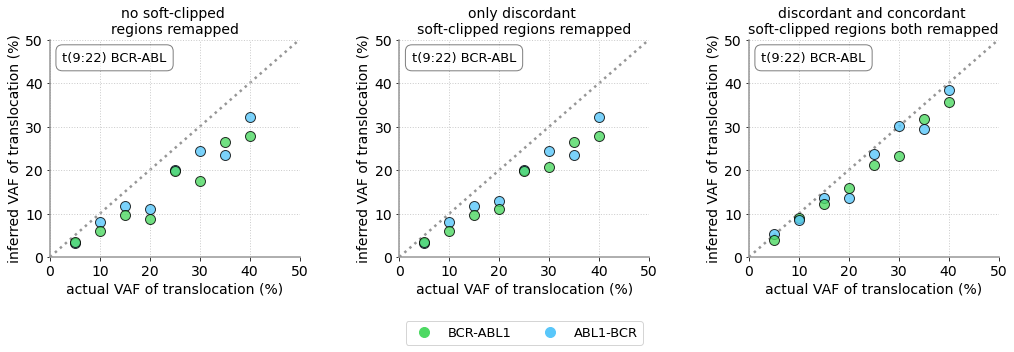

In [ ]:
# plot_concordance_plots_mapping_effects(BCR_ABL_VAFs, 'BCR-ABL', 'ABL-BCR', c5, c6, 'BCR_ABL', 't(9:22) BCR-ABL')
plot_concordance_plots_mapping_effects_non_homologous(BCR_ABL_VAFs, BCR_ABL_dfs, {'BCR-ABL1': c5, 'ABL1-BCR': c6}, 'BCR_ABL', 't(9:22) BCR-ABL')

### Column 2 — t(3;3) DEK::NUP214  (homologous, no inversion)

In [ ]:
#t(3;3)
t_3_3_VAFs = {}
t_3_3_dfs = {}

for VAF_decimal, VAF in zip([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4], [5, 10, 15, 20, 25, 30, 35, 40]):
    print()
    print('VAF = ', VAF)
    if VAF_decimal == 0.25:
        bam_file ='Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_26_09_21/t_3_3_100_cells_'+str(VAF)+'_VAF_26_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_26_09_21'
        sample_name = 't_3_3_100_cells_'+str(VAF)+'_VAF_26_09_21'
    elif VAF_decimal == 0.35:
        bam_file ='Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_19_11_21/t_3_3_100_cells_'+str(VAF)+'_VAF_19_11_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_19_11_21'
        sample_name = 't_3_3_100_cells_'+str(VAF)+'_VAF_19_11_21'
    else:
        bam_file ='Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_30_09_21/t_3_3_100_cells_'+str(VAF)+'_VAF_30_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/t_3_3/t_3_3_100_cells_'+str(VAF)+'_VAF_30_09_21'
        sample_name = 't_3_3_100_cells_'+str(VAF)+'_VAF_30_09_21'
    actual_VAF = VAF_decimal
    print('VAF = ', VAF)
    VAFs, dfs = testing_effects_of_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    t_3_3_VAFs[VAF]=VAFs
    t_3_3_dfs[VAF]=dfs

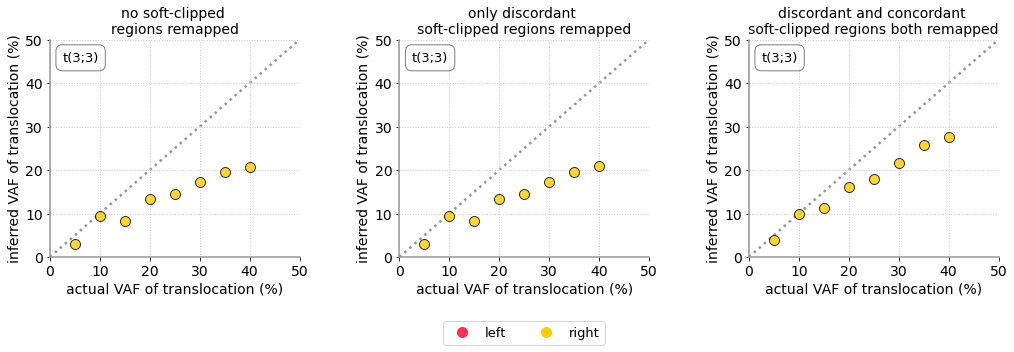

In [ ]:
plot_concordance_plots_mapping_effects(t_3_3_VAFs, 'left', 'right', c1, c4, 't_3_3', 't(3;3)')

### Column 3 — t(9;11) KMT2A::MLLT3  (non-homologous, with inversion)

In [ ]:
#t(9;11): KMT2A-MLLT3
KMT2A_MLLT3_VAFs = {}
KMT2A_MLLT3_dfs = {}

for VAF_decimal, VAF in zip([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4], [5, 10, 15, 20, 25, 30, 35, 40]):
    if VAF_decimal == 0.25:
        bam_file ='Data_files/Simulated_samples/KMT2A_MLLT3/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_26_09_21/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_26_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/KMT2A_MLLT3/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_26_09_21'
        sample_name = 'KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_26_09_21'
    else:
        bam_file ='Data_files/Simulated_samples/KMT2A_MLLT3/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_29_09_21/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_29_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/KMT2A_MLLT3/KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_29_09_21'
        sample_name = 'KMT2A_MLLT3_100_cells_'+str(VAF)+'_VAF_29_09_21'
    actual_VAF = VAF_decimal
    VAFs, dfs = testing_effects_of_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    KMT2A_MLLT3_VAFs[VAF]=VAFs
    KMT2A_MLLT3_dfs[VAF]=dfs

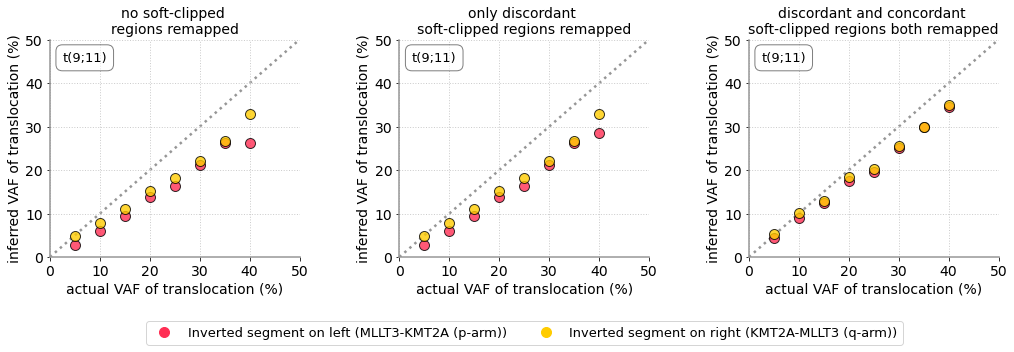

In [ ]:
plot_concordance_plots_mapping_effects(KMT2A_MLLT3_VAFs, 'Inverted segment on left (MLLT3-KMT2A (p-arm))', 'Inverted segment on right (KMT2A-MLLT3 (q-arm))', c1, c4, 'KMT2A_MLLT3', 't(9;11)')

### Column 4 — t(16;16) CBFB::MYH11  (homologous, with inversion)

In [ ]:
#t(16;16)
t16_VAFs = {}
t16_dfs = {}

for VAF_decimal, VAF in zip([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4], [5, 10, 15, 20, 25, 30, 35, 40]):
    if VAF_decimal == 0.25:
        bam_file ='Data_files/Simulated_samples/t16/t16_100_cells_'+str(VAF)+'_VAF_25_09_21/t16_100_cells_'+str(VAF)+'_VAF_25_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/t16/t16_100_cells_'+str(VAF)+'_VAF_25_09_21'
        sample_name = 't16_100_cells_'+str(VAF)+'_VAF_25_09_21'
    else:
        bam_file ='Data_files/Simulated_samples/t16/t16_100_cells_'+str(VAF)+'_VAF_28_09_21/t16_100_cells_'+str(VAF)+'_VAF_28_09_21_UMIs_watson_code_SSCS_mapped_merged.bam'
        out_directory = 'Data_files/Simulated_samples/t16/t16_100_cells_'+str(VAF)+'_VAF_28_09_21'
        sample_name = 't16_100_cells_'+str(VAF)+'_VAF_28_09_21'
    actual_VAF = VAF_decimal
    VAFs, dfs = testing_effects_of_no_remapping(actual_VAF, bam_file, sample_name, read_length, out_directory, reference_genome, minimum_reads, minimum_softclip_length)
    t16_VAFs[VAF]=VAFs
    t16_dfs[VAF]=dfs

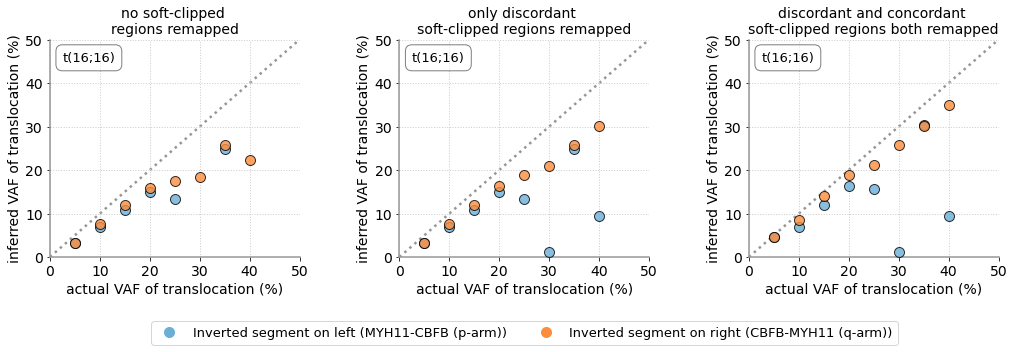

In [ ]:
plot_concordance_plots_mapping_effects(t16_VAFs, 'Inverted segment on left (MYH11-CBFB (p-arm))', 'Inverted segment on right (CBFB-MYH11 (q-arm))', blue3, orange3, 'inv_16', 't(16;16)')